# zeeman slower simulation

# TOOL BOX

## Package

In [1]:
import numpy as np
from scipy.constants import hbar, c, pi, e, m_e
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d
import pandas as pd

## algorithm:

In [3]:
class ZeemanSlower:
    def __init__(self, gamma, k, mass, mu_eff, wavelength):
        """
        Initialize Zeeman Slower parameters
        """
        self.gamma = gamma
        self.k = k
        self.mass = mass
        self.mu_eff = mu_eff
        self.wavelength = wavelength
        self.gamma_hz = gamma / (2 * np.pi)
        self.hbar = hbar
        self.h = hbar*2*np.pi
        self.c = c

    def scattering_force(self, v, z, delta_laser, B_func, s):
        """
        Radiation pressure force
        """
        B = B_func(z)
        delta_total = delta_laser + self.k * v - (self.mu_eff * B / self.hbar)
        scattering_rate = (self.gamma / 2) * (s / (1 + s + (2 * delta_total / self.gamma)**2))
        force = -self.hbar * self.k * scattering_rate

        return force, delta_total, scattering_rate

    def saturation_param(self, z, rho, P_L, wL, s_is_const = True):
        """
        Saturation parameter s(z, rho)
        """
        I_sat = (np.pi * self.h * self.c * self.gamma) / (3 * self.wavelength**3)
        z_R = np.pi * wL**2 / self.wavelength  # rayleigh length
        w_z = wL * np.sqrt(1 + (z / z_R)**2)
        I_0 = 2 * P_L / (np.pi * wL**2)
        I_rho_z = I_0 * (wL / w_z)**2 * np.exp(-2 * rho**2 / w_z**2)
        s = I_rho_z / I_sat
        if s_is_const:
            s = 0.5* I_0 / I_sat # take average to estimate overall slowing profermance
            # print(s)
        return s

    def create_B_field_function(self, slower_length, v_i, v_f, delta_laser):
        """
        B-field function with pre-set parameters
        B_func : callable function that takes z and returns B(z)
        """
        def B_func(z):
            return self.ideal_B_field(z, slower_length, v_i, v_f, delta_laser)
        return B_func

    def ideal_B_field(self, z, slower_length, v_i, v_f, delta_laser):
        """
        ideal B-field profile for constant deceleration
        returns B_z: float or array, magnetic field [T] at z
        """
        # Handle both single vals and arrays
        if isinstance(z, np.ndarray):
            B_z = np.zeros_like(z)
            mask = (z >= 0) & (z <= slower_length)
            B_z[mask] = (self.hbar / self.mu_eff) * (
                delta_laser + self.k * v_i * np.sqrt(1 - (1 - v_f**2 / v_i**2) * z[mask] / slower_length)
            )
            B_z[z > slower_length] = (self.hbar / self.mu_eff) * (delta_laser + self.k * v_f)
        else:
            if z < 0 or z > slower_length:
                return (self.hbar / self.mu_eff) * (delta_laser + self.k * v_f)
            B_z = (self.hbar / self.mu_eff) * (
                delta_laser + self.k * v_i * np.sqrt(1 - (1 - v_f**2 / v_i**2) * z / slower_length)
            )

        return B_z

    def simulate_slower(self, z0, rho0, v0, delta_laser, B_func, P_L, wL, slower_length, s_is_const = True, t_max=0.05, n_points=1000):
        """
        Simulate atom trajectory through Zeeman slower
        """
        from scipy.integrate import solve_ivp

        initial_state = [z0, v0]  # [position, velocity]
        t = np.linspace(0, t_max, n_points)

        self.has_exited = False
        self.stopped_due_to_negative_velocity = False
        self.exit_time = -1
        self.exit_position = -1
        self.exit_velocity = -1

        def motion_equation(t, state):
            z, v = state
            s_val = self.saturation_param(z, rho0, P_L, wL, s_is_const = s_is_const)
            force, delta_total, scattering_rate = self.scattering_force(v, z, delta_laser, B_func, s_val)
            acceleration = force / self.mass
            return [v, acceleration]  # [velocity, acceleration]

        def reach_slower_end(t, state):
            return state[0] - slower_length

        def reach_negative_velocity(t, state):
            return state[1]

        reach_slower_end.terminal = True
        reach_slower_end.direction = 1
        reach_negative_velocity.terminal = True
        reach_negative_velocity.direction = -1

        solution = solve_ivp(
            motion_equation,
            (0, t_max),
            initial_state,
            t_eval=t,
            events=(reach_slower_end, reach_negative_velocity),
            max_step=t_max / max(n_points - 1, 1),
        )

        t_actual = solution.t
        z_actual = solution.y[0]
        v_actual = solution.y[1]
        rho_actual = np.full_like(t_actual, rho0, dtype=float)

        if solution.t_events[0].size > 0:
            t_event = float(solution.t_events[0][0])
            y_event = solution.y_events[0][0]
            if t_actual.size == 0 or t_actual[-1] < t_event:
                t_actual = np.append(t_actual, t_event)
                z_actual = np.append(z_actual, slower_length)
                v_actual = np.append(v_actual, y_event[1])
                rho_actual = np.append(rho_actual, rho0)
            self.has_exited = True
            self.exit_time = t_event
            self.exit_position = slower_length
            self.exit_velocity = float(y_event[1])
        elif solution.t_events[1].size > 0:
            t_event = float(solution.t_events[1][0])
            y_event = solution.y_events[1][0]
            if t_actual.size == 0 or t_actual[-1] < t_event:
                t_actual = np.append(t_actual, t_event)
                z_actual = np.append(z_actual, y_event[0])
                v_actual = np.append(v_actual, 0.0)
                rho_actual = np.append(rho_actual, rho0)
            self.stopped_due_to_negative_velocity = True
            self.exit_time = t_event
            self.exit_position = float(y_event[0])
            self.exit_velocity = 0.0
        else:
            self.exit_time = float(t_actual[-1]) if t_actual.size else -1
            self.exit_position = float(z_actual[-1]) if t_actual.size else -1
            self.exit_velocity = float(v_actual[-1]) if t_actual.size else -1

        # store histories along the returned trajectory only
        force_list = []
        delta_total_list = []
        scattering_rate_list = []
        s_list = []
        B_list = []

        for ti, zi, vi in zip(t_actual, z_actual, v_actual):
            s_val = self.saturation_param(zi, rho0, P_L, wL, s_is_const = s_is_const)
            force, delta_total, scattering_rate = self.scattering_force(vi, zi, delta_laser, B_func, s_val)
            force_list.append(force)
            delta_total_list.append(delta_total)
            scattering_rate_list.append(scattering_rate)
            s_list.append(s_val)
            B_list.append(B_func(zi))

        self.force_history = np.array(force_list)
        self.delta_total_history = np.array(delta_total_list)
        self.scattering_rate_history = np.array(scattering_rate_list)
        self.s_history = np.array(s_list)
        self.B_history = np.array(B_list)

        return t_actual, z_actual, v_actual, rho_actual

    def analyze_saturation_profile(self, z_range, rho_range, P_L, wL):
        """
        saturation parameter profile along the slower
        """
        Z, RHO = np.meshgrid(z_range, rho_range)
        S = np.zeros_like(Z)

        for i in range(len(z_range)):
            for j in range(len(rho_range)):
                S[j, i] = self.saturation_param(z_range[i], rho_range[j], P_L, wL)

        return Z, RHO, S


## single atom:

Testing B-field function:
B at z=0: -1.6 mT
B at end: -55.3 mT

Running simulation...

Simulation results:
Initial velocity: 350.0 m/s
Final velocity: 341.0 m/s
Velocity reduction: 9.0 m/s (2.6%)
Exit status: Exited
Saturation range: 0.557 - 0.557
Maximun scattering rate: 32.5 MHz
Maximum saturation: 0.557
Travel distance: 18.0 cm
Travel time: 0.5 ms


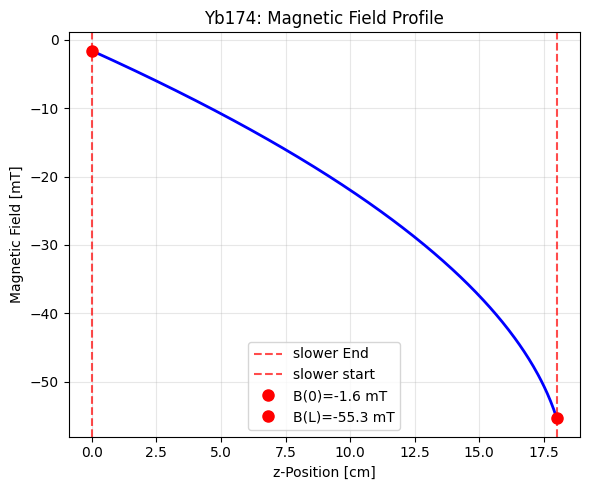

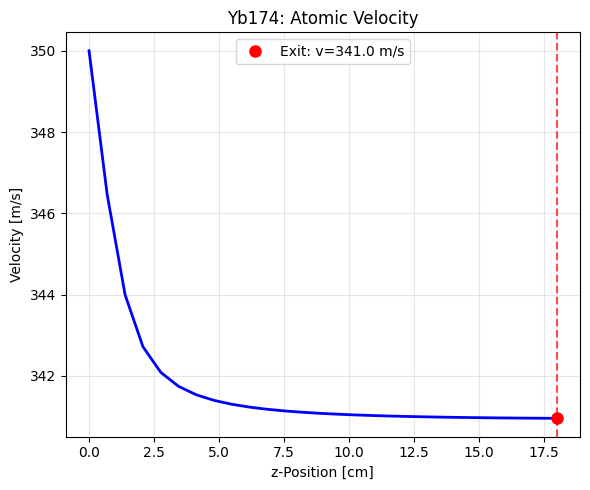

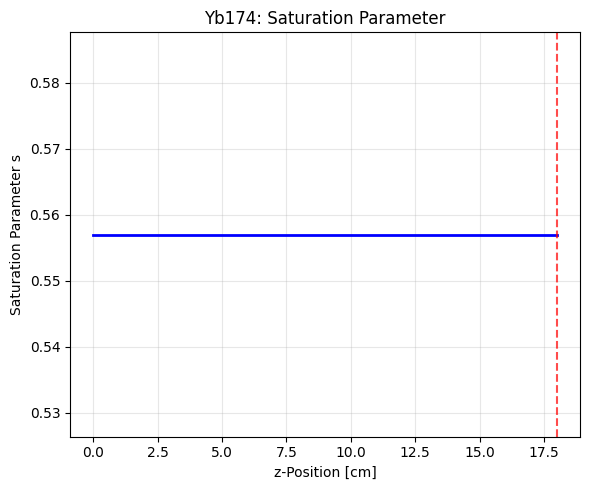

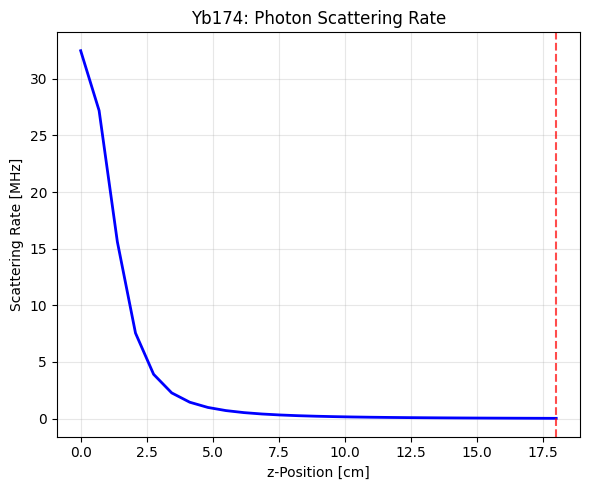

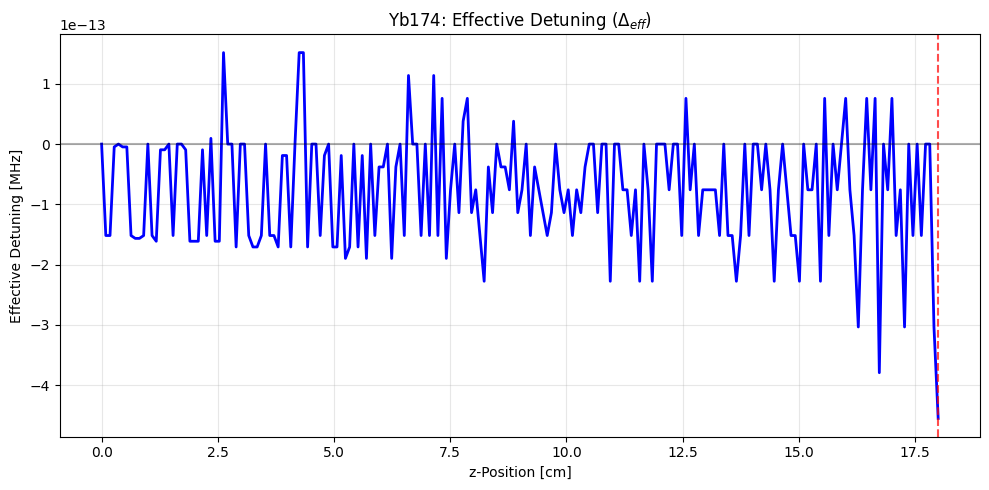

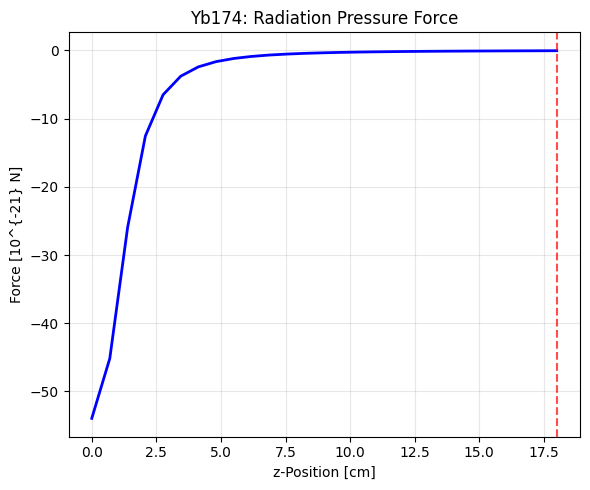

In [4]:
# single atom example

if __name__ == "__main__":

    # Yb174 parameters
    au = 1.66053906660e-27 # kg
    m_174 = 174 * au
    Gamma_399 = 2* np.pi *28.9e6  # [rad/s]
    lmd_399 = 398.9e-9
    k_399 = 2 * np.pi / lmd_399

    g_e, g_g = 1.0, 0.0     # correct for 174Yb (1P1 -> 1S0)
    M_e, M_g = 1, 0         # sigma - cycling transition
    mu_B = e * hbar / (2 * m_e)
    mu_eff_Yb = (g_e * M_e - g_g * M_g) * mu_B  # [J/T]

    # create slower instance
    slower = ZeemanSlower(Gamma_399, k_399, m_174, mu_eff_Yb, lmd_399)

    z0 = 0.0
    rho0 = 0.001    # 1mm radial offset
    v0 = 350.0      # initial velocity m/s
    delta_laser = 2 * np.pi * (-900) * 1e6 # rad/s
    P_L = 44e-3     # laser power [W]
    wL = 6.5e-3     # laser waist [m]
    slower_length = 0.18  # m
    v_final = 50.0  # m/s

    # create B-field function using the new method
    B_func = slower.create_B_field_function(slower_length, v0, v_final, delta_laser)
    
    print("Testing B-field function:")
    print(f"B at z=0: {B_func(0)*1000:.1f} mT")
    print(f"B at end: {B_func(slower_length)*1000:.1f} mT")

    print(f"\nRunning simulation...")
    t, z, v, rho = slower.simulate_slower(z0, rho0, v0, delta_laser, B_func, P_L, wL, slower_length, t_max=0.02)
    print(f"\nSimulation results:")
    print(f"Initial velocity: {v0:.1f} m/s")
    print(f"Final velocity: {v[-1]:.1f} m/s")
    print(f"Velocity reduction: {v0 - v[-1]:.1f} m/s ({((v0 - v[-1])/v0*100):.1f}%)")
    print(f"Exit status: {'Exited' if slower.has_exited else 'Time limit'}")
    print(f"Saturation range: {slower.s_history.min():.3f} - {slower.s_history.max():.3f}")
    print(f"Maximun scattering rate: {slower.scattering_rate_history.max()/1e6:.1f} MHz")
    print(f"Maximum saturation: {slower.s_history.max():.3f}")
    print(f"Travel distance: {z[-1]*100:.1f} cm")
    print(f"Travel time: {t[-1]*1000:.1f} ms")


# Yb174 (single atom) plots

# 1. magnetic field along ZS (changed units)
plt.figure(figsize=(6, 5))
z_plot = np.linspace(0, slower_length, 300)
B_plot = B_func(z_plot)
plt.plot(z_plot * 100, B_plot * 1e3, 'b-', linewidth=2)
plt.axvline(x=slower_length * 100, color='r', linestyle='--', alpha=0.7, label='slower End')
plt.axvline(x=0, color='r', linestyle='--', alpha=0.7, label='slower start')
plt.plot(0, B_func(0)*1000, 'ro', markersize=8, label=f'B(0)={B_func(0)*1000:.1f} mT')
plt.plot(slower_length * 100, B_func(slower_length)*1000, 'ro', markersize=8, label=f'B(L)={B_func(slower_length)*1000:.1f} mT')
plt.xlabel('z-Position [cm]')
plt.ylabel('Magnetic Field [mT]')
plt.title('Yb174: Magnetic Field Profile')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 2. velocity trajectory
plt.figure(figsize=(6, 5))
plt.plot(z * 100, v, 'b-', linewidth=2)
plt.axvline(x=slower_length * 100, color='r', linestyle='--', alpha=0.7)
if slower.has_exited:
  exit_z = slower.exit_position * 100
  exit_v = slower.exit_velocity
  plt.plot(exit_z, exit_v, 'ro', markersize=8, label=f'Exit: v={exit_v:.1f} m/s')
plt.xlabel('z-Position [cm]')
plt.ylabel('Velocity [m/s]')
plt.title('Yb174: Atomic Velocity')
plt.grid(True, alpha=0.3)
if slower.has_exited:
  plt.legend()
plt.tight_layout()
plt.show()

# 3. Saturation parameter along trajectory
plt.figure(figsize=(6, 5))
plt.plot(z*100, slower.s_history, 'blue', linewidth=2)
plt.axvline(x=slower_length * 100, color='r', linestyle='--', alpha=0.7)
plt.xlabel('z-Position [cm]')
plt.ylabel('Saturation Parameter s')
plt.title('Yb174: Saturation Parameter')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Photon scattering rate along trajectory
plt.figure(figsize=(6, 5))
plt.plot(z*100, slower.scattering_rate_history / 1e6, 'blue', linewidth=2)
plt.axvline(x = slower_length * 100, color='r', linestyle='--', alpha=0.7)
plt.xlabel('z-Position [cm]')
plt.ylabel('Scattering Rate [MHz]')
plt.title('Yb174: Photon Scattering Rate')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5. effective detuning
plt.figure(figsize=(10, 5))
z_detailed = np.linspace(0, slower_length, 200)
B_detailed = B_func(z_detailed)
# calculate required B-field for resonance (const deceleration)
v_resonance = np.sqrt(v0**2 + (v_final**2 - v0**2) * z_detailed / slower_length)
delta_effective = delta_laser + slower.k * v_resonance - (slower.mu_eff * B_detailed / slower.hbar)
plt.plot(z_detailed * 100, delta_effective / (2 * np.pi * 1e6), 'b-', linewidth=2)
plt.xlabel('z-Position [cm]')
plt.ylabel('Effective Detuning [MHz]')
plt.title('Yb174: Effective Detuning ($\Delta_{eff}$)')
plt.axvline(x=slower_length * 100, color='r', linestyle='--', alpha=0.7, label='slower End')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 6. Force/acceleration
plt.figure(figsize=(6, 5))
plt.plot(z * 100, slower.force_history * 1e21, 'b-', linewidth=2)  # Scale for better visibility
plt.axvline(x=slower_length * 100, color='r', linestyle='--', alpha=0.7)
plt.xlabel('z-Position [cm]')
plt.ylabel('Force [10^{-21} N]')
plt.title('Yb174: Radiation Pressure Force')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# TEST计算

## 5000 atoms:

3D maxwellian velocity distribution: where $v_p = \sqrt{2k_BT/m}$
$$f(v) = \frac{4}{\sqrt{\pi}} \left(\frac{v^2}{v_p^3} \right) \exp\left( -\frac{v^2}{v_p^2} \right)$$

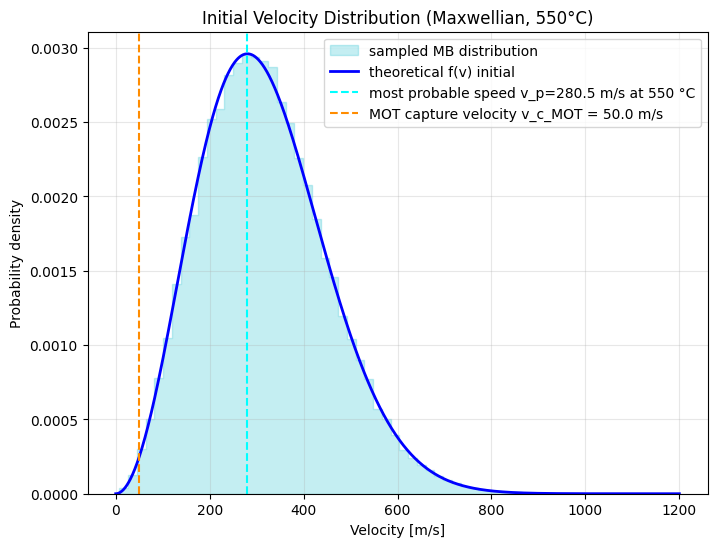

In [58]:
# 覆盖参数 parameters for 5000
n_samples = 50000
celcius = 550
T = 273.15 + celcius
k_B = 1.380649e-23
v_p = np.sqrt(2*k_B*T/m_174)
v_c_MOT = 50

# for initial f(v) distribution
def maxwell_pdf(v, T, m):
    v_p = np.sqrt(2 * k_B * T / m)
    return (4/np.sqrt(np.pi)) * (v**2 / v_p**3) * np.exp(-(v**2)/(v_p**2))

# random sampling for initial velocity
def sample_maxwell(T, m, n_samples):
    sigma = np.sqrt(k_B*T/m)
    vx = np.random.normal(0, sigma, n_samples)
    vy = np.random.normal(0, sigma, n_samples)
    vz = np.random.normal(0, sigma, n_samples)
    return np.sqrt(vx**2 + vy**2 + vz**2)

# generate initial velocities and theoretical PDF
initial_velocities = sample_maxwell(T, m_174, n_samples)
v_range = np.linspace(0, 1200, 1000)
f_v_initial = maxwell_pdf(v_range, T, m_174)

# plot initial velocity distribution and theoretical f(v) PDF
plt.figure(figsize=(8, 6))
plt.hist(initial_velocities, bins=50,density=True,histtype="stepfilled",color="tab:cyan", alpha=0.25,edgecolor="tab:cyan", linewidth=1, label="sampled MB distribution")
plt.plot(v_range, f_v_initial, 'b-', linewidth=2, label="theoretical f(v) initial")
plt.axvline(v_p, color='cyan', linestyle='--', label=f"most probable speed v_p={v_p:.1f} m/s at {celcius} °C")
plt.axvline(v_c_MOT, color='darkorange', linestyle='--', label=f"MOT capture velocity v_c_MOT = {v_c_MOT:.1f} m/s")
plt.xlabel("Velocity [m/s]")
plt.ylabel("Probability density")
plt.title(f"Initial Velocity Distribution (Maxwellian, {celcius}°C)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [59]:
# number density: generate radial positions for Gaussian atomic beam

w_a = 5e-3   # atomic beam waist 5mm / diameter 10mm

def gaussian_atomic_beam(n_samples, w_a, beam_length):
    """
    w_a : float, waist length of atomic beam[m]
    beam_length : float, length of beam in z-direction [m]
    """
    u = np.random.uniform(0, 1, n_samples) # generate radial positions using inverse transform sampling
    rho = w_a * np.sqrt(-0.5 * np.log(1 - u))
    z = np.random.uniform(0, beam_length, n_samples) # generate z uniformly along beam length

    return np.column_stack([z, rho])

print(f"for the Yb atomic beam - ")
print(f"  Most probable speed: v_p = {v_p:.2f} m/s")
print(f"  RMS velocity: v_rms = {np.sqrt(np.mean(initial_velocities**2)):.2f} m/s")
print(f"  Mean velocity: {np.mean(initial_velocities):.2f} m/s")
print(f"  Standard deviation: {np.std(initial_velocities):.2f} m/s")
print(f"  Atom Beam waist: w_a = {w_a*1000:.1f} mm \n")

# random sampling of initial radial positions
positions = gaussian_atomic_beam(n_samples, w_a, slower_length) # [z, rho]
rho_0_array = positions[:, -1] # initial radial position

for the Yb atomic beam - 
  Most probable speed: v_p = 280.48 m/s
  RMS velocity: v_rms = 343.59 m/s
  Mean velocity: 316.69 m/s
  Standard deviation: 133.26 m/s
  Atom Beam waist: w_a = 5.0 mm 



## Exp data

In [69]:
# scan multiple laser powers and store each result set
P_L_list = [0, 1e-3, 2e-3, 3e-3, 4e-3, 5e-3, 6e-3]  # [W], edit this list as needed

# containers for all powers
all_final_velocities = []
all_exit_positions = []
all_exit_times = []
all_successful_slowing = []
results_by_power = []

# create ZS instance
slower = ZeemanSlower(Gamma_399, k_399, m_174, mu_eff_Yb, lmd_399)
t_max = 0.02    # maximum simulation time in seconds
n_points = 1000 # number of time points for ODE integration

# use most probable speed and MOT capture velocity to generate a fixed, ideal B-field
# new_B_func = slower.create_B_field_function(slower_length, v_p, v_c_MOT, delta_laser)
# simulate for when there's no magnetic field
new_B_func = lambda z: np.zeros_like(z)
delta_laser = -600 * 1e6 * 2 * np.pi
wL = 6.5e-3
slower_length = 0.2

I_sat_399 = 60 # mW/cm^2
I_list = 2*np.array(P_L_list)* 1e3 / (pi * (wL * 1e2)**2)  # convert to mW/cm^2
s_list = I_list / I_sat_399
print("Laser power (mW) and corresponding saturation parameter s:")
for P_L, s in zip(P_L_list, s_list):
    print(f"  P_L = {P_L*1e3:.2f} mW -> s = {s:.2f}")

for P_L in P_L_list:
    # initialize storage for this power
    final_velocities = np.zeros(n_samples)
    exit_positions = np.zeros(n_samples)
    exit_times = np.zeros(n_samples)
    successful_slowing = np.zeros(n_samples, dtype=bool)

    for i in range(n_samples):
        # get initial conditions for this atom
        z0 = 0.0
        rho0 = rho_0_array[i]      # initial radial position
        v0 = initial_velocities[i] # initial velocity

        try:
            # run simulation for this atom
            t, z, v, rho = slower.simulate_slower(
                z0=z0, rho0=rho0, v0=v0,
                delta_laser=delta_laser,
                B_func=new_B_func,
                P_L=P_L, wL=wL,
                slower_length=slower_length,
                t_max=t_max, n_points=n_points)

            # store results if simulation successful
            final_velocities[i] = v[-1]  # final velocity
            exit_positions[i] = z[-1]    # final position
            exit_times[i] = t[-1]        # final time
            # boolean array to count successfully slowed instances
            successful_slowing[i] = (v[-1] <= v_c_MOT) and (v[-1] > 0)

        except Exception:
            final_velocities[i] = v0  # keep initial velocity if simulation fails
            exit_positions[i] = 0.0
            exit_times[i] = 0.0
            successful_slowing[i] = False

    # store arrays for this power
    all_final_velocities.append(final_velocities.copy())
    all_exit_positions.append(exit_positions.copy())
    all_exit_times.append(exit_times.copy())
    all_successful_slowing.append(successful_slowing.copy())

    # store summary for this power
    summary = {
        "P_L": P_L,
        "n_success": int(np.sum(successful_slowing)),
        "success_ratio": float(np.mean(successful_slowing)),
        "mean_final_v": float(np.mean(final_velocities)),
        "std_final_v": float(np.std(final_velocities)),
        "min_final_v": float(np.min(final_velocities)),
        "max_final_v": float(np.max(final_velocities)),
    }
    results_by_power.append(summary)

    print(f"=== Simulation Results (P_L = {P_L*1e3:.2f} mW) ===")
    print(f"Total atoms simulated: {n_samples}")
    print(f"Successfully slowed (can be captured by MOT): {summary['n_success']} ({summary['success_ratio']*100:.1f}%)")
    print("Final velocity statistics:")
    print(f"  Mean: {summary['mean_final_v']:.2f} m/s")
    print(f"  Std: {summary['std_final_v']:.2f} m/s")
    print(f"  Min: {summary['min_final_v']:.2f} m/s")
    print(f"  Max: {summary['max_final_v']:.2f} m/s")
    print("")

# keep compatibility with downstream cells: default to the last P_L result
final_velocities = all_final_velocities[-1]
exit_positions = all_exit_positions[-1]
exit_times = all_exit_times[-1]
successful_slowing = all_successful_slowing[-1]

Laser power (mW) and corresponding saturation parameter s:
  P_L = 0.00 mW -> s = 0.00
  P_L = 1.00 mW -> s = 0.03
  P_L = 2.00 mW -> s = 0.05
  P_L = 3.00 mW -> s = 0.08
  P_L = 4.00 mW -> s = 0.10
  P_L = 5.00 mW -> s = 0.13
  P_L = 6.00 mW -> s = 0.15
=== Simulation Results (P_L = 0.00 mW) ===
Total atoms simulated: 50000
Successfully slowed (can be captured by MOT): 206 (0.4%)
Final velocity statistics:
  Mean: 316.69 m/s
  Std: 133.26 m/s
  Min: 7.85 m/s
  Max: 939.14 m/s

=== Simulation Results (P_L = 1.00 mW) ===
Total atoms simulated: 50000
Successfully slowed (can be captured by MOT): 207 (0.4%)
Final velocity statistics:
  Mean: 315.22 m/s
  Std: 134.14 m/s
  Min: 7.58 m/s
  Max: 939.14 m/s

=== Simulation Results (P_L = 2.00 mW) ===
Total atoms simulated: 50000
Successfully slowed (can be captured by MOT): 207 (0.4%)
Final velocity statistics:
  Mean: 314.23 m/s
  Std: 134.75 m/s
  Min: 7.31 m/s
  Max: 939.14 m/s

=== Simulation Results (P_L = 3.00 mW) ===
Total atoms simula

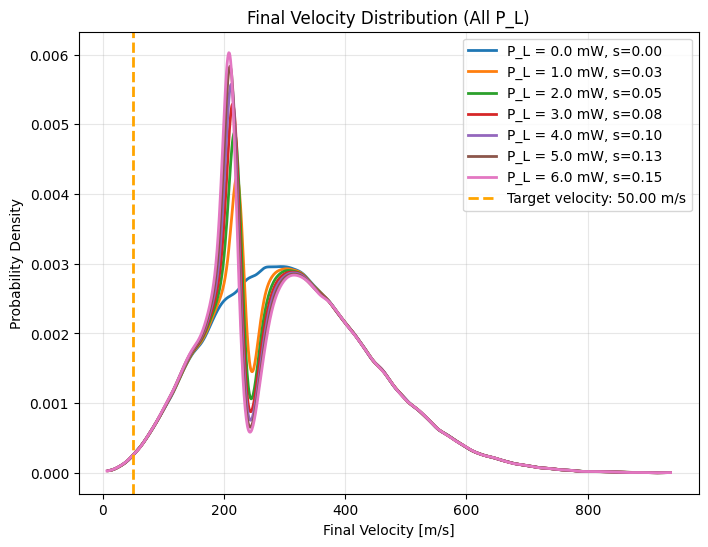

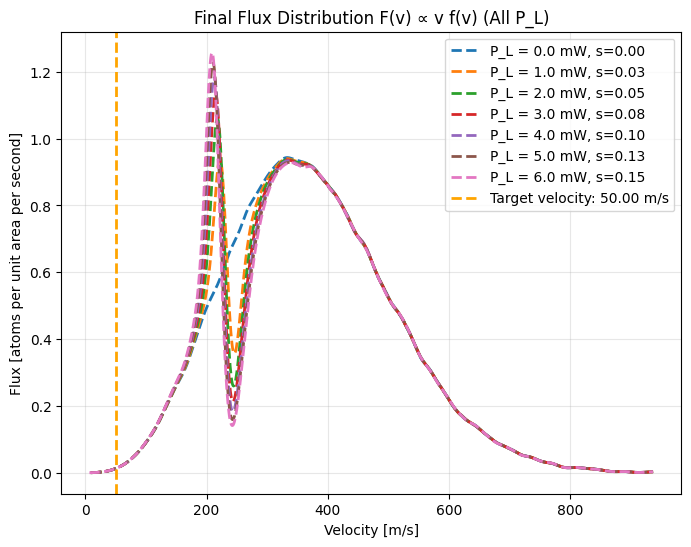

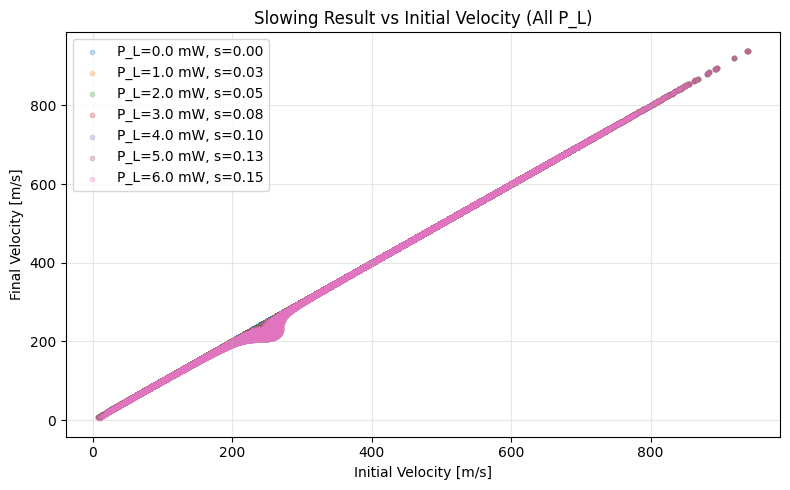

In [70]:
# plot all P_L results together with labels

# build smooth interpolations for each P_L
f_v_final_list = []
v_range_final_list = []
flux_final_list = []

for final_v in all_final_velocities:
    counts, edges = np.histogram(final_v, bins=200, density=True)
    centers = (edges[:-1] + edges[1:]) / 2
    counts_smooth = gaussian_filter1d(counts, sigma=2)
    f_v_final_i = interp1d(centers, counts_smooth, kind='cubic', bounds_error=False, fill_value=0)
    v_range_final_i = np.linspace(centers.min(), centers.max(), 1000)
    flux_final_i = np.where(v_range_final_i > 0, f_v_final_i(v_range_final_i) * v_range_final_i, 0.0)

    f_v_final_list.append(f_v_final_i)
    v_range_final_list.append(v_range_final_i)
    flux_final_list.append(flux_final_i)

# INITIAL velocity distribution (shared reference)
counts, edges = np.histogram(initial_velocities, bins=200, density=True)
centers = (edges[:-1] + edges[1:]) / 2
counts_smooth = gaussian_filter1d(counts, sigma=2)
f_v_initial = interp1d(centers, counts_smooth, kind='cubic', bounds_error=False, fill_value=0)
v_range_initial = np.linspace(centers.min(), centers.max(), 1000)
flux_initial = np.where(v_range_initial > 0, f_v_initial(v_range_initial) * v_range_initial, 0.0)

# keep compatibility with downstream cells
f_v_final = f_v_final_list[-1]
v_range_final = v_range_final_list[-1]

# 1) FINAL velocity distribution for all P_L
plt.figure(figsize=(8, 6))
for i, P_L in enumerate(P_L_list):
    label = f'P_L = {P_L*1e3:.1f} mW, s={s_list[i]:.2f}'
    plt.plot(v_range_final_list[i], f_v_final_list[i](v_range_final_list[i]), linewidth=2, label=label)
plt.axvline(v_c_MOT, color='orange', linestyle='--', linewidth=2, label=f'Target velocity: {v_c_MOT:.2f} m/s')
plt.xlabel('Final Velocity [m/s]')
plt.ylabel('Probability Density')
plt.title('Final Velocity Distribution (All P_L)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2) final flux distribution for all P_L
plt.figure(figsize=(8, 6))
for i, P_L in enumerate(P_L_list):
    label = f'P_L = {P_L*1e3:.1f} mW, s={s_list[i]:.2f}'
    mask = v_range_final_list[i] > 0
    plt.plot(v_range_final_list[i][mask], flux_final_list[i][mask], '--', linewidth=2, label=label)
plt.axvline(v_c_MOT, color='orange', linestyle='--', linewidth=2, label=f'Target velocity: {v_c_MOT:.2f} m/s')
plt.xlabel('Velocity [m/s]')
plt.ylabel('Flux [atoms per unit area per second]')
plt.title('Final Flux Distribution F(v) ∝ v f(v) (All P_L)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# # 3) INITIAL velocity distribution (for comparison)
# plt.figure(figsize=(8, 6))
# plt.hist(initial_velocities, bins=50, density=True, alpha=0.35, color='cyan', label='Initial f(v) sampled')
# plt.plot(v_range_initial, f_v_initial(v_range_initial), 'r-', linewidth=2, label='Initial f(v) smoothed')
# plt.axvline(v_c_MOT, color='orange', linestyle='--', linewidth=2, label=f'Target velocity: {v_c_MOT:.2f} m/s')
# plt.xlabel('Initial Velocity [m/s]')
# plt.ylabel('Probability Density')
# plt.title('Initial Velocity Distribution')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show()

# # 4) initial flux distribution
# plt.figure(figsize=(8, 6))
# mask = v_range_initial > 0
# plt.plot(v_range_initial[mask], flux_initial[mask], 'r--', linewidth=2, label='Initial flux distribution')
# plt.axvline(v_c_MOT, color='orange', linestyle='--', linewidth=2, label=f'Target velocity: {v_c_MOT:.2f} m/s')
# plt.xlabel('Velocity [m/s]')
# plt.ylabel('Flux [atoms per unit area per second]')
# plt.title('Initial Flux Distribution F(v) ∝ v f(v)')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show()

# 5) comparison: initial vs all final f(v)
# v_range_compare = np.linspace(-200, 1000, 1000)
# plt.figure(figsize=(8, 6))
# plt.plot(v_range_compare, f_v_initial(v_range_compare), 'k-', linewidth=2, label='Initial f(v)')
# for i, P_L in enumerate(P_L_list):
#     label = f'Final f(v), P_L={P_L*1e3:.1f} mW, s={s_list[i]:.2f}'
#     plt.plot(v_range_compare, f_v_final_list[i](v_range_compare), linewidth=2, label=label)
# plt.axvline(v_c_MOT, color='orange', linestyle='--', linewidth=2, label=f'Target velocity: {v_c_MOT:.2f} m/s')
# plt.xlabel('Velocity [m/s]')
# plt.ylabel('Probability Density')
# plt.title('Initial vs Final Velocity Distributions (All P_L)')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show()

# # 6) comparison: initial flux vs all final flux
# plt.figure(figsize=(8, 6))
# plt.plot(v_range_initial, flux_initial, 'k--', linewidth=2, label='Initial flux distribution')
# for i, P_L in enumerate(P_L_list):
#     label = f'Final flux, P_L={P_L*1e3:.1f} mW, s={s_list[i]:.2f}'
#     plt.plot(v_range_final_list[i], flux_final_list[i], '--', linewidth=2, label=label)
# plt.axvline(v_c_MOT, color='orange', linestyle='--', linewidth=2, label=f'Target velocity: {v_c_MOT:.2f} m/s')
# plt.xlabel('Velocity [m/s]')
# plt.ylabel('Flux [atoms per unit area per second]')
# plt.title('Initial vs Final Flux Distributions (All P_L)')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show()

# # 7) designed B-field (annotated by all P_L)
# plt.figure(figsize=(6, 5))
# z_plot = np.linspace(0, slower_length, 300)
# B_plot = new_B_func(z_plot)
# for i, P_L in enumerate(P_L_list):
#     plt.plot(z_plot * 100, B_plot * 1e3, linewidth=2, label=f'P_L={P_L*1e3:.1f} mW, s={s_list[i]:.2f}')
# plt.axvline(x=slower_length * 100, color='b', linestyle='--', alpha=0.7, label='Slower end')
# plt.axvline(x=0, color='r', linestyle='--', alpha=0.7, label='Slower start')
# plt.xlabel('z-Position [cm]')
# plt.ylabel('Magnetic Field [mT]')
# plt.title(f'Designed Magnetic Field Profile ({n_samples} atoms)')
# plt.grid(True, alpha=0.3)
# plt.legend()
# plt.tight_layout()
# plt.show()

# 8) success vs initial velocity for all P_L
plt.figure(figsize=(8, 5))
for i, P_L in enumerate(P_L_list):
    label = f'P_L={P_L*1e3:.1f} mW, s={s_list[i]:.2f}'
    plt.scatter(initial_velocities, all_final_velocities[i], alpha=0.25, s=10, label=label)
plt.xlabel('Initial Velocity [m/s]')
plt.ylabel('Final Velocity [m/s]')
plt.title('Slowing Result vs Initial Velocity (All P_L)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## fluorescence:
$$F(\Delta) = \int f(v) R_{sc}(\Delta + kv) dv$$
$$R_{sc}​(\Delta) = \frac{\Gamma}{2} \frac{s}{1+s+(2\Delta/\Gamma)^2}$$

In [92]:
Gamma_556 = 2 * np.pi * 182e3  # [rad/s]
k_556 = 2 * np.pi / 556e-9
I_sat_556 = 0.14 # mW/m^2
P_556 = 100 # mW
w_556 = 0.05 # cm
I_556 = 2 * P_556 / (pi * (w_556)**2) # mW/cm^2
s_556 = I_556 / I_sat_556
print(f"556nm transition saturation parameter: s = {s_556:.2f}")

556nm transition saturation parameter: s = 181891.36


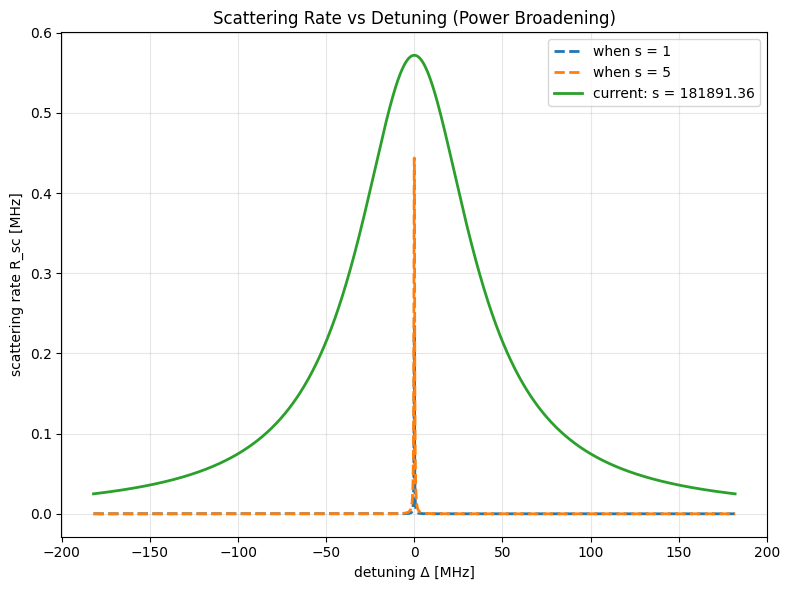

In [93]:
delta_range = np.linspace(-1000 * Gamma_556, 1000 * Gamma_556, 3000)

def R_sc(delta, s):
    return (Gamma_556/2) * (s / (1 + s + (2*delta/Gamma_556)**2))

R_sc1 = R_sc(delta_range, 1)
R_sc5 = R_sc(delta_range, 5)
R_sc10 = R_sc(delta_range, s_556)

plt.figure(figsize=(8,6))
plt.plot(delta_range/(2*np.pi*1e6), R_sc1/1e6, linestyle='--', linewidth=2, label='when s = 1')
plt.plot(delta_range/(2*np.pi*1e6), R_sc5/1e6, linestyle='--', linewidth=2, label='when s = 5')
plt.plot(delta_range/(2*np.pi*1e6), R_sc10/1e6, linewidth=2, label=f'current: s = {s_556:.2f}')
plt.xlabel("detuning Δ [MHz]")
plt.ylabel("scattering rate R_sc [MHz]")
plt.title("Scattering Rate vs Detuning (Power Broadening)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



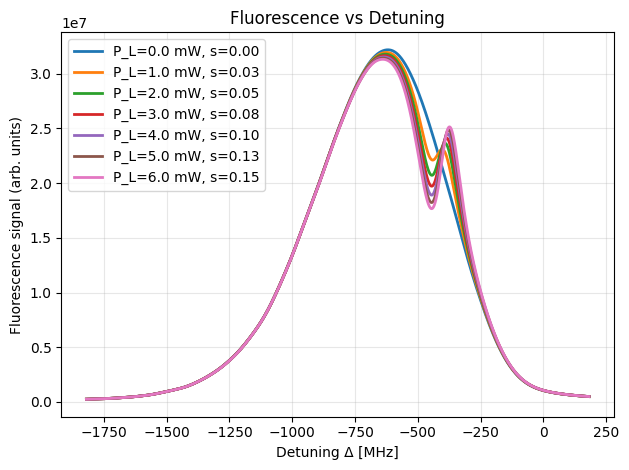

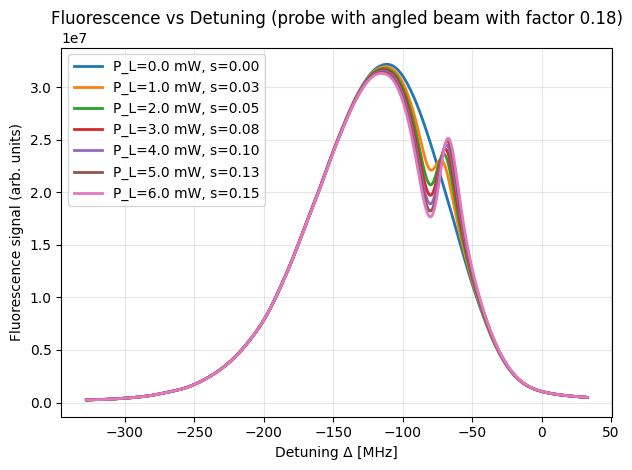

In [94]:
# fluorescence signal calculation (convolution of f(v) with R_sc)
delta_range = np.linspace(-10000 * Gamma_556, 1000 * Gamma_556, 3000)

F_Final_list = []
for i, flux_final in enumerate(flux_final_list):
    # Use the matching velocity grid for each flux_final array
    v_grid_i = v_range_final_list[i]
    dv_i = v_grid_i[1] - v_grid_i[0]
    F_final = []
    for delta in delta_range:
        delta_eff = delta + k_556 * v_grid_i
        R_vals = R_sc(delta_eff, s_556)
        F_f = np.sum(flux_final * R_vals) * dv_i
        F_final.append(F_f)
    F_Final_list.append(np.array(F_final))

for i, F_final in enumerate(F_Final_list):
    label = f'P_L={P_L_list[i]*1e3:.1f} mW, s={s_list[i]:.2f}'
    plt.plot(delta_range/(2*np.pi*1e6), F_final, linewidth=2, label=label)
plt.xlabel('Detuning Δ [MHz]')
plt.ylabel('Fluorescence signal (arb. units)')
plt.title('Fluorescence vs Detuning')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for i, F_final in enumerate(F_Final_list):
    label = f'P_L={P_L_list[i]*1e3:.1f} mW, s={s_list[i]:.2f}'
    plt.plot(0.18*delta_range/(2*np.pi*1e6), F_final, linewidth=2, label=label)
plt.xlabel('Detuning Δ [MHz]')
plt.ylabel('Fluorescence signal (arb. units)')
plt.title('Fluorescence vs Detuning (probe with angled beam with factor 0.18)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


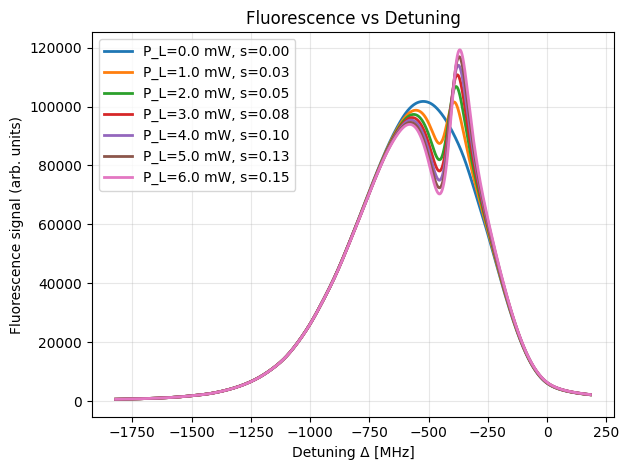

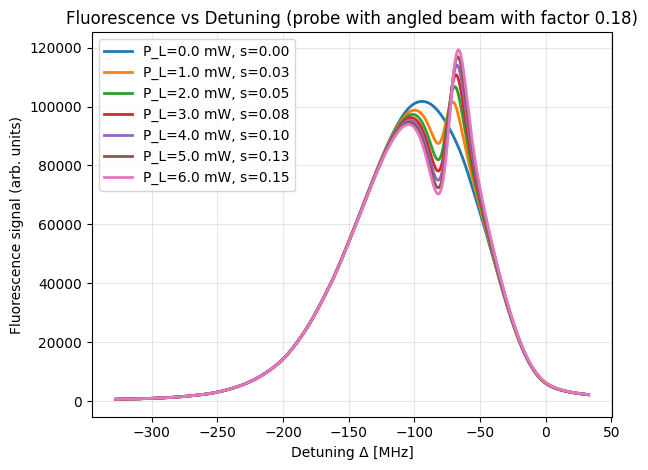

In [95]:
# fluorescence signal calculation (convolution of f(v) with R_sc)
delta_range = np.linspace(-10000 * Gamma_556, 1000 * Gamma_556, 3000)

F_Final_list = []
for i, f_v_final in enumerate(f_v_final_list):
    # Use the matching velocity grid for each interpolator
    v_grid_i = v_range_final_list[i]
    f_vals_i = f_v_final(v_grid_i)
    F_final = []
    for delta in delta_range:
        delta_eff = delta + k_556 * v_grid_i
        R_vals = R_sc(delta_eff, s_556)
        F_f = np.trapz(f_vals_i * R_vals, v_grid_i)
        F_final.append(F_f)
    F_Final_list.append(np.array(F_final))

for i, F_final in enumerate(F_Final_list):
    label = f'P_L={P_L_list[i]*1e3:.1f} mW, s={s_list[i]:.2f}'
    plt.plot(delta_range/(2*np.pi*1e6), F_final, linewidth=2, label=label)
plt.xlabel('Detuning Δ [MHz]')
plt.ylabel('Fluorescence signal (arb. units)')
plt.title('Fluorescence vs Detuning')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for i, F_final in enumerate(F_Final_list):
    label = f'P_L={P_L_list[i]*1e3:.1f} mW, s={s_list[i]:.2f}'
    plt.plot(0.18*delta_range/(2*np.pi*1e6), F_final, linewidth=2, label=label)
plt.xlabel('Detuning Δ [MHz]')
plt.ylabel('Fluorescence signal (arb. units)')
plt.title('Fluorescence vs Detuning (probe with angled beam with factor 0.18)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 解相儒的计算
follow "part 3. calculate the B feild" helps you understand basic idea of zeeman slower

## 5000 atoms:

3D maxwellian velocity distribution: where $v_p = \sqrt{2k_BT/m}$
$$f(v) = \frac{4}{\sqrt{\pi}} \left(\frac{v^2}{v_p^3} \right) \exp\left( -\frac{v^2}{v_p^2} \right)$$

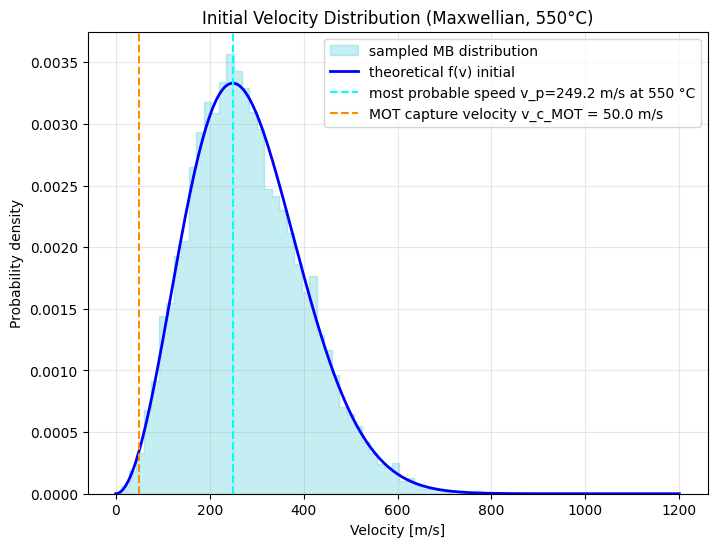

In [3]:
# 覆盖参数 parameters for 10000
n_samples = 10000
celcius = 550
# T = 273.15 + celcius
T = 650
k_B = 1.380649e-23
m_174 = 174 * 1.66053906660e-27 # kg
v_p = np.sqrt(2*k_B*T/m_174)
v_c_MOT = 50

# for initial f(v) distribution
def maxwell_pdf(v, T, m):
    v_p = np.sqrt(2 * k_B * T / m)
    return (4/np.sqrt(np.pi)) * (v**2 / v_p**3) * np.exp(-(v**2)/(v_p**2))

# random sampling for initial velocity
def sample_maxwell(T, m, n_samples):
    sigma = np.sqrt(k_B*T/m)
    vx = np.random.normal(0, sigma, n_samples)
    vy = np.random.normal(0, sigma, n_samples)
    vz = np.random.normal(0, sigma, n_samples)
    return np.sqrt(vx**2 + vy**2 + vz**2)

# generate initial velocities and theoretical PDF
initial_velocities = sample_maxwell(T, m_174, n_samples)
v_range = np.linspace(0, 1200, 1000)
f_v_initial = maxwell_pdf(v_range, T, m_174)

# plot initial velocity distribution and theoretical f(v) PDF
plt.figure(figsize=(8, 6))
plt.hist(initial_velocities, bins=50,density=True,histtype="stepfilled",color="tab:cyan", alpha=0.25,edgecolor="tab:cyan", linewidth=1, label="sampled MB distribution")
plt.plot(v_range, f_v_initial, 'b-', linewidth=2, label="theoretical f(v) initial")
plt.axvline(v_p, color='cyan', linestyle='--', label=f"most probable speed v_p={v_p:.1f} m/s at {celcius} °C")
plt.axvline(v_c_MOT, color='darkorange', linestyle='--', label=f"MOT capture velocity v_c_MOT = {v_c_MOT:.1f} m/s")
plt.xlabel("Velocity [m/s]")
plt.ylabel("Probability density")
plt.title(f"Initial Velocity Distribution (Maxwellian, {celcius}°C)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [4]:
# number density: generate radial positions for Gaussian atomic beam

w_a = 5e-3   # atomic beam waist 5mm / diameter 10mm

def gaussian_atomic_beam(n_samples, w_a, beam_length):
    """
    w_a : float, waist length of atomic beam[m]
    beam_length : float, length of beam in z-direction [m]
    """
    u = np.random.uniform(0, 1, n_samples) # generate radial positions using inverse transform sampling
    rho = w_a * np.sqrt(-0.5 * np.log(1 - u))
    z = np.random.uniform(0, beam_length, n_samples) # generate z uniformly along beam length

    return np.column_stack([z, rho])

print(f"for the Yb atomic beam - ")
print(f"  Most probable speed: v_p = {v_p:.2f} m/s")
print(f"  RMS velocity: v_rms = {np.sqrt(np.mean(initial_velocities**2)):.2f} m/s")
print(f"  Mean velocity: {np.mean(initial_velocities):.2f} m/s")
print(f"  Standard deviation: {np.std(initial_velocities):.2f} m/s")
print(f"  Atom Beam waist: w_a = {w_a*1000:.1f} mm \n")

# random sampling of initial radial positions
positions = gaussian_atomic_beam(n_samples, w_a, slower_length) # [z, rho]
rho_0_array = positions[:, -1] # initial radial position

for the Yb atomic beam - 
  Most probable speed: v_p = 249.24 m/s
  RMS velocity: v_rms = 304.19 m/s
  Mean velocity: 279.84 m/s
  Standard deviation: 119.23 m/s
  Atom Beam waist: w_a = 5.0 mm 



NameError: name 'slower_length' is not defined

## 1. no mag, slow the atoms with -200MHz

In [11]:
# scan multiple laser powers and store each result set
P_L_list = [0,  6e-3]  # [W], edit this list as needed
new_B_func = lambda z: np.zeros_like(z)
delta_laser = -200 * 1e6 * 2 * np.pi
wL = 6.5e-3
slower_length = 0.2


# containers for all powers
all_final_velocities = []
all_exit_positions = []
all_exit_times = []
all_successful_slowing = []
results_by_power = []

# create ZS instance
slower = ZeemanSlower(Gamma_399, k_399, m_174, mu_eff_Yb, lmd_399)
t_max = 0.02    # maximum simulation time in seconds
n_points = 1000 # number of time points for ODE integration

# use most probable speed and MOT capture velocity to generate a fixed, ideal B-field
# new_B_func = slower.create_B_field_function(slower_length, v_p, v_c_MOT, delta_laser)
# simulate for when there's no magnetic field


I_sat_399 = 60 # mW/cm^2
I_list = 2*np.array(P_L_list)* 1e3 / (pi * (wL * 1e2)**2)  # convert to mW/cm^2
s_list = I_list / I_sat_399
print("Laser power (mW) and corresponding saturation parameter s:")
for P_L, s in zip(P_L_list, s_list):
    print(f"  P_L = {P_L*1e3:.2f} mW -> s = {s:.2f}")

for P_L in P_L_list:
    # initialize storage for this power
    final_velocities = np.zeros(n_samples)
    exit_positions = np.zeros(n_samples)
    exit_times = np.zeros(n_samples)
    successful_slowing = np.zeros(n_samples, dtype=bool)

    for i in range(n_samples):
        # get initial conditions for this atom
        z0 = 0.0
        rho0 = rho_0_array[i]      # initial radial position
        v0 = initial_velocities[i] # initial velocity

        try:
            # run simulation for this atom
            t, z, v, rho = slower.simulate_slower(
                z0=z0, rho0=rho0, v0=v0,
                delta_laser=delta_laser,
                B_func=new_B_func,
                P_L=P_L, wL=wL,
                slower_length=slower_length,
                t_max=t_max, n_points=n_points)

            # store results if simulation successful
            final_velocities[i] = v[-1]  # final velocity
            exit_positions[i] = z[-1]    # final position
            exit_times[i] = t[-1]        # final time
            # boolean array to count successfully slowed instances
            successful_slowing[i] = (v[-1] <= v_c_MOT) and (v[-1] > 0)

        except Exception:
            final_velocities[i] = v0  # keep initial velocity if simulation fails
            exit_positions[i] = 0.0
            exit_times[i] = 0.0
            successful_slowing[i] = False

    # store arrays for this power
    all_final_velocities.append(final_velocities.copy())
    all_exit_positions.append(exit_positions.copy())
    all_exit_times.append(exit_times.copy())
    all_successful_slowing.append(successful_slowing.copy())

    # store summary for this power
    summary = {
        "P_L": P_L,
        "n_success": int(np.sum(successful_slowing)),
        "success_ratio": float(np.mean(successful_slowing)),
        "mean_final_v": float(np.mean(final_velocities)),
        "std_final_v": float(np.std(final_velocities)),
        "min_final_v": float(np.min(final_velocities)),
        "max_final_v": float(np.max(final_velocities)),
    }
    results_by_power.append(summary)

    print(f"=== Simulation Results (P_L = {P_L*1e3:.2f} mW) ===")
    print(f"Total atoms simulated: {n_samples}")
    print(f"Successfully slowed (can be captured by MOT): {summary['n_success']} ({summary['success_ratio']*100:.1f}%)")
    print("Final velocity statistics:")
    print(f"  Mean: {summary['mean_final_v']:.2f} m/s")
    print(f"  Std: {summary['std_final_v']:.2f} m/s")
    print(f"  Min: {summary['min_final_v']:.2f} m/s")
    print(f"  Max: {summary['max_final_v']:.2f} m/s")
    print("")

# keep compatibility with downstream cells: default to the last P_L result
final_velocities = all_final_velocities[-1]
exit_positions = all_exit_positions[-1]
exit_times = all_exit_times[-1]
successful_slowing = all_successful_slowing[-1]

Laser power (mW) and corresponding saturation parameter s:
  P_L = 0.00 mW -> s = 0.00
  P_L = 6.00 mW -> s = 0.15
=== Simulation Results (P_L = 0.00 mW) ===
Total atoms simulated: 10000
Successfully slowed (can be captured by MOT): 33 (0.3%)
Final velocity statistics:
  Mean: 315.88 m/s
  Std: 133.55 m/s
  Min: 18.61 m/s
  Max: 943.89 m/s

=== Simulation Results (P_L = 6.00 mW) ===
Total atoms simulated: 10000
Successfully slowed (can be captured by MOT): 390 (3.9%)
Final velocity statistics:
  Mean: 312.52 m/s
  Std: 139.39 m/s
  Min: -23.92 m/s
  Max: 943.89 m/s



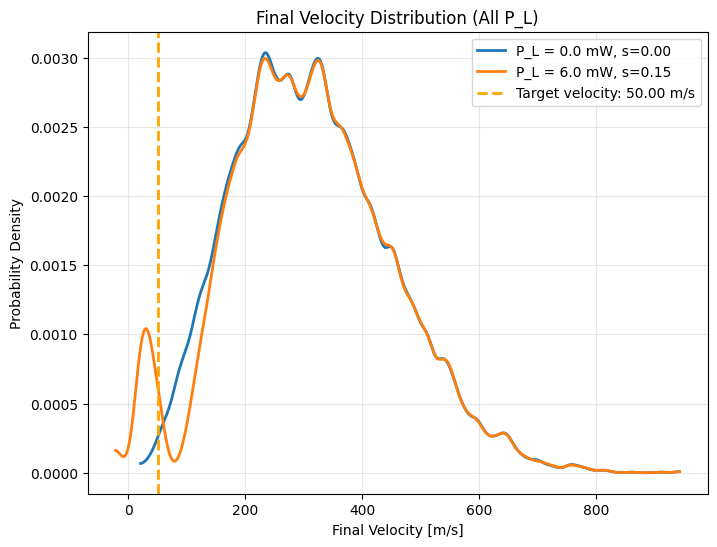

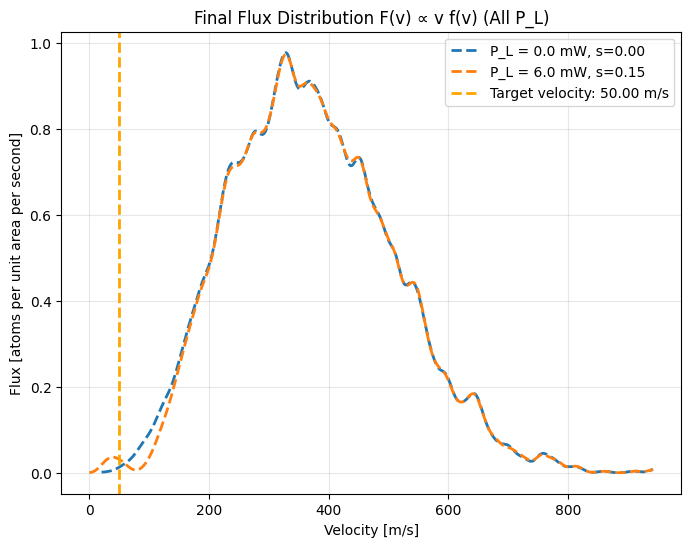

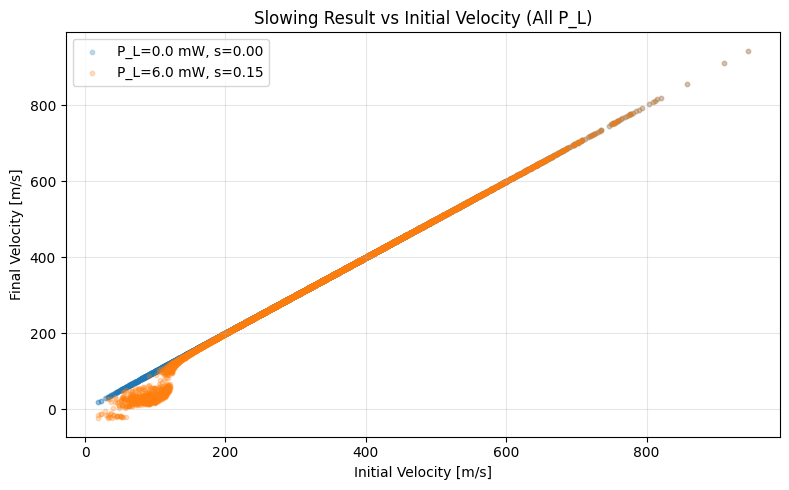

In [16]:
# plot all P_L results together with labels

# build smooth interpolations for each P_L
f_v_final_list = []
v_range_final_list = []
flux_final_list = []

for final_v in all_final_velocities:
    counts, edges = np.histogram(final_v, bins=200, density=True)
    centers = (edges[:-1] + edges[1:]) / 2
    counts_smooth = gaussian_filter1d(counts, sigma=2)
    f_v_final_i = interp1d(centers, counts_smooth, kind='cubic', bounds_error=False, fill_value=0)
    v_range_final_i = np.linspace(centers.min(), centers.max(), 1000)
    flux_final_i = np.where(v_range_final_i > 0, f_v_final_i(v_range_final_i) * v_range_final_i, 0.0)

    f_v_final_list.append(f_v_final_i)
    v_range_final_list.append(v_range_final_i)
    flux_final_list.append(flux_final_i)

# INITIAL velocity distribution (shared reference)
counts, edges = np.histogram(initial_velocities, bins=200, density=True)
centers = (edges[:-1] + edges[1:]) / 2
counts_smooth = gaussian_filter1d(counts, sigma=2)
f_v_initial = interp1d(centers, counts_smooth, kind='cubic', bounds_error=False, fill_value=0)
v_range_initial = np.linspace(centers.min(), centers.max(), 1000)
flux_initial = np.where(v_range_initial > 0, f_v_initial(v_range_initial) * v_range_initial, 0.0)

# keep compatibility with downstream cells
f_v_final = f_v_final_list[-1]
v_range_final = v_range_final_list[-1]

plt.figure(figsize=(8, 6))
for i, P_L in enumerate(P_L_list):
    label = f'P_L = {P_L*1e3:.1f} mW, s={s_list[i]:.2f}'
    plt.plot(v_range_final_list[i], f_v_final_list[i](v_range_final_list[i]), linewidth=2, label=label)
plt.axvline(v_c_MOT, color='orange', linestyle='--', linewidth=2, label=f'Target velocity: {v_c_MOT:.2f} m/s')
plt.xlabel('Final Velocity [m/s]')
plt.ylabel('Probability Density')
plt.title('Final Velocity Distribution (All P_L)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


plt.figure(figsize=(8, 6))
for i, P_L in enumerate(P_L_list):
    label = f'P_L = {P_L*1e3:.1f} mW, s={s_list[i]:.2f}'
    mask = v_range_final_list[i] > 0
    plt.plot(v_range_final_list[i][mask], flux_final_list[i][mask], '--', linewidth=2, label=label)
plt.axvline(v_c_MOT, color='orange', linestyle='--', linewidth=2, label=f'Target velocity: {v_c_MOT:.2f} m/s')
plt.xlabel('Velocity [m/s]')
plt.ylabel('Flux [atoms per unit area per second]')
plt.title('Final Flux Distribution F(v) ∝ v f(v) (All P_L)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
for i, P_L in enumerate(P_L_list):
    label = f'P_L={P_L*1e3:.1f} mW, s={s_list[i]:.2f}'
    plt.scatter(initial_velocities, all_final_velocities[i], alpha=0.25, s=10, label=label)
plt.xlabel('Initial Velocity [m/s]')
plt.ylabel('Final Velocity [m/s]')
plt.title('Slowing Result vs Initial Velocity (All P_L)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### fluorescence:
$$F(\Delta) = \int f(v) R_{sc}(\Delta + kv) dv$$
$$R_{sc}​(\Delta) = \frac{\Gamma}{2} \frac{s}{1+s+(2\Delta/\Gamma)^2}$$

#### 556 probe

In [17]:
Gamma_556 = 2 * np.pi * 182e3  # [rad/s]
k_556 = 2 * np.pi / 556e-9
I_sat_556 = 0.14 # mW/m^2
P_556 = 10 # mW
w_556 = 0.3 # cm
I_556 = 2 * P_556 / (pi * (w_556)**2) # mW/cm^2
s_556 = I_556 / I_sat_556
print(f"556nm transition saturation parameter: s = {s_556:.2f}")

556nm transition saturation parameter: s = 505.25


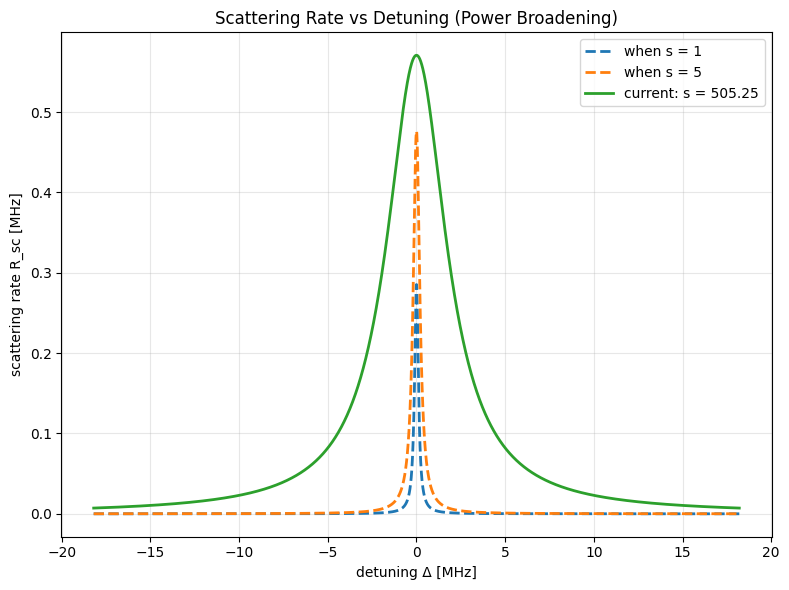

In [ ]:
delta_range = np.linspace(-100 * Gamma_556, 100 * Gamma_556, 3000)

def R_sc(delta, s):
    return (Gamma_556/2) * (s / (1 + s + (2*delta/Gamma_556)**2))

R_sc1 = R_sc(delta_range, 1)
R_sc5 = R_sc(delta_range, 5)
R_sc10 = R_sc(delta_range, s_556)

plt.figure(figsize=(8,6))
plt.plot(delta_range/(2*np.pi*1e6), R_sc1/1e6, linestyle='--', linewidth=2, label='when s = 1')
plt.plot(delta_range/(2*np.pi*1e6), R_sc5/1e6, linestyle='--', linewidth=2, label='when s = 5')
plt.plot(delta_range/(2*np.pi*1e6), R_sc10/1e6, linewidth=2, label=f'current: s = {s_556:.2f}')
plt.xlabel("detuning Δ [MHz]")
plt.ylabel("scattering rate R_sc [MHz]")
plt.title("Scattering Rate vs Detuning (Power Broadening)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



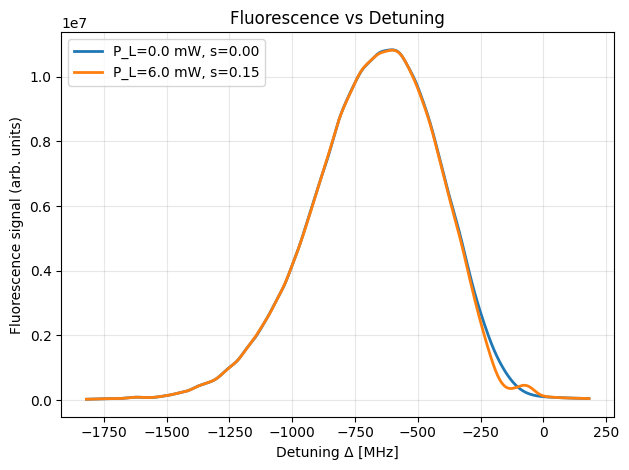

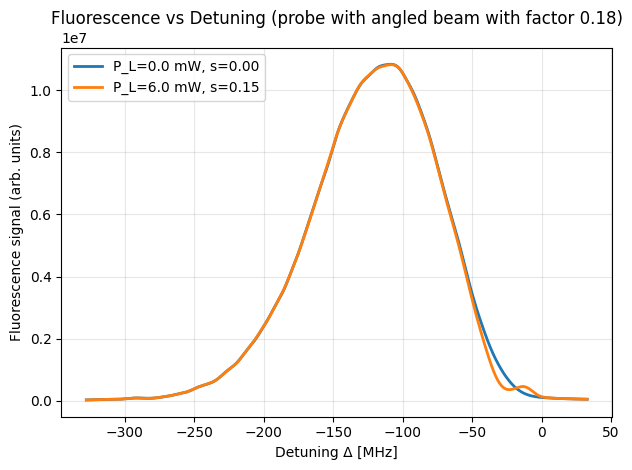

In [ ]:
# fluorescence signal calculation (convolution of f(v) with R_sc)
delta_range = np.linspace(-10000 * Gamma_556, 1000 * Gamma_556, 3000)

F_Final_list = []
for i, flux_final in enumerate(flux_final_list):
    # Use the matching velocity grid for each flux_final array
    v_grid_i = v_range_final_list[i]
    dv_i = v_grid_i[1] - v_grid_i[0]
    F_final = []
    for delta in delta_range:
        delta_eff = delta + k_556 * v_grid_i
        R_vals = R_sc(delta_eff, s_556)
        F_f = np.sum(flux_final * R_vals) * dv_i
        F_final.append(F_f)
    F_Final_list.append(np.array(F_final))

for i, F_final in enumerate(F_Final_list):
    label = f'P_L={P_L_list[i]*1e3:.1f} mW, s={s_list[i]:.2f}'
    plt.plot(delta_range/(2*np.pi*1e6), F_final, linewidth=2, label=label)
plt.xlabel('Detuning Δ [MHz]')
plt.ylabel('Fluorescence signal (arb. units)')
plt.title('Fluorescence vs Detuning')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for i, F_final in enumerate(F_Final_list):
    label = f'P_L={P_L_list[i]*1e3:.1f} mW, s={s_list[i]:.2f}'
    plt.plot(0.18*delta_range/(2*np.pi*1e6), F_final, linewidth=2, label=label)
plt.xlabel('Detuning Δ [MHz]')
plt.ylabel('Fluorescence signal (arb. units)')
plt.title('Fluorescence vs Detuning (probe with angled beam with factor 0.18)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


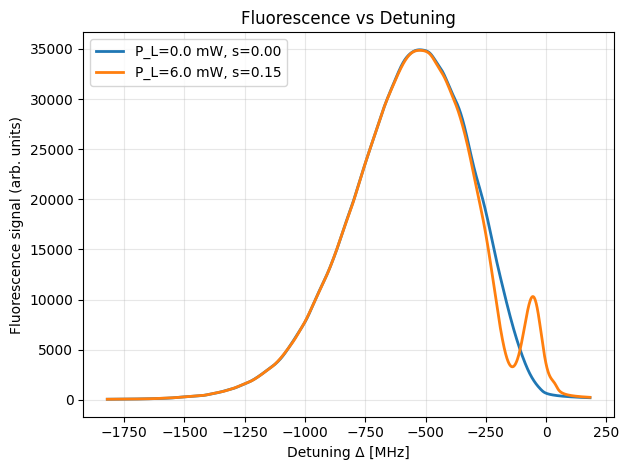

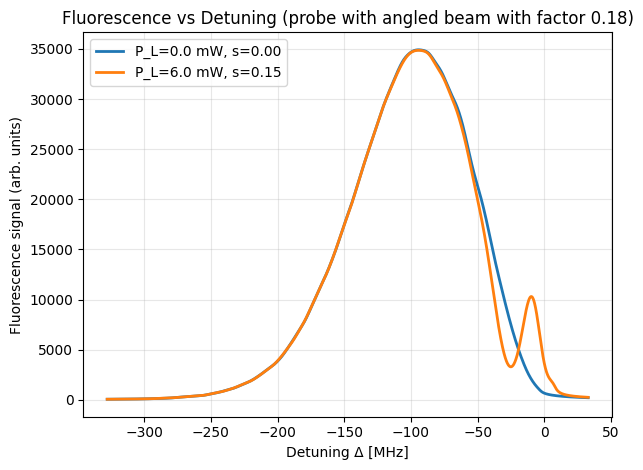

In [ ]:
# fluorescence signal calculation (convolution of f(v) with R_sc)
delta_range = np.linspace(-10000 * Gamma_556, 1000 * Gamma_556, 3000)

F_Final_list = []
for i, f_v_final in enumerate(f_v_final_list):
    # Use the matching velocity grid for each interpolator
    v_grid_i = v_range_final_list[i]
    f_vals_i = f_v_final(v_grid_i)
    F_final = []
    for delta in delta_range:
        delta_eff = delta + k_556 * v_grid_i
        R_vals = R_sc(delta_eff, s_556)
        F_f = np.trapz(f_vals_i * R_vals, v_grid_i)
        F_final.append(F_f)
    F_Final_list.append(np.array(F_final))

for i, F_final in enumerate(F_Final_list):
    label = f'P_L={P_L_list[i]*1e3:.1f} mW, s={s_list[i]:.2f}'
    plt.plot(delta_range/(2*np.pi*1e6), F_final, linewidth=2, label=label)
plt.xlabel('Detuning Δ [MHz]')
plt.ylabel('Fluorescence signal (arb. units)')
plt.title('Fluorescence vs Detuning')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for i, F_final in enumerate(F_Final_list):
    label = f'P_L={P_L_list[i]*1e3:.1f} mW, s={s_list[i]:.2f}'
    plt.plot(0.18*delta_range/(2*np.pi*1e6), F_final, linewidth=2, label=label)
plt.xlabel('Detuning Δ [MHz]')
plt.ylabel('Fluorescence signal (arb. units)')
plt.title('Fluorescence vs Detuning (probe with angled beam with factor 0.18)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
Gamma_399 = 2 * np.pi * 29e6  # [rad/s]
k_399 = 2 * np.pi / 399e-9
I_sat_399 = 60 # mW/m^2
P_399 = 0.1 # mW
w_399 = 0.05 # cm
I_399 = 2 * P_399 / (pi * (w_399)**2) # mW/cm^2
s_399 = I_399 / I_sat_399
print(f"399nm transition saturation parameter: s = {s_399:.2f}")

399nm transition saturation parameter: s = 0.42


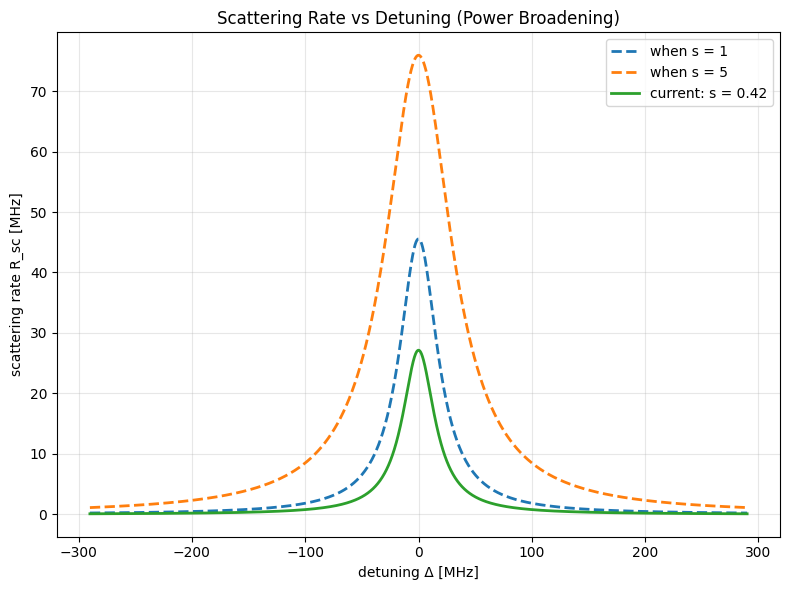

In [ ]:
delta_range = np.linspace(-10 * Gamma_399, 10 * Gamma_399, 3000)

def R_sc(delta, s):
    return (Gamma_399/2) * (s / (1 + s + (2*delta/Gamma_399)**2))

R_sc1 = R_sc(delta_range, 1)
R_sc5 = R_sc(delta_range, 5)
R_sc10 = R_sc(delta_range, s_399)

plt.figure(figsize=(8,6))
plt.plot(delta_range/(2*np.pi*1e6), R_sc1/1e6, linestyle='--', linewidth=2, label='when s = 1')
plt.plot(delta_range/(2*np.pi*1e6), R_sc5/1e6, linestyle='--', linewidth=2, label='when s = 5')
plt.plot(delta_range/(2*np.pi*1e6), R_sc10/1e6, linewidth=2, label=f'current: s = {s_399:.2f}')
plt.xlabel("detuning Δ [MHz]")
plt.ylabel("scattering rate R_sc [MHz]")
plt.title("Scattering Rate vs Detuning (Power Broadening)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

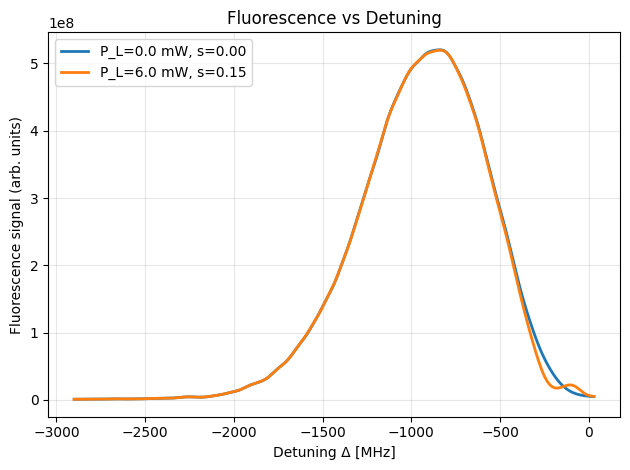

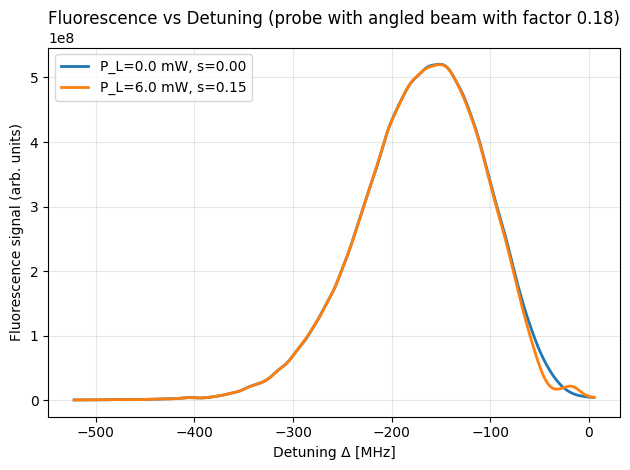

In [ ]:
# fluorescence signal calculation (convolution of f(v) with R_sc)
delta_range = np.linspace(-100 * Gamma_399, 1 * Gamma_399, 3000)

F_Final_list = []
for i, flux_final in enumerate(flux_final_list):
    # Use the matching velocity grid for each flux_final array
    v_grid_i = v_range_final_list[i]
    dv_i = v_grid_i[1] - v_grid_i[0]
    F_final = []
    for delta in delta_range:
        delta_eff = delta + k_399 * v_grid_i
        R_vals = R_sc(delta_eff, s_399)
        F_f = np.sum(flux_final * R_vals) * dv_i
        F_final.append(F_f)
    F_Final_list.append(np.array(F_final))

for i, F_final in enumerate(F_Final_list):
    label = f'P_L={P_L_list[i]*1e3:.1f} mW, s={s_list[i]:.2f}'
    plt.plot(delta_range/(2*np.pi*1e6), F_final, linewidth=2, label=label)
plt.xlabel('Detuning Δ [MHz]')
plt.ylabel('Fluorescence signal (arb. units)')
plt.title('Fluorescence vs Detuning')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for i, F_final in enumerate(F_Final_list):
    label = f'P_L={P_L_list[i]*1e3:.1f} mW, s={s_list[i]:.2f}'
    plt.plot(0.18*delta_range/(2*np.pi*1e6), F_final, linewidth=2, label=label)
plt.xlabel('Detuning Δ [MHz]')
plt.ylabel('Fluorescence signal (arb. units)')
plt.title('Fluorescence vs Detuning (probe with angled beam with factor 0.18)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


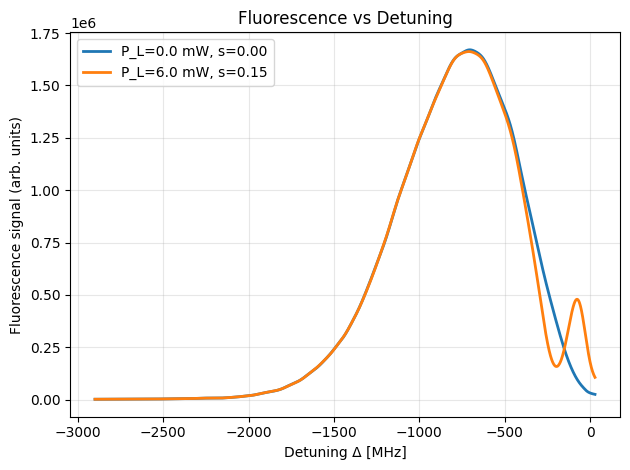

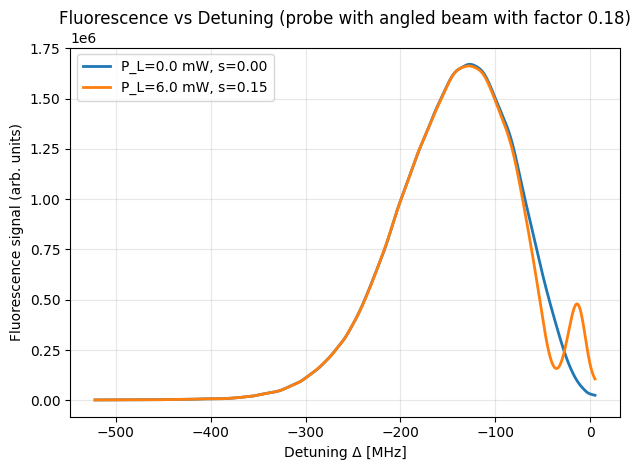

In [ ]:
# fluorescence signal calculation (convolution of f(v) with R_sc)
delta_range = np.linspace(-100 * Gamma_399, 1 * Gamma_399, 3000)

F_Final_list = []
for i, f_v_final in enumerate(f_v_final_list):
    # Use the matching velocity grid for each interpolator
    v_grid_i = v_range_final_list[i]
    f_vals_i = f_v_final(v_grid_i)
    F_final = []
    for delta in delta_range:
        delta_eff = delta + k_399 * v_grid_i
        R_vals = R_sc(delta_eff, s_399)
        F_f = np.trapz(f_vals_i * R_vals, v_grid_i)
        F_final.append(F_f)
    F_Final_list.append(np.array(F_final))

for i, F_final in enumerate(F_Final_list):
    label = f'P_L={P_L_list[i]*1e3:.1f} mW, s={s_list[i]:.2f}'
    plt.plot(delta_range/(2*np.pi*1e6), F_final, linewidth=2, label=label)
plt.xlabel('Detuning Δ [MHz]')
plt.ylabel('Fluorescence signal (arb. units)')
plt.title('Fluorescence vs Detuning')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for i, F_final in enumerate(F_Final_list):
    label = f'P_L={P_L_list[i]*1e3:.1f} mW, s={s_list[i]:.2f}'
    plt.plot(0.18*delta_range/(2*np.pi*1e6), F_final, linewidth=2, label=label)
plt.xlabel('Detuning Δ [MHz]')
plt.ylabel('Fluorescence signal (arb. units)')
plt.title('Fluorescence vs Detuning (probe with angled beam with factor 0.18)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2. compare with exp data, no mag, slow the atoms with -600MHz

In [147]:
# scan multiple laser powers and store each result set
P_L_list = [0, 3e-3, 6e-3]  # [W], edit this list as needed
new_B_func = lambda z: np.zeros_like(z)
delta_laser = -600 * 1e6 * 2 * np.pi
wL = 6.5e-3
slower_length = 0.2


# containers for all powers
all_final_velocities = []
all_exit_positions = []
all_exit_times = []
all_successful_slowing = []
results_by_power = []

# create ZS instance
slower = ZeemanSlower(Gamma_399, k_399, m_174, mu_eff_Yb, lmd_399)
t_max = 0.02    # maximum simulation time in seconds
n_points = 1000 # number of time points for ODE integration

# use most probable speed and MOT capture velocity to generate a fixed, ideal B-field
# new_B_func = slower.create_B_field_function(slower_length, v_p, v_c_MOT, delta_laser)
# simulate for when there's no magnetic field


I_sat_399 = 60 # mW/cm^2
I_list = 2*np.array(P_L_list)* 1e3 / (pi * (wL * 1e2)**2)  # convert to mW/cm^2
s_list = I_list / I_sat_399
print("Laser power (mW) and corresponding saturation parameter s:")
for P_L, s in zip(P_L_list, s_list):
    print(f"  P_L = {P_L*1e3:.2f} mW -> s = {s:.2f}")

for P_L in P_L_list:
    # initialize storage for this power
    final_velocities = np.zeros(n_samples)
    exit_positions = np.zeros(n_samples)
    exit_times = np.zeros(n_samples)
    successful_slowing = np.zeros(n_samples, dtype=bool)

    for i in range(n_samples):
        # get initial conditions for this atom
        z0 = 0.0
        rho0 = rho_0_array[i]      # initial radial position
        v0 = initial_velocities[i] # initial velocity

        try:
            # run simulation for this atom
            t, z, v, rho = slower.simulate_slower(
                z0=z0, rho0=rho0, v0=v0,
                delta_laser=delta_laser,
                B_func=new_B_func,
                P_L=P_L, wL=wL,
                slower_length=slower_length,
                t_max=t_max, n_points=n_points)

            # store results if simulation successful
            final_velocities[i] = v[-1]  # final velocity
            exit_positions[i] = z[-1]    # final position
            exit_times[i] = t[-1]        # final time
            # boolean array to count successfully slowed instances
            successful_slowing[i] = (v[-1] <= v_c_MOT) and (v[-1] > 0)

        except Exception:
            final_velocities[i] = v0  # keep initial velocity if simulation fails
            exit_positions[i] = 0.0
            exit_times[i] = 0.0
            successful_slowing[i] = False

    # store arrays for this power
    all_final_velocities.append(final_velocities.copy())
    all_exit_positions.append(exit_positions.copy())
    all_exit_times.append(exit_times.copy())
    all_successful_slowing.append(successful_slowing.copy())

    # store summary for this power
    summary = {
        "P_L": P_L,
        "n_success": int(np.sum(successful_slowing)),
        "success_ratio": float(np.mean(successful_slowing)),
        "mean_final_v": float(np.mean(final_velocities)),
        "std_final_v": float(np.std(final_velocities)),
        "min_final_v": float(np.min(final_velocities)),
        "max_final_v": float(np.max(final_velocities)),
    }
    results_by_power.append(summary)

    print(f"=== Simulation Results (P_L = {P_L*1e3:.2f} mW) ===")
    print(f"Total atoms simulated: {n_samples}")
    print(f"Successfully slowed (can be captured by MOT): {summary['n_success']} ({summary['success_ratio']*100:.1f}%)")
    print("Final velocity statistics:")
    print(f"  Mean: {summary['mean_final_v']:.2f} m/s")
    print(f"  Std: {summary['std_final_v']:.2f} m/s")
    print(f"  Min: {summary['min_final_v']:.2f} m/s")
    print(f"  Max: {summary['max_final_v']:.2f} m/s")
    print("")

# keep compatibility with downstream cells: default to the last P_L result
final_velocities = all_final_velocities[-1]
exit_positions = all_exit_positions[-1]
exit_times = all_exit_times[-1]
successful_slowing = all_successful_slowing[-1]

Laser power (mW) and corresponding saturation parameter s:
  P_L = 0.00 mW -> s = 0.00
  P_L = 3.00 mW -> s = 0.08
  P_L = 6.00 mW -> s = 0.15
=== Simulation Results (P_L = 0.00 mW) ===
Total atoms simulated: 10000
Successfully slowed (can be captured by MOT): 56 (0.6%)
Final velocity statistics:
  Mean: 280.73 m/s
  Std: 118.46 m/s
  Min: 12.13 m/s
  Max: 788.63 m/s

=== Simulation Results (P_L = 3.00 mW) ===
Total atoms simulated: 10000
Successfully slowed (can be captured by MOT): 60 (0.6%)
Final velocity statistics:
  Mean: 276.85 m/s
  Std: 119.99 m/s
  Min: 11.44 m/s
  Max: 788.63 m/s

=== Simulation Results (P_L = 6.00 mW) ===
Total atoms simulated: 10000
Successfully slowed (can be captured by MOT): 62 (0.6%)
Final velocity statistics:
  Mean: 274.54 m/s
  Std: 120.94 m/s
  Min: 9.93 m/s
  Max: 788.63 m/s



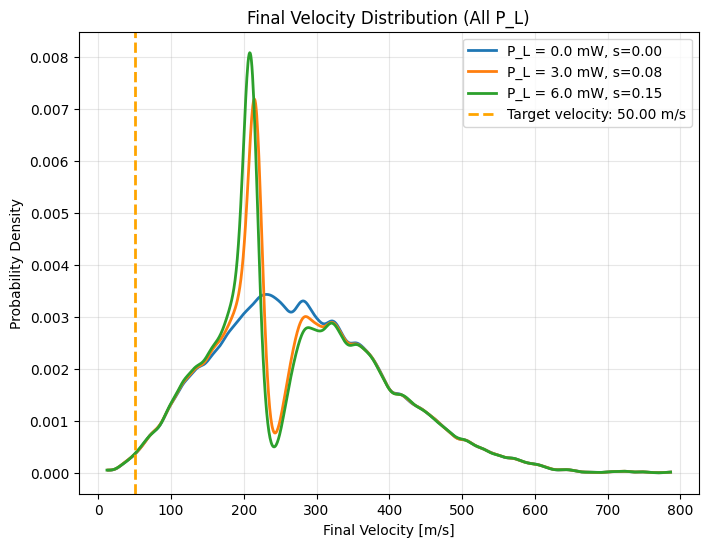

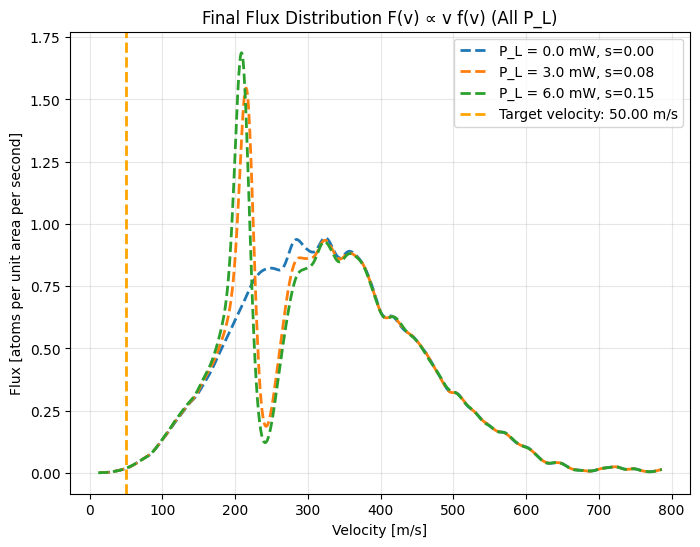

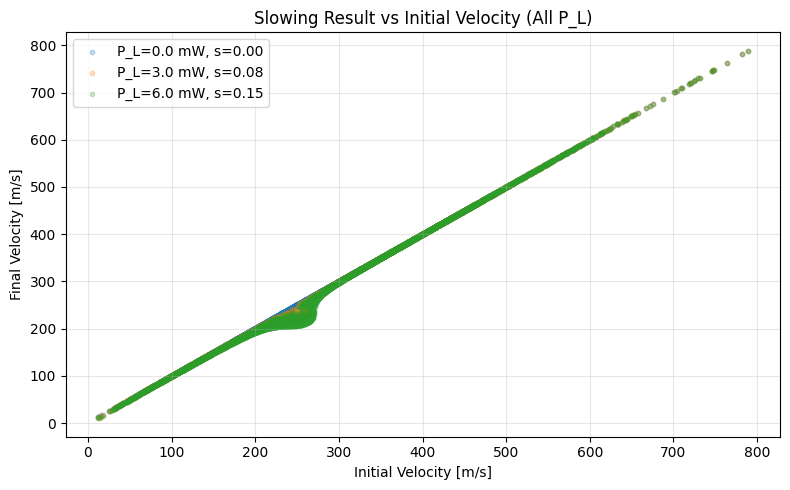

In [148]:
# plot all P_L results together with labels

# build smooth interpolations for each P_L
f_v_final_list = []
v_range_final_list = []
flux_final_list = []

for final_v in all_final_velocities:
    counts, edges = np.histogram(final_v, bins=200, density=True)
    centers = (edges[:-1] + edges[1:]) / 2
    counts_smooth = gaussian_filter1d(counts, sigma=2)
    f_v_final_i = interp1d(centers, counts_smooth, kind='cubic', bounds_error=False, fill_value=0)
    v_range_final_i = np.linspace(centers.min(), centers.max(), 1000)
    flux_final_i = np.where(v_range_final_i > 0, f_v_final_i(v_range_final_i) * v_range_final_i, 0.0)

    f_v_final_list.append(f_v_final_i)
    v_range_final_list.append(v_range_final_i)
    flux_final_list.append(flux_final_i)

# INITIAL velocity distribution (shared reference)
counts, edges = np.histogram(initial_velocities, bins=200, density=True)
centers = (edges[:-1] + edges[1:]) / 2
counts_smooth = gaussian_filter1d(counts, sigma=2)
f_v_initial = interp1d(centers, counts_smooth, kind='cubic', bounds_error=False, fill_value=0)
v_range_initial = np.linspace(centers.min(), centers.max(), 1000)
flux_initial = np.where(v_range_initial > 0, f_v_initial(v_range_initial) * v_range_initial, 0.0)

# keep compatibility with downstream cells
f_v_final = f_v_final_list[-1]
v_range_final = v_range_final_list[-1]

plt.figure(figsize=(8, 6))
for i, P_L in enumerate(P_L_list):
    label = f'P_L = {P_L*1e3:.1f} mW, s={s_list[i]:.2f}'
    plt.plot(v_range_final_list[i], f_v_final_list[i](v_range_final_list[i]), linewidth=2, label=label)
plt.axvline(v_c_MOT, color='orange', linestyle='--', linewidth=2, label=f'Target velocity: {v_c_MOT:.2f} m/s')
plt.xlabel('Final Velocity [m/s]')
plt.ylabel('Probability Density')
plt.title('Final Velocity Distribution (All P_L)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


plt.figure(figsize=(8, 6))
for i, P_L in enumerate(P_L_list):
    label = f'P_L = {P_L*1e3:.1f} mW, s={s_list[i]:.2f}'
    mask = v_range_final_list[i] > 0
    plt.plot(v_range_final_list[i][mask], flux_final_list[i][mask], '--', linewidth=2, label=label)
plt.axvline(v_c_MOT, color='orange', linestyle='--', linewidth=2, label=f'Target velocity: {v_c_MOT:.2f} m/s')
plt.xlabel('Velocity [m/s]')
plt.ylabel('Flux [atoms per unit area per second]')
plt.title('Final Flux Distribution F(v) ∝ v f(v) (All P_L)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
for i, P_L in enumerate(P_L_list):
    label = f'P_L={P_L*1e3:.1f} mW, s={s_list[i]:.2f}'
    plt.scatter(initial_velocities, all_final_velocities[i], alpha=0.25, s=10, label=label)
plt.xlabel('Initial Velocity [m/s]')
plt.ylabel('Final Velocity [m/s]')
plt.title('Slowing Result vs Initial Velocity (All P_L)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### fluorescence:
$$F(\Delta) = \int f(v) R_{sc}(\Delta + kv) dv$$
$$R_{sc}​(\Delta) = \frac{\Gamma}{2} \frac{s}{1+s+(2\Delta/\Gamma)^2}$$

#### 556 probe

In [149]:
Gamma_556 = 2 * np.pi * 182e3  # [rad/s]
k_556 = 2 * np.pi / 556e-9
I_sat_556 = 0.14 # mW/m^2
P_556 = 100 # mW
w_556 = 0.05 # cm
I_556 = 2 * P_556 / (pi * (w_556)**2) # mW/cm^2
s_556 = I_556 / I_sat_556
print(f"556nm transition saturation parameter: s = {s_556:.2f}")

556nm transition saturation parameter: s = 181891.36


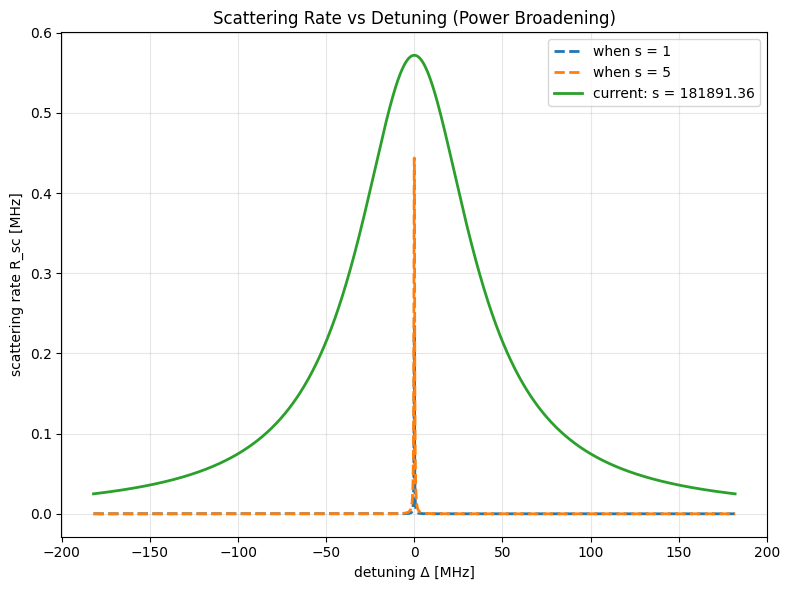

In [151]:
delta_range = np.linspace(-1000 * Gamma_556, 1000 * Gamma_556, 3000)

def R_sc(delta, s):
    return (Gamma_556/2) * (s / (1 + s + (2*delta/Gamma_556)**2))

R_sc1 = R_sc(delta_range, 1)
R_sc5 = R_sc(delta_range, 5)
R_sc10 = R_sc(delta_range, s_556)

plt.figure(figsize=(8,6))
plt.plot(delta_range/(2*np.pi*1e6), R_sc1/1e6, linestyle='--', linewidth=2, label='when s = 1')
plt.plot(delta_range/(2*np.pi*1e6), R_sc5/1e6, linestyle='--', linewidth=2, label='when s = 5')
plt.plot(delta_range/(2*np.pi*1e6), R_sc10/1e6, linewidth=2, label=f'current: s = {s_556:.2f}')
plt.xlabel("detuning Δ [MHz]")
plt.ylabel("scattering rate R_sc [MHz]")
plt.title("Scattering Rate vs Detuning (Power Broadening)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



convolve atom flux with 556 power broadening

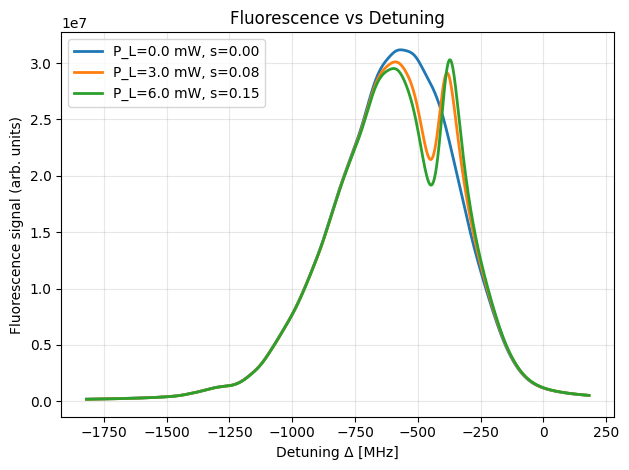

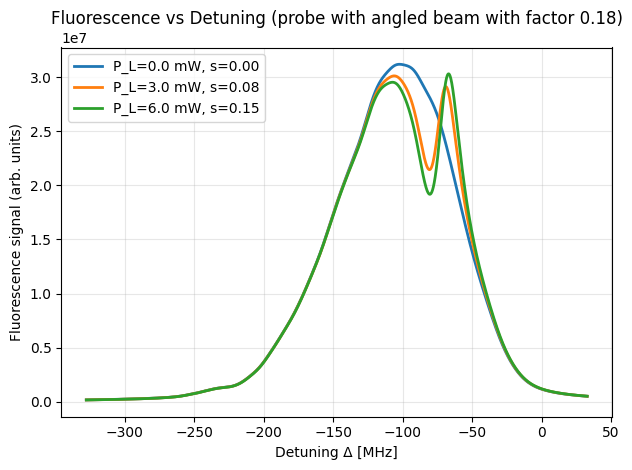

In [152]:
# fluorescence signal calculation (convolution of f(v) with R_sc)
delta_range = np.linspace(-10000 * Gamma_556, 1000 * Gamma_556, 3000)

F_Final_list = []
for i, flux_final in enumerate(flux_final_list):
    # Use the matching velocity grid for each flux_final array
    v_grid_i = v_range_final_list[i]
    dv_i = v_grid_i[1] - v_grid_i[0]
    F_final = []
    for delta in delta_range:
        delta_eff = delta + k_556 * v_grid_i
        R_vals = R_sc(delta_eff, s_556)
        F_f = np.sum(flux_final * R_vals) * dv_i
        F_final.append(F_f)
    F_Final_list.append(np.array(F_final))

for i, F_final in enumerate(F_Final_list):
    label = f'P_L={P_L_list[i]*1e3:.1f} mW, s={s_list[i]:.2f}'
    plt.plot(delta_range/(2*np.pi*1e6), F_final, linewidth=2, label=label)
plt.xlabel('Detuning Δ [MHz]')
plt.ylabel('Fluorescence signal (arb. units)')
plt.title('Fluorescence vs Detuning')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for i, F_final in enumerate(F_Final_list):
    label = f'P_L={P_L_list[i]*1e3:.1f} mW, s={s_list[i]:.2f}'
    plt.plot(0.18*delta_range/(2*np.pi*1e6), F_final, linewidth=2, label=label)
plt.xlabel('Detuning Δ [MHz]')
plt.ylabel('Fluorescence signal (arb. units)')
plt.title('Fluorescence vs Detuning (probe with angled beam with factor 0.18)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


convolve atom density with power broadening

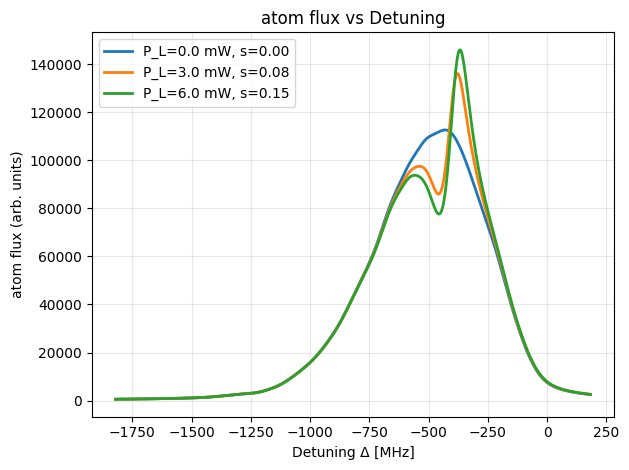

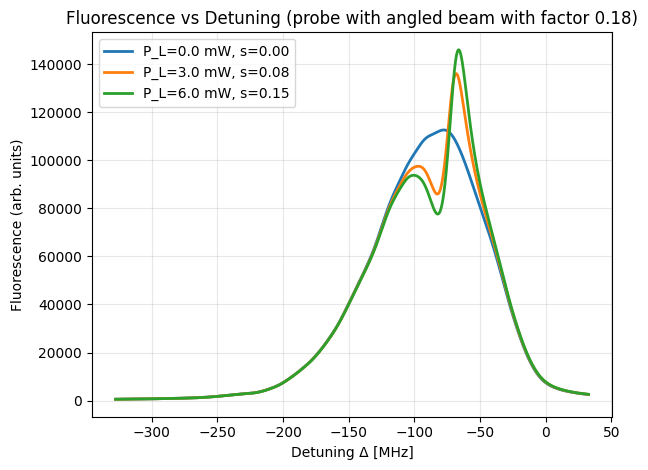

In [155]:
# fluorescence signal calculation (convolution of f(v) with R_sc)
delta_range = np.linspace(-10000 * Gamma_556, 1000 * Gamma_556, 3000)

F_Final_list = []
for i, f_v_final in enumerate(f_v_final_list):
    # Use the matching velocity grid for each interpolator
    v_grid_i = v_range_final_list[i]
    f_vals_i = f_v_final(v_grid_i)
    F_final = []
    for delta in delta_range:
        delta_eff = delta + k_556 * v_grid_i
        R_vals = R_sc(delta_eff, s_556)
        F_f = np.trapz(f_vals_i * R_vals, v_grid_i)
        F_final.append(F_f)
    F_Final_list.append(np.array(F_final))

for i, F_final in enumerate(F_Final_list):
    label = f'P_L={P_L_list[i]*1e3:.1f} mW, s={s_list[i]:.2f}'
    plt.plot(delta_range/(2*np.pi*1e6), F_final, linewidth=2, label=label)
plt.xlabel('Detuning Δ [MHz]')
plt.ylabel('atom flux (arb. units)')
plt.title('atom flux vs Detuning')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for i, F_final in enumerate(F_Final_list):
    label = f'P_L={P_L_list[i]*1e3:.1f} mW, s={s_list[i]:.2f}'
    plt.plot(0.18*delta_range/(2*np.pi*1e6), F_final, linewidth=2, label=label)
plt.xlabel('Detuning Δ [MHz]')
plt.ylabel('Fluorescence (arb. units)')
plt.title('Fluorescence vs Detuning (probe with angled beam with factor 0.18)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 399 isotope v spectrum mergement

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def model_func_all(f, f0, A, B, offset):
    f = np.array(f)
    y = np.zeros_like(f, dtype=float)
    mask = f <= f0
    y[mask] = A * np.abs(f[mask] - f0) ** 3 * np.exp(-B * (f[mask] - f0) ** 2) + offset
    return y

def sum_of_N_model_funcs(f, f0_list, A_list, B, offset=0):
    """
    计算N个 model_func_all 的和，每个的f0和A不同，B相同，offset只加一次。
    参数:
        f: 频率数组
        f0_list: 每个峰的f0列表
        A_list: 每个峰的A列表
        B: 所有峰共用的B
        offset: 总体偏置
    返回:
        y_sum: 所有峰之和的y值
    """
    y_sum = np.zeros_like(f, dtype=float)
    for f0, A in zip(f0_list, A_list):
        y_sum += model_func_all(f, f0, A, B, 0)
    y_sum += offset
    return y_sum

# 示例绘图
def plot_sum_of_N_model_funcs(f, f0_list, A_list, B, offset=0, show_peaks=True):
    """
    绘制N个 model_func_all 的和，并可选地绘制每个单独的峰。
    """
    y_sum = sum_of_N_model_funcs(f, f0_list, A_list, B, offset)
    plt.figure(figsize=(8,6))
    plt.plot(f/2/np.pi, y_sum, label='Sum of N model_func_all')
    if show_peaks:
        for idx, (f0, A) in enumerate(zip(f0_list, A_list)):
            y_peak = model_func_all(f, f0, A, B, 0)
            plt.plot(f/2/np.pi, y_peak, '--', label=f'Peak {idx+1}: f0={f0}, A={A}')
    plt.xlabel('Frequency/MHz')
    plt.ylabel('Sum of Brightness')
    plt.legend()
    plt.title('Sum of N model_func_all Curves')
    plt.show()

### five isotopes

In [131]:
T = 650
lmd_399 = 399e-9
m_174 = 173.9388675 * 1.66053906660e-27
k_B = 1.380649e-23
B_399 = m_174*lmd_399**2/2/k_B/T*1e12/(2*np.pi)**2
print(B_399)

6.489409126529303e-08


In [132]:
Gamma_399 = 2 * np.pi * 29e6  # [rad/s]
k_399 = 2 * np.pi / 399e-9
I_sat_399 = 60 # mW/m^2
P_399 = 20 # mW
w_399 = 0.6 # cm
I_399 = 2 * P_399 / (np.pi * (w_399)**2) # mW/cm^2
s_399 = I_399 / I_sat_399
print(f"399nm transition saturation parameter: s = {s_399:.2f}")

399nm transition saturation parameter: s = 0.59


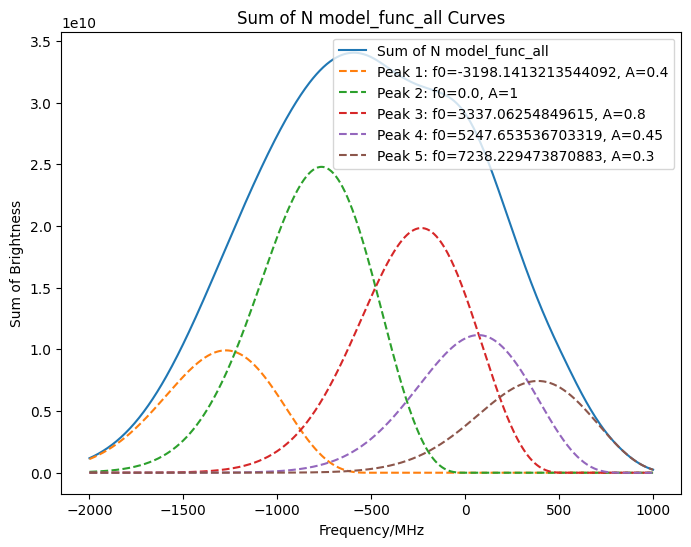

In [133]:
f = np.linspace(-2000, 1000, 500)*2*np.pi
f0_list = np.array([-509, 0, 531.11, 835.19, 1152])*2*np.pi
A_list = [0.4, 1, 0.8, 0.45, 0.3]
# B = 1e-5
B = B_399
plot_sum_of_N_model_funcs(f, f0_list, A_list, B, offset=0)

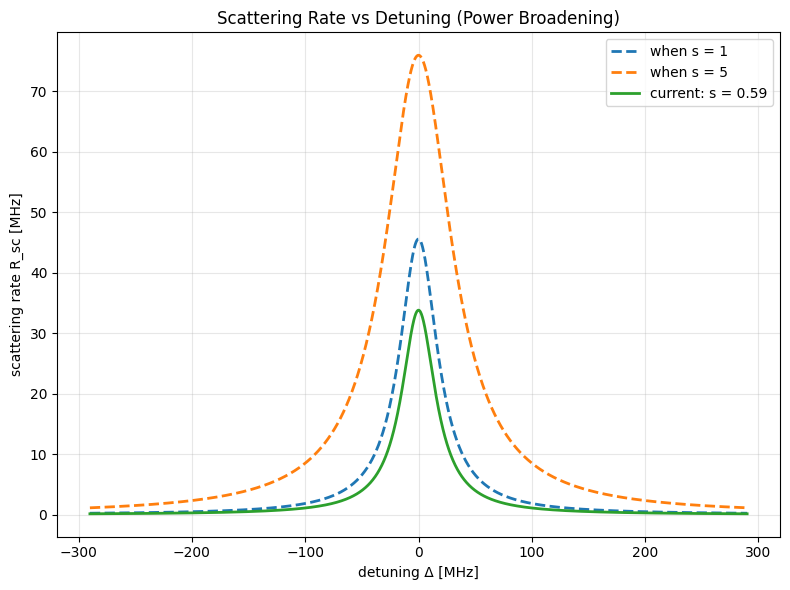

In [134]:
delta_range = np.linspace(-10 * Gamma_399, 10 * Gamma_399, 3000)

def R_sc(delta, s):
    return (Gamma_399/2) * (s / (1 + s + (2*delta/Gamma_399)**2))

R_sc1 = R_sc(delta_range, 1)
R_sc5 = R_sc(delta_range, 5)
R_sc10 = R_sc(delta_range, s_399)

plt.figure(figsize=(8,6))
plt.plot(delta_range/(2*np.pi*1e6), R_sc1/1e6, linestyle='--', linewidth=2, label='when s = 1')
plt.plot(delta_range/(2*np.pi*1e6), R_sc5/1e6, linestyle='--', linewidth=2, label='when s = 5')
plt.plot(delta_range/(2*np.pi*1e6), R_sc10/1e6, linewidth=2, label=f'current: s = {s_399:.2f}')
plt.xlabel("detuning Δ [MHz]")
plt.ylabel("scattering rate R_sc [MHz]")
plt.title("Scattering Rate vs Detuning (Power Broadening)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

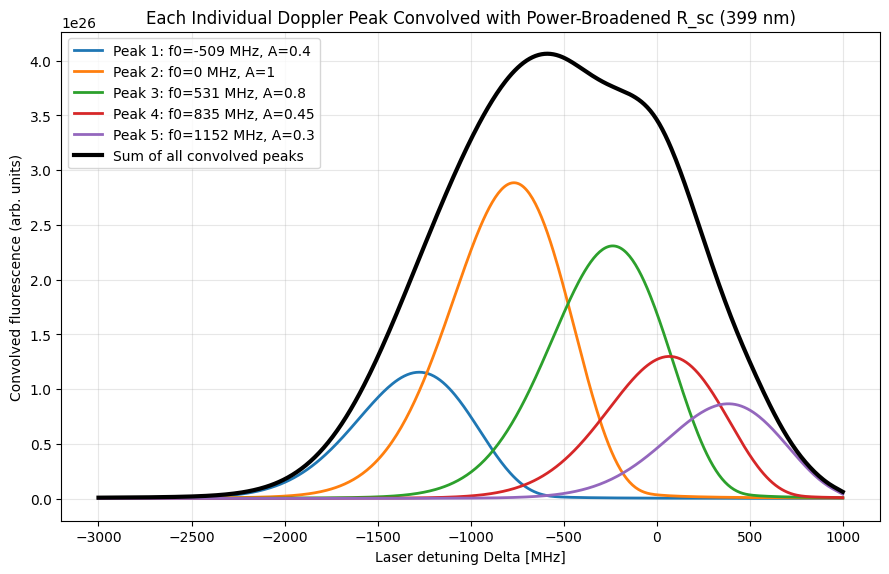

In [135]:
# Convolution of each individual Doppler-like peak with power-broadened R_sc (399 nm)
# F_i(Delta) = integral g_i(delta') * R_sc(Delta - delta', s_399) d(delta')

# Frequency axis used by model_func_all (same convention as your previous cell):
# f_model is in (MHz * 2pi)
f_MHz = np.linspace(-3000, 1000, 500)
f_model = f_MHz * 2 * np.pi

# Convert to SI detuning axis for R_sc evaluation (rad/s)
delta_axis = f_model * 1e6  # rad/s

# Laser detuning scan axis (choose same range for easy comparison)
delta_scan = delta_axis.copy()
delta_scan_MHz = delta_scan / (2 * np.pi * 1e6)

# Build each individual peak (NO summed curve)
peak_curves = []
for f0_i, A_i in zip(f0_list, A_list):
    g_i = model_func_all(f_model, f0_i, A_i, B_399, offset=0)
    peak_curves.append(g_i)

# Convolution for each peak
conv_each_peak = []
for g_i in peak_curves:
    F_i = np.zeros_like(delta_scan)
    for j, Delta in enumerate(delta_scan):
        # delta_eff = Delta - delta' : scan laser detuning against atomic spectral component
        R_vals = R_sc(Delta - delta_axis, s_399)
        F_i[j] = np.trapz(g_i * R_vals, delta_axis)
    conv_each_peak.append(F_i)

# Summed convolved signal across all peaks
sum_conv = np.sum(np.array(conv_each_peak), axis=0)

# Plot each convolved peak + summed curve
plt.figure(figsize=(9, 6))
for i, F_i in enumerate(conv_each_peak):
    plt.plot(delta_scan_MHz, F_i, linewidth=2, label=f'Peak {i+1}: f0={f0_list[i]/(2*np.pi):.0f} MHz, A={A_list[i]}')
plt.plot(delta_scan_MHz, sum_conv, color='k', linewidth=3, label='Sum of all convolved peaks')
plt.xlabel('Laser detuning Delta [MHz]')
plt.ylabel('Convolved fluorescence (arb. units)')
plt.title('Each Individual Doppler Peak Convolved with Power-Broadened R_sc (399 nm)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


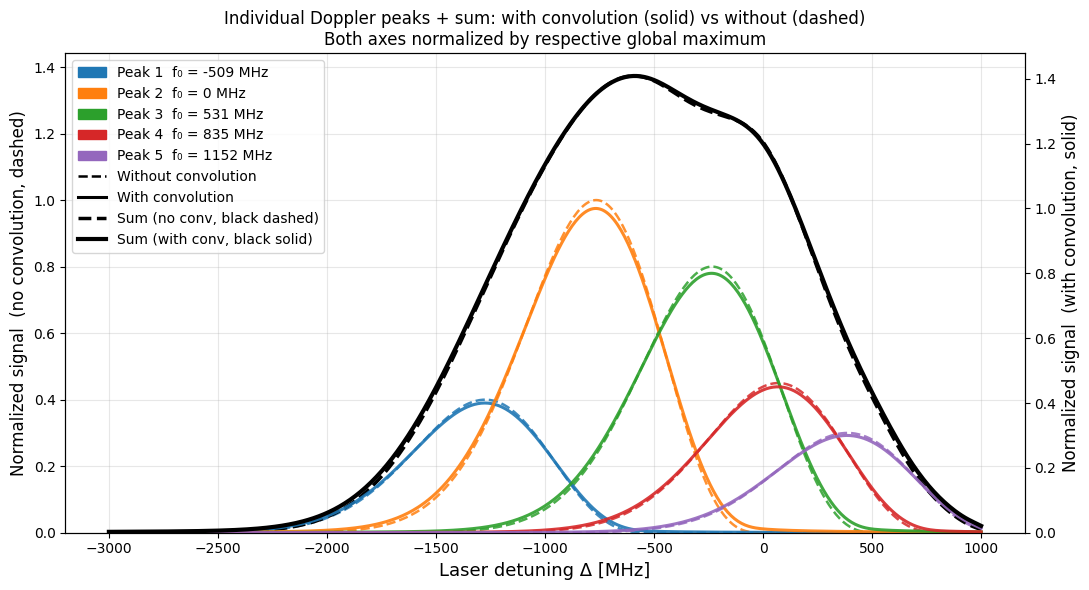

In [136]:

# Compare all 4 individual peaks + sum: with vs without convolution
# Normalize each group by its global maximum (different units → normalize by max for fair shape comparison)

# Build non-convolved peaks on the same frequency axis as the convolution result
raw_each_peak = []
for f0_i, A_i in zip(f0_list, A_list):
    raw_each_peak.append(model_func_all(f_model, f0_i, A_i, B_399, offset=0))
raw_sum = np.sum(np.array(raw_each_peak), axis=0)

# Global normalization factors (one per axis / quantity)
raw_max  = max(np.max(p) for p in raw_each_peak)
conv_max = max(np.max(c) for c in conv_each_peak)

# Peak labels: f0 in MHz (f0_list units are MHz·2π, divide by 2π to get MHz)
f0_MHz_vals = [f'{f0_i / (2 * np.pi):.0f}' for f0_i in f0_list]

colors = ['C0', 'C1', 'C2', 'C3', 'C4']

fig, ax1 = plt.subplots(figsize=(11, 6))
ax2 = ax1.twinx()

# Individual peaks
for i, (raw, conv, color, lbl) in enumerate(zip(raw_each_peak, conv_each_peak, colors, f0_MHz_vals)):
    raw_norm  = raw  / raw_max
    conv_norm = conv / conv_max
    ax1.plot(delta_scan_MHz, raw_norm,  '--', color=color, linewidth=1.8, alpha=0.85)
    ax2.plot(delta_scan_MHz, conv_norm, '-',  color=color, linewidth=2.2, alpha=0.90)

# Summed curves in black
ax1.plot(delta_scan_MHz, raw_sum / raw_max,         '--', color='k', linewidth=2.5, label='Sum (no conv)')
ax2.plot(delta_scan_MHz, sum_conv / conv_max,       '-',  color='k', linewidth=3.0, label='Sum (with conv)')

ax1.set_xlabel('Laser detuning Δ [MHz]', fontsize=13)
ax1.set_ylabel('Normalized signal  (no convolution, dashed)', fontsize=12)
ax2.set_ylabel('Normalized signal  (with convolution, solid)',  fontsize=12)
ax1.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)

# Combined legend: 5 color patches for peaks + sum + 2 line-style entries
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
peak_handles = [Patch(color=colors[i], label=f'Peak {i+1}  f₀ = {f0_MHz_vals[i]} MHz')
                for i in range(len(f0_list))]
style_handles = [
    Line2D([0], [0], color='k', lw=1.8, ls='--', label='Without convolution'),
    Line2D([0], [0], color='k', lw=2.2, ls='-',  label='With convolution'),
    Line2D([0], [0], color='k', lw=2.5, ls='--', label='Sum (no conv, black dashed)'),
    Line2D([0], [0], color='k', lw=3.0, ls='-',  label='Sum (with conv, black solid)'),
]
ax1.legend(handles=peak_handles + style_handles, loc='upper left', fontsize=10, ncol=1)

ax1.set_title('Individual Doppler peaks + sum: with convolution (solid) vs without (dashed)\n'
              'Both axes normalized by respective global maximum', fontsize=12)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


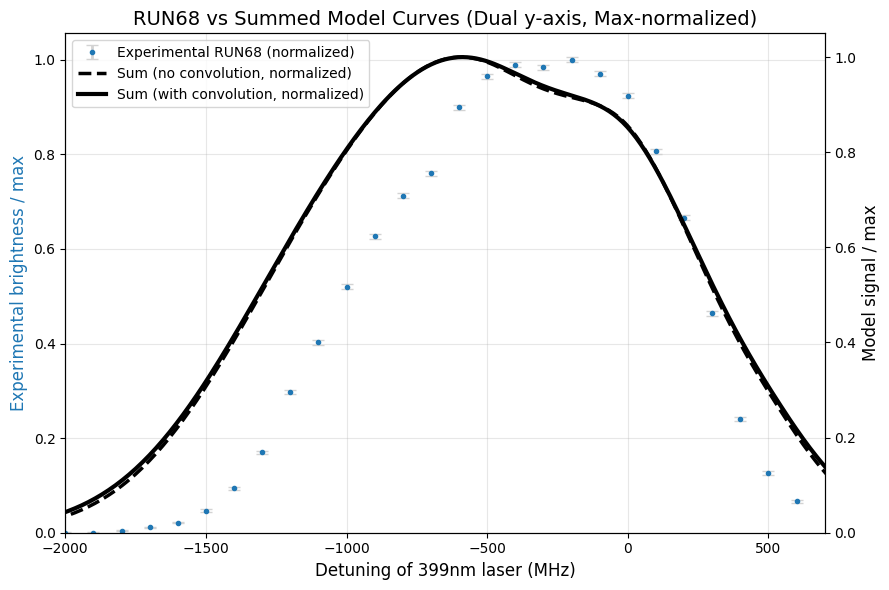

In [137]:
df_run68 = pd.read_csv("RUN68_freq_brightness_error.csv")

# Experimental data arrays
# col0: detuning for 798nm scan; convert to equivalent 399nm detuning by x2
# col1: brightness; col2: error bar
detun_f_798 = df_run68.iloc[:, 0].to_numpy()
detun_f_399 = detun_f_798 * 2
brightness_f = df_run68.iloc[:, 1].to_numpy()
error_f = df_run68.iloc[:, 2].to_numpy()

# Normalize by each curve's own maximum
exp_max = np.max(brightness_f) if np.max(brightness_f) != 0 else 1.0
raw_sum_max = np.max(raw_sum) if np.max(raw_sum) != 0 else 1.0
conv_sum_max = np.max(sum_conv) if np.max(sum_conv) != 0 else 1.0

brightness_norm = brightness_f / exp_max
error_norm = error_f / exp_max
raw_sum_norm = raw_sum / raw_sum_max
sum_conv_norm = sum_conv / conv_sum_max

# Dual-y plot: experiment (left), model sums (right)
fig, ax1 = plt.subplots(figsize=(9, 6))
ax2 = ax1.twinx()

# Left axis: experimental normalized data with error bars
ax1.errorbar(
    detun_f_399,
    brightness_norm,
    yerr=error_norm,
    fmt='o',
    color='tab:blue',
    ecolor='lightgray',
    elinewidth=2,
    capsize=4,
    markersize=3,
    label='Experimental RUN68 (normalized)'
)

# Right axis: theoretical summed curves (both black)
ax2.plot(delta_scan_MHz, raw_sum_norm, '--', color='k', linewidth=2.5, label='Sum (no convolution, normalized)')
ax2.plot(delta_scan_MHz, sum_conv_norm, '-', color='k', linewidth=3.0, label='Sum (with convolution, normalized)')

ax1.set_xlabel('Detuning of 399nm laser (MHz)', fontsize=12)
ax1.set_ylabel('Experimental brightness / max', fontsize=12, color='tab:blue')
ax2.set_ylabel('Model signal / max', fontsize=12, color='k')

ax1.set_xlim(-2000, 700)
ax1.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)
ax1.grid(True, alpha=0.3)
ax1.set_title('RUN68 vs Summed Model Curves (Dual y-axis, Max-normalized)', fontsize=14)

# Combined legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left')

plt.tight_layout()
plt.show()

### three isotopes

In [138]:
T = 650
lmd_399 = 399e-9
m_174 = 173.9388675 * 1.66053906660e-27
k_B = 1.380649e-23
B_399 = m_174*lmd_399**2/2/k_B/T*1e12/(2*np.pi)**2
print(B_399)

6.489409126529303e-08


In [139]:
Gamma_399 = 2 * np.pi * 29e6  # [rad/s]
k_399 = 2 * np.pi / 399e-9
I_sat_399 = 60 # mW/m^2
P_399 = 20 # mW
w_399 = 0.6 # cm
I_399 = 2 * P_399 / (np.pi * (w_399)**2) # mW/cm^2
s_399 = I_399 / I_sat_399
print(f"399nm transition saturation parameter: s = {s_399:.2f}")

399nm transition saturation parameter: s = 0.59


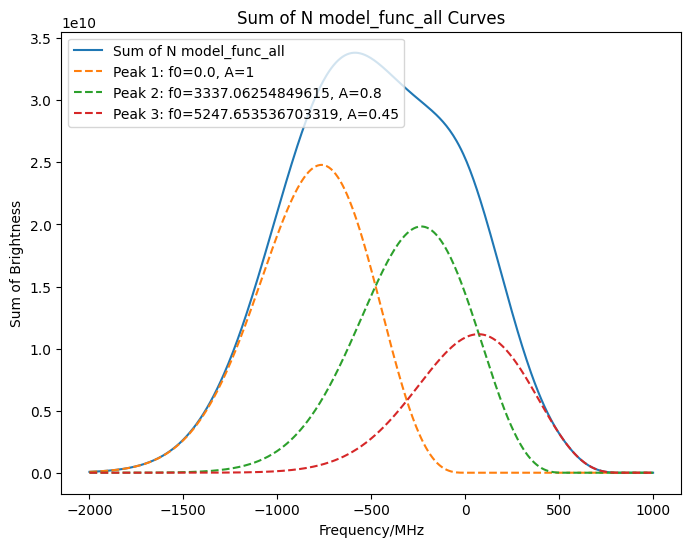

In [140]:
f = np.linspace(-2000, 1000, 500)*2*np.pi
f0_list = np.array([0, 531.11, 835.19])*2*np.pi
A_list = [1, 0.8, 0.45]
# B = 1e-5
B = B_399
plot_sum_of_N_model_funcs(f, f0_list, A_list, B, offset=0)

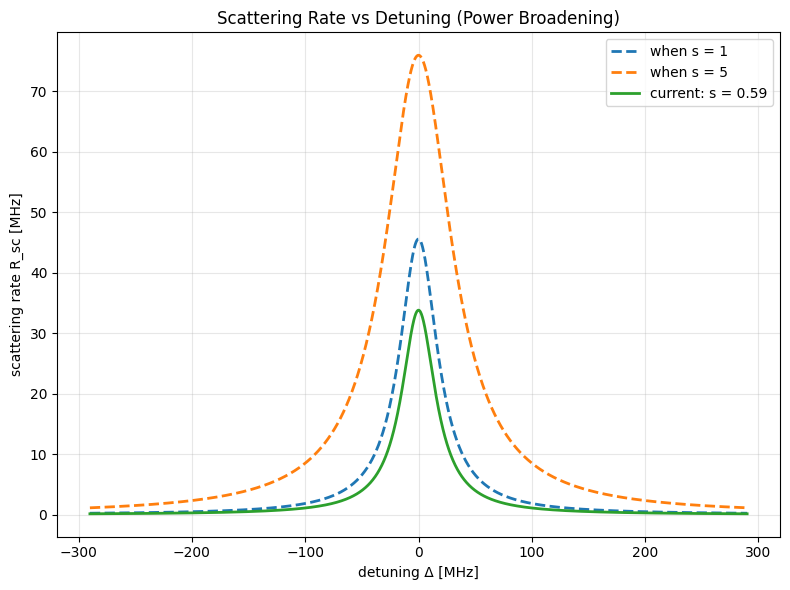

In [141]:
delta_range = np.linspace(-10 * Gamma_399, 10 * Gamma_399, 3000)

def R_sc(delta, s):
    return (Gamma_399/2) * (s / (1 + s + (2*delta/Gamma_399)**2))

R_sc1 = R_sc(delta_range, 1)
R_sc5 = R_sc(delta_range, 5)
R_sc10 = R_sc(delta_range, s_399)

plt.figure(figsize=(8,6))
plt.plot(delta_range/(2*np.pi*1e6), R_sc1/1e6, linestyle='--', linewidth=2, label='when s = 1')
plt.plot(delta_range/(2*np.pi*1e6), R_sc5/1e6, linestyle='--', linewidth=2, label='when s = 5')
plt.plot(delta_range/(2*np.pi*1e6), R_sc10/1e6, linewidth=2, label=f'current: s = {s_399:.2f}')
plt.xlabel("detuning Δ [MHz]")
plt.ylabel("scattering rate R_sc [MHz]")
plt.title("Scattering Rate vs Detuning (Power Broadening)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

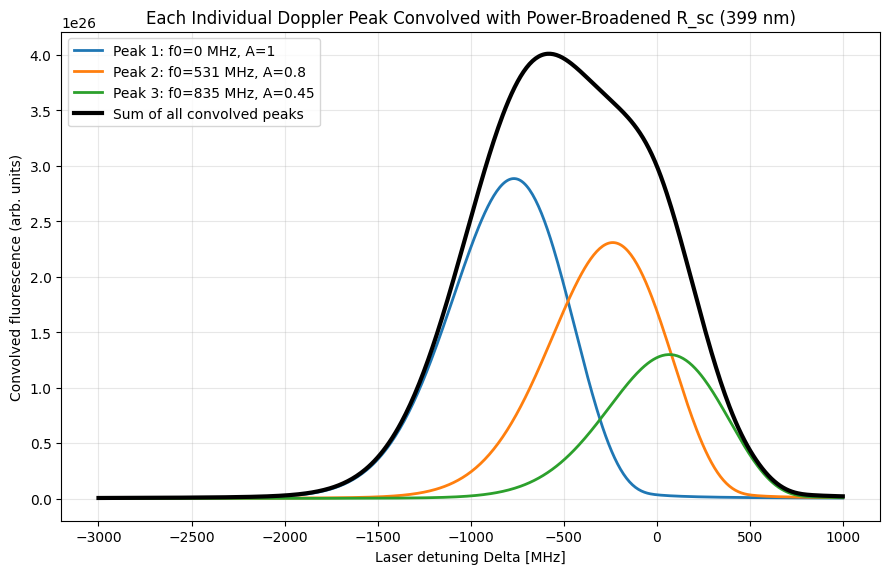

In [142]:
# Convolution of each individual Doppler-like peak with power-broadened R_sc (399 nm)
# F_i(Delta) = integral g_i(delta') * R_sc(Delta - delta', s_399) d(delta')

# Frequency axis used by model_func_all (same convention as your previous cell):
# f_model is in (MHz * 2pi)
f_MHz = np.linspace(-3000, 1000, 500)
f_model = f_MHz * 2 * np.pi

# Convert to SI detuning axis for R_sc evaluation (rad/s)
delta_axis = f_model * 1e6  # rad/s

# Laser detuning scan axis (choose same range for easy comparison)
delta_scan = delta_axis.copy()
delta_scan_MHz = delta_scan / (2 * np.pi * 1e6)

# Build each individual peak (NO summed curve)
peak_curves = []
for f0_i, A_i in zip(f0_list, A_list):
    g_i = model_func_all(f_model, f0_i, A_i, B_399, offset=0)
    peak_curves.append(g_i)

# Convolution for each peak
conv_each_peak = []
for g_i in peak_curves:
    F_i = np.zeros_like(delta_scan)
    for j, Delta in enumerate(delta_scan):
        # delta_eff = Delta - delta' : scan laser detuning against atomic spectral component
        R_vals = R_sc(Delta - delta_axis, s_399)
        F_i[j] = np.trapz(g_i * R_vals, delta_axis)
    conv_each_peak.append(F_i)

# Summed convolved signal across all peaks
sum_conv = np.sum(np.array(conv_each_peak), axis=0)

# Plot each convolved peak + summed curve
plt.figure(figsize=(9, 6))
for i, F_i in enumerate(conv_each_peak):
    plt.plot(delta_scan_MHz, F_i, linewidth=2, label=f'Peak {i+1}: f0={f0_list[i]/(2*np.pi):.0f} MHz, A={A_list[i]}')
plt.plot(delta_scan_MHz, sum_conv, color='k', linewidth=3, label='Sum of all convolved peaks')
plt.xlabel('Laser detuning Delta [MHz]')
plt.ylabel('Convolved fluorescence (arb. units)')
plt.title('Each Individual Doppler Peak Convolved with Power-Broadened R_sc (399 nm)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


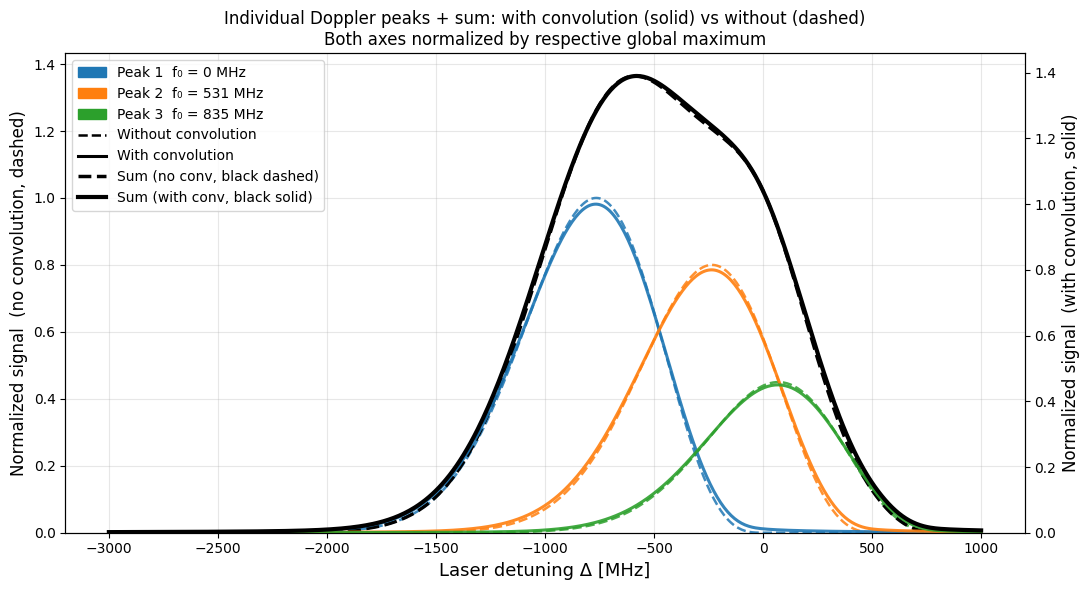

In [143]:

# Compare all 4 individual peaks + sum: with vs without convolution
# Normalize each group by its global maximum (different units → normalize by max for fair shape comparison)

# Build non-convolved peaks on the same frequency axis as the convolution result
raw_each_peak = []
for f0_i, A_i in zip(f0_list, A_list):
    raw_each_peak.append(model_func_all(f_model, f0_i, A_i, B_399, offset=0))
raw_sum = np.sum(np.array(raw_each_peak), axis=0)

# Global normalization factors (one per axis / quantity)
raw_max  = max(np.max(p) for p in raw_each_peak)
conv_max = max(np.max(c) for c in conv_each_peak)

# Peak labels: f0 in MHz (f0_list units are MHz·2π, divide by 2π to get MHz)
f0_MHz_vals = [f'{f0_i / (2 * np.pi):.0f}' for f0_i in f0_list]

colors = ['C0', 'C1', 'C2', 'C3', 'C4']

fig, ax1 = plt.subplots(figsize=(11, 6))
ax2 = ax1.twinx()

# Individual peaks
for i, (raw, conv, color, lbl) in enumerate(zip(raw_each_peak, conv_each_peak, colors, f0_MHz_vals)):
    raw_norm  = raw  / raw_max
    conv_norm = conv / conv_max
    ax1.plot(delta_scan_MHz, raw_norm,  '--', color=color, linewidth=1.8, alpha=0.85)
    ax2.plot(delta_scan_MHz, conv_norm, '-',  color=color, linewidth=2.2, alpha=0.90)

# Summed curves in black
ax1.plot(delta_scan_MHz, raw_sum / raw_max,         '--', color='k', linewidth=2.5, label='Sum (no conv)')
ax2.plot(delta_scan_MHz, sum_conv / conv_max,       '-',  color='k', linewidth=3.0, label='Sum (with conv)')

ax1.set_xlabel('Laser detuning Δ [MHz]', fontsize=13)
ax1.set_ylabel('Normalized signal  (no convolution, dashed)', fontsize=12)
ax2.set_ylabel('Normalized signal  (with convolution, solid)',  fontsize=12)
ax1.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)

# Combined legend: 5 color patches for peaks + sum + 2 line-style entries
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
peak_handles = [Patch(color=colors[i], label=f'Peak {i+1}  f₀ = {f0_MHz_vals[i]} MHz')
                for i in range(len(f0_list))]
style_handles = [
    Line2D([0], [0], color='k', lw=1.8, ls='--', label='Without convolution'),
    Line2D([0], [0], color='k', lw=2.2, ls='-',  label='With convolution'),
    Line2D([0], [0], color='k', lw=2.5, ls='--', label='Sum (no conv, black dashed)'),
    Line2D([0], [0], color='k', lw=3.0, ls='-',  label='Sum (with conv, black solid)'),
]
ax1.legend(handles=peak_handles + style_handles, loc='upper left', fontsize=10, ncol=1)

ax1.set_title('Individual Doppler peaks + sum: with convolution (solid) vs without (dashed)\n'
              'Both axes normalized by respective global maximum', fontsize=12)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


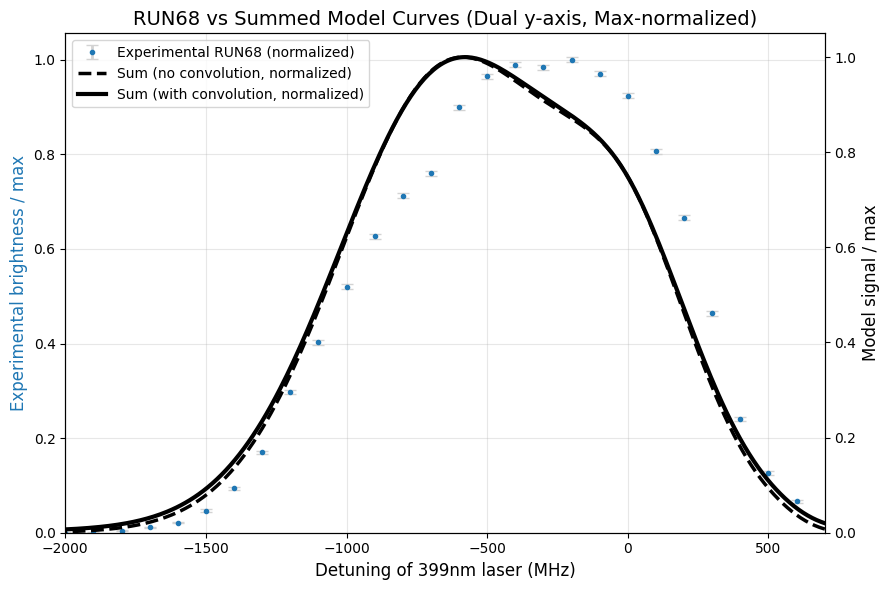

In [144]:
df_run68 = pd.read_csv("RUN68_freq_brightness_error.csv")

# Experimental data arrays
# col0: detuning for 798nm scan; convert to equivalent 399nm detuning by x2
# col1: brightness; col2: error bar
detun_f_798 = df_run68.iloc[:, 0].to_numpy()
detun_f_399 = detun_f_798 * 2
brightness_f = df_run68.iloc[:, 1].to_numpy()
error_f = df_run68.iloc[:, 2].to_numpy()

# Normalize by each curve's own maximum
exp_max = np.max(brightness_f) if np.max(brightness_f) != 0 else 1.0
raw_sum_max = np.max(raw_sum) if np.max(raw_sum) != 0 else 1.0
conv_sum_max = np.max(sum_conv) if np.max(sum_conv) != 0 else 1.0

brightness_norm = brightness_f / exp_max
error_norm = error_f / exp_max
raw_sum_norm = raw_sum / raw_sum_max
sum_conv_norm = sum_conv / conv_sum_max

# Dual-y plot: experiment (left), model sums (right)
fig, ax1 = plt.subplots(figsize=(9, 6))
ax2 = ax1.twinx()

# Left axis: experimental normalized data with error bars
ax1.errorbar(
    detun_f_399,
    brightness_norm,
    yerr=error_norm,
    fmt='o',
    color='tab:blue',
    ecolor='lightgray',
    elinewidth=2,
    capsize=4,
    markersize=3,
    label='Experimental RUN68 (normalized)'
)

# Right axis: theoretical summed curves (both black)
ax2.plot(delta_scan_MHz, raw_sum_norm, '--', color='k', linewidth=2.5, label='Sum (no convolution, normalized)')
ax2.plot(delta_scan_MHz, sum_conv_norm, '-', color='k', linewidth=3.0, label='Sum (with convolution, normalized)')

ax1.set_xlabel('Detuning of 399nm laser (MHz)', fontsize=12)
ax1.set_ylabel('Experimental brightness / max', fontsize=12, color='tab:blue')
ax2.set_ylabel('Model signal / max', fontsize=12, color='k')

ax1.set_xlim(-2000, 700)
ax1.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)
ax1.grid(True, alpha=0.3)
ax1.set_title('RUN68 vs Summed Model Curves (Dual y-axis, Max-normalized)', fontsize=14)

# Combined legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left')

plt.tight_layout()
plt.show()

### Conclusion: 
1. We see the mergement of 399 v spectrum because of isotopes, which is unlikely because of power broadening, although we forgot some exp data (e.g. 399 power and waist).
2. It's difficult to see the slowed atom flux by counter-propagating 399. As they are covered by Yb 173

## 556 isotope v spectrum mergement

### five isotopes

In [ ]:
T = 650
lmd_556 = 556e-9
m_174 = 173.9388675 * 1.66053906660e-27
k_B = 1.380649e-23
B_556 = m_174*lmd_556**2/2/k_B/T*1e12/(2*np.pi)**2
print(B_556)

6.489409126529303e-08


In [156]:
Gamma_556 = 2 * np.pi * 182e3  # [rad/s]
k_556 = 2 * np.pi / 556e-9
I_sat_556 = 0.14 # mW/m^2
P_556 = 100 # mW
w_556 = 0.05 # cm
I_556 = 2 * P_556 / (np.pi * (w_556)**2) # mW/cm^2
s_556 = I_556 / I_sat_556
print(f"556nm transition saturation parameter: s = {s_556:.2f}")

556nm transition saturation parameter: s = 181891.36


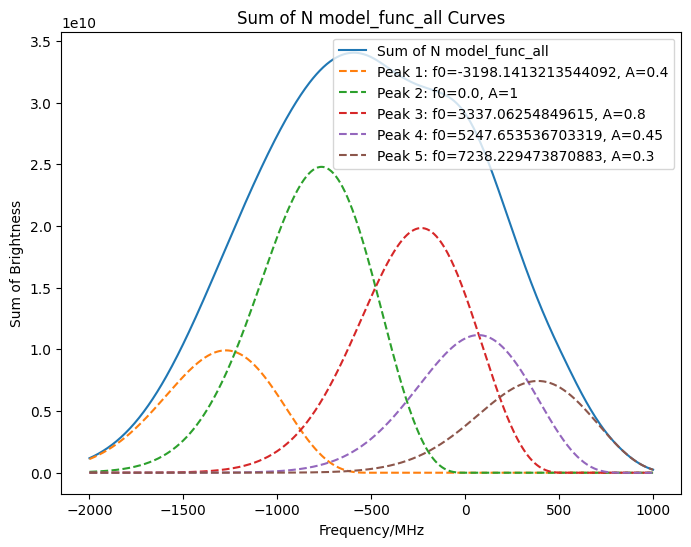

In [ ]:
f = np.linspace(-2000, 1000, 500)*2*np.pi
f0_list = np.array([-509, 0, 531.11, 835.19, 1152])*2*np.pi
A_list = [0.4, 1, 0.8, 0.45, 0.3]
# B = 1e-5
B = B_399
plot_sum_of_N_model_funcs(f, f0_list, A_list, B, offset=0)

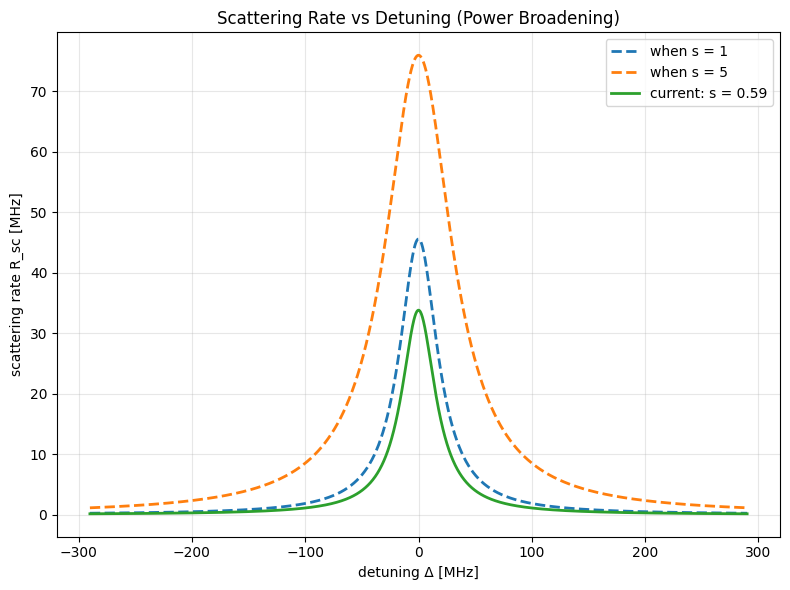

In [ ]:
delta_range = np.linspace(-10 * Gamma_399, 10 * Gamma_399, 3000)

def R_sc(delta, s):
    return (Gamma_399/2) * (s / (1 + s + (2*delta/Gamma_399)**2))

R_sc1 = R_sc(delta_range, 1)
R_sc5 = R_sc(delta_range, 5)
R_sc10 = R_sc(delta_range, s_399)

plt.figure(figsize=(8,6))
plt.plot(delta_range/(2*np.pi*1e6), R_sc1/1e6, linestyle='--', linewidth=2, label='when s = 1')
plt.plot(delta_range/(2*np.pi*1e6), R_sc5/1e6, linestyle='--', linewidth=2, label='when s = 5')
plt.plot(delta_range/(2*np.pi*1e6), R_sc10/1e6, linewidth=2, label=f'current: s = {s_399:.2f}')
plt.xlabel("detuning Δ [MHz]")
plt.ylabel("scattering rate R_sc [MHz]")
plt.title("Scattering Rate vs Detuning (Power Broadening)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

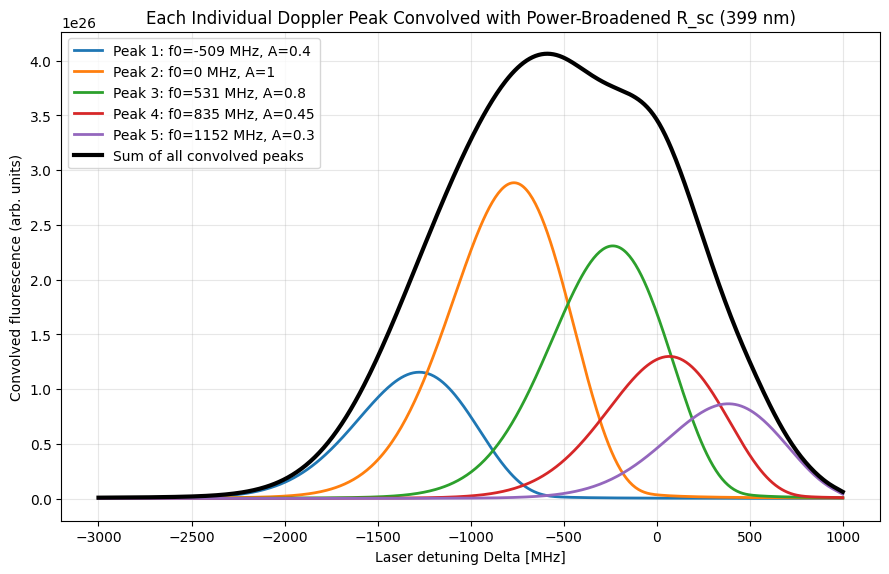

In [ ]:
# Convolution of each individual Doppler-like peak with power-broadened R_sc (399 nm)
# F_i(Delta) = integral g_i(delta') * R_sc(Delta - delta', s_399) d(delta')

# Frequency axis used by model_func_all (same convention as your previous cell):
# f_model is in (MHz * 2pi)
f_MHz = np.linspace(-3000, 1000, 500)
f_model = f_MHz * 2 * np.pi

# Convert to SI detuning axis for R_sc evaluation (rad/s)
delta_axis = f_model * 1e6  # rad/s

# Laser detuning scan axis (choose same range for easy comparison)
delta_scan = delta_axis.copy()
delta_scan_MHz = delta_scan / (2 * np.pi * 1e6)

# Build each individual peak (NO summed curve)
peak_curves = []
for f0_i, A_i in zip(f0_list, A_list):
    g_i = model_func_all(f_model, f0_i, A_i, B_399, offset=0)
    peak_curves.append(g_i)

# Convolution for each peak
conv_each_peak = []
for g_i in peak_curves:
    F_i = np.zeros_like(delta_scan)
    for j, Delta in enumerate(delta_scan):
        # delta_eff = Delta - delta' : scan laser detuning against atomic spectral component
        R_vals = R_sc(Delta - delta_axis, s_399)
        F_i[j] = np.trapz(g_i * R_vals, delta_axis)
    conv_each_peak.append(F_i)

# Summed convolved signal across all peaks
sum_conv = np.sum(np.array(conv_each_peak), axis=0)

# Plot each convolved peak + summed curve
plt.figure(figsize=(9, 6))
for i, F_i in enumerate(conv_each_peak):
    plt.plot(delta_scan_MHz, F_i, linewidth=2, label=f'Peak {i+1}: f0={f0_list[i]/(2*np.pi):.0f} MHz, A={A_list[i]}')
plt.plot(delta_scan_MHz, sum_conv, color='k', linewidth=3, label='Sum of all convolved peaks')
plt.xlabel('Laser detuning Delta [MHz]')
plt.ylabel('Convolved fluorescence (arb. units)')
plt.title('Each Individual Doppler Peak Convolved with Power-Broadened R_sc (399 nm)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


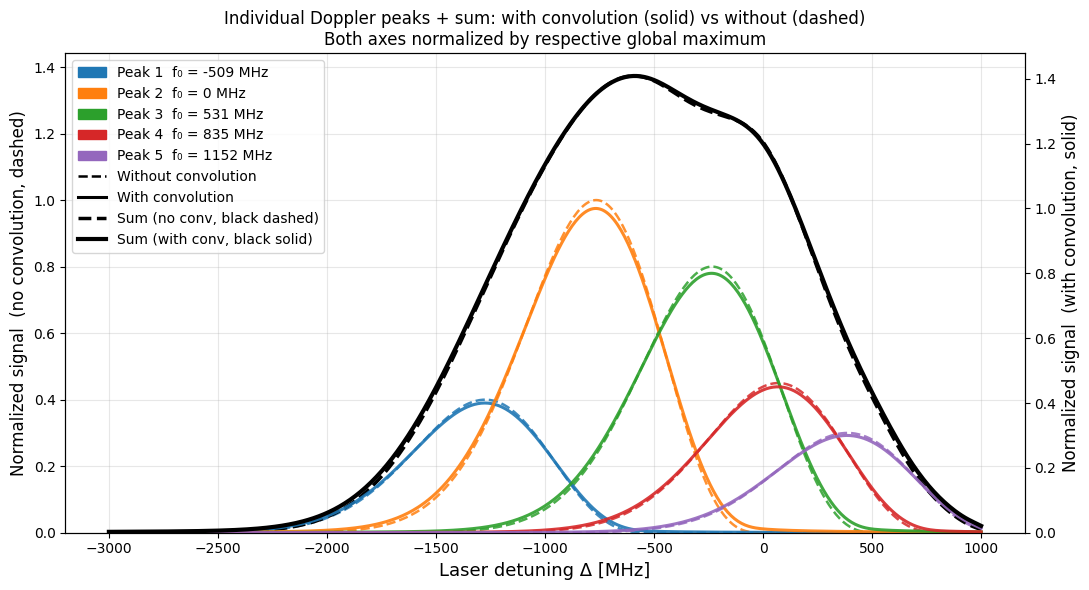

In [ ]:

# Compare all 4 individual peaks + sum: with vs without convolution
# Normalize each group by its global maximum (different units → normalize by max for fair shape comparison)

# Build non-convolved peaks on the same frequency axis as the convolution result
raw_each_peak = []
for f0_i, A_i in zip(f0_list, A_list):
    raw_each_peak.append(model_func_all(f_model, f0_i, A_i, B_399, offset=0))
raw_sum = np.sum(np.array(raw_each_peak), axis=0)

# Global normalization factors (one per axis / quantity)
raw_max  = max(np.max(p) for p in raw_each_peak)
conv_max = max(np.max(c) for c in conv_each_peak)

# Peak labels: f0 in MHz (f0_list units are MHz·2π, divide by 2π to get MHz)
f0_MHz_vals = [f'{f0_i / (2 * np.pi):.0f}' for f0_i in f0_list]

colors = ['C0', 'C1', 'C2', 'C3', 'C4']

fig, ax1 = plt.subplots(figsize=(11, 6))
ax2 = ax1.twinx()

# Individual peaks
for i, (raw, conv, color, lbl) in enumerate(zip(raw_each_peak, conv_each_peak, colors, f0_MHz_vals)):
    raw_norm  = raw  / raw_max
    conv_norm = conv / conv_max
    ax1.plot(delta_scan_MHz, raw_norm,  '--', color=color, linewidth=1.8, alpha=0.85)
    ax2.plot(delta_scan_MHz, conv_norm, '-',  color=color, linewidth=2.2, alpha=0.90)

# Summed curves in black
ax1.plot(delta_scan_MHz, raw_sum / raw_max,         '--', color='k', linewidth=2.5, label='Sum (no conv)')
ax2.plot(delta_scan_MHz, sum_conv / conv_max,       '-',  color='k', linewidth=3.0, label='Sum (with conv)')

ax1.set_xlabel('Laser detuning Δ [MHz]', fontsize=13)
ax1.set_ylabel('Normalized signal  (no convolution, dashed)', fontsize=12)
ax2.set_ylabel('Normalized signal  (with convolution, solid)',  fontsize=12)
ax1.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)

# Combined legend: 5 color patches for peaks + sum + 2 line-style entries
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
peak_handles = [Patch(color=colors[i], label=f'Peak {i+1}  f₀ = {f0_MHz_vals[i]} MHz')
                for i in range(len(f0_list))]
style_handles = [
    Line2D([0], [0], color='k', lw=1.8, ls='--', label='Without convolution'),
    Line2D([0], [0], color='k', lw=2.2, ls='-',  label='With convolution'),
    Line2D([0], [0], color='k', lw=2.5, ls='--', label='Sum (no conv, black dashed)'),
    Line2D([0], [0], color='k', lw=3.0, ls='-',  label='Sum (with conv, black solid)'),
]
ax1.legend(handles=peak_handles + style_handles, loc='upper left', fontsize=10, ncol=1)

ax1.set_title('Individual Doppler peaks + sum: with convolution (solid) vs without (dashed)\n'
              'Both axes normalized by respective global maximum', fontsize=12)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


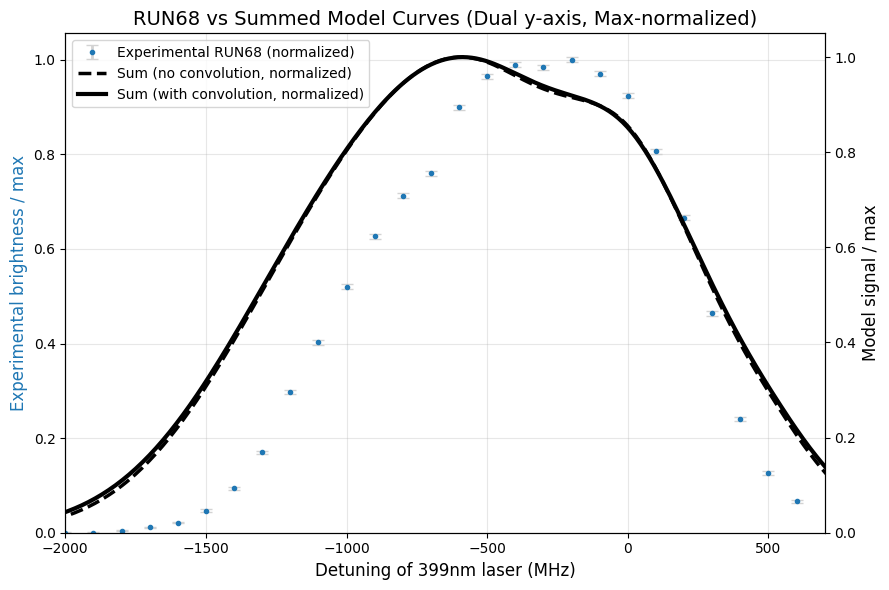

In [ ]:
df_run68 = pd.read_csv("RUN68_freq_brightness_error.csv")

# Experimental data arrays
# col0: detuning for 798nm scan; convert to equivalent 399nm detuning by x2
# col1: brightness; col2: error bar
detun_f_798 = df_run68.iloc[:, 0].to_numpy()
detun_f_399 = detun_f_798 * 2
brightness_f = df_run68.iloc[:, 1].to_numpy()
error_f = df_run68.iloc[:, 2].to_numpy()

# Normalize by each curve's own maximum
exp_max = np.max(brightness_f) if np.max(brightness_f) != 0 else 1.0
raw_sum_max = np.max(raw_sum) if np.max(raw_sum) != 0 else 1.0
conv_sum_max = np.max(sum_conv) if np.max(sum_conv) != 0 else 1.0

brightness_norm = brightness_f / exp_max
error_norm = error_f / exp_max
raw_sum_norm = raw_sum / raw_sum_max
sum_conv_norm = sum_conv / conv_sum_max

# Dual-y plot: experiment (left), model sums (right)
fig, ax1 = plt.subplots(figsize=(9, 6))
ax2 = ax1.twinx()

# Left axis: experimental normalized data with error bars
ax1.errorbar(
    detun_f_399,
    brightness_norm,
    yerr=error_norm,
    fmt='o',
    color='tab:blue',
    ecolor='lightgray',
    elinewidth=2,
    capsize=4,
    markersize=3,
    label='Experimental RUN68 (normalized)'
)

# Right axis: theoretical summed curves (both black)
ax2.plot(delta_scan_MHz, raw_sum_norm, '--', color='k', linewidth=2.5, label='Sum (no convolution, normalized)')
ax2.plot(delta_scan_MHz, sum_conv_norm, '-', color='k', linewidth=3.0, label='Sum (with convolution, normalized)')

ax1.set_xlabel('Detuning of 399nm laser (MHz)', fontsize=12)
ax1.set_ylabel('Experimental brightness / max', fontsize=12, color='tab:blue')
ax2.set_ylabel('Model signal / max', fontsize=12, color='k')

ax1.set_xlim(-2000, 700)
ax1.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)
ax1.grid(True, alpha=0.3)
ax1.set_title('RUN68 vs Summed Model Curves (Dual y-axis, Max-normalized)', fontsize=14)

# Combined legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left')

plt.tight_layout()
plt.show()

### three isotopes

In [ ]:
T = 650
lmd_399 = 399e-9
m_174 = 173.9388675 * 1.66053906660e-27
k_B = 1.380649e-23
B_399 = m_174*lmd_399**2/2/k_B/T*1e12/(2*np.pi)**2
print(B_399)

6.489409126529303e-08


In [ ]:
Gamma_399 = 2 * np.pi * 29e6  # [rad/s]
k_399 = 2 * np.pi / 399e-9
I_sat_399 = 60 # mW/m^2
P_399 = 20 # mW
w_399 = 0.6 # cm
I_399 = 2 * P_399 / (np.pi * (w_399)**2) # mW/cm^2
s_399 = I_399 / I_sat_399
print(f"399nm transition saturation parameter: s = {s_399:.2f}")

399nm transition saturation parameter: s = 0.59


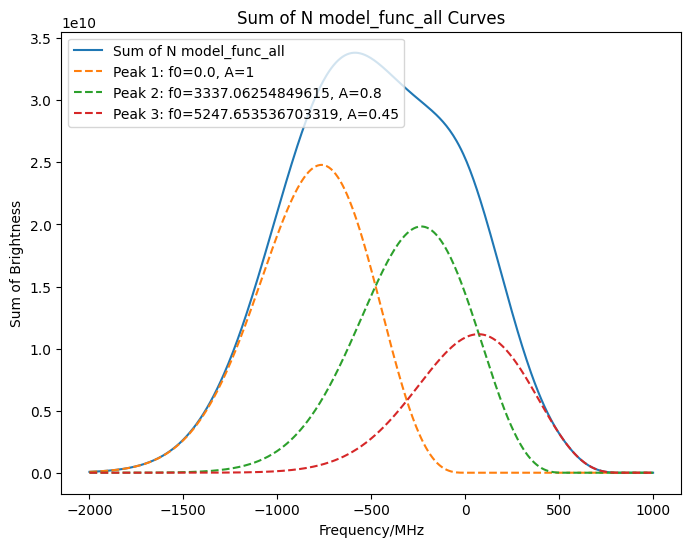

In [ ]:
f = np.linspace(-2000, 1000, 500)*2*np.pi
f0_list = np.array([0, 531.11, 835.19])*2*np.pi
A_list = [1, 0.8, 0.45]
# B = 1e-5
B = B_399
plot_sum_of_N_model_funcs(f, f0_list, A_list, B, offset=0)

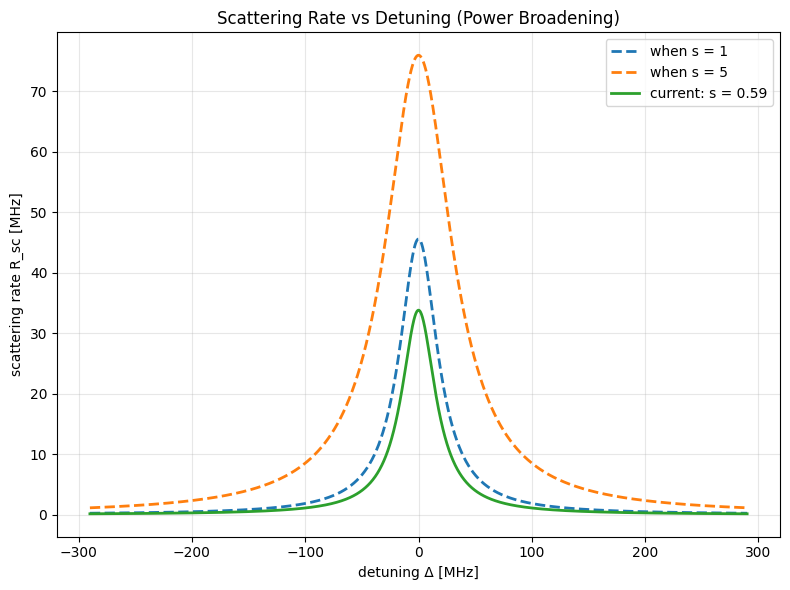

In [ ]:
delta_range = np.linspace(-10 * Gamma_399, 10 * Gamma_399, 3000)

def R_sc(delta, s):
    return (Gamma_399/2) * (s / (1 + s + (2*delta/Gamma_399)**2))

R_sc1 = R_sc(delta_range, 1)
R_sc5 = R_sc(delta_range, 5)
R_sc10 = R_sc(delta_range, s_399)

plt.figure(figsize=(8,6))
plt.plot(delta_range/(2*np.pi*1e6), R_sc1/1e6, linestyle='--', linewidth=2, label='when s = 1')
plt.plot(delta_range/(2*np.pi*1e6), R_sc5/1e6, linestyle='--', linewidth=2, label='when s = 5')
plt.plot(delta_range/(2*np.pi*1e6), R_sc10/1e6, linewidth=2, label=f'current: s = {s_399:.2f}')
plt.xlabel("detuning Δ [MHz]")
plt.ylabel("scattering rate R_sc [MHz]")
plt.title("Scattering Rate vs Detuning (Power Broadening)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

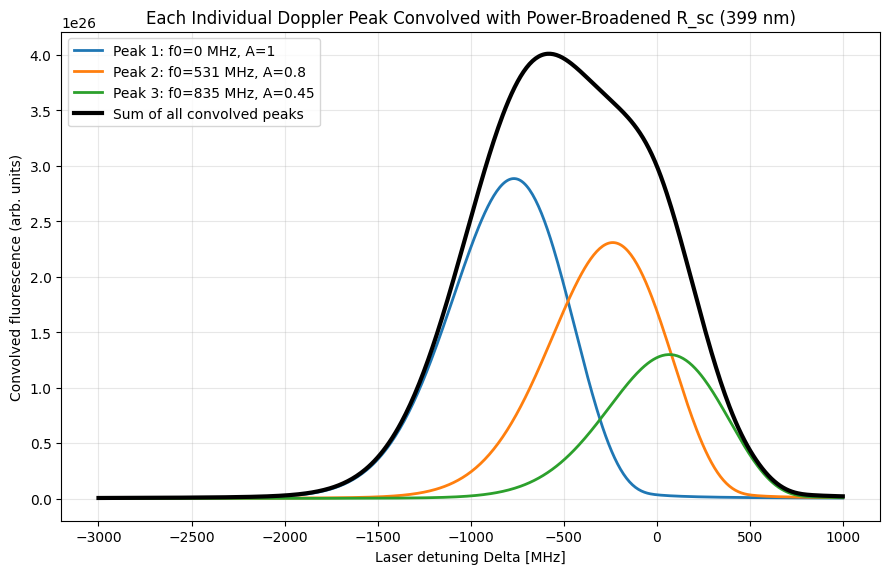

In [ ]:
# Convolution of each individual Doppler-like peak with power-broadened R_sc (399 nm)
# F_i(Delta) = integral g_i(delta') * R_sc(Delta - delta', s_399) d(delta')

# Frequency axis used by model_func_all (same convention as your previous cell):
# f_model is in (MHz * 2pi)
f_MHz = np.linspace(-3000, 1000, 500)
f_model = f_MHz * 2 * np.pi

# Convert to SI detuning axis for R_sc evaluation (rad/s)
delta_axis = f_model * 1e6  # rad/s

# Laser detuning scan axis (choose same range for easy comparison)
delta_scan = delta_axis.copy()
delta_scan_MHz = delta_scan / (2 * np.pi * 1e6)

# Build each individual peak (NO summed curve)
peak_curves = []
for f0_i, A_i in zip(f0_list, A_list):
    g_i = model_func_all(f_model, f0_i, A_i, B_399, offset=0)
    peak_curves.append(g_i)

# Convolution for each peak
conv_each_peak = []
for g_i in peak_curves:
    F_i = np.zeros_like(delta_scan)
    for j, Delta in enumerate(delta_scan):
        # delta_eff = Delta - delta' : scan laser detuning against atomic spectral component
        R_vals = R_sc(Delta - delta_axis, s_399)
        F_i[j] = np.trapz(g_i * R_vals, delta_axis)
    conv_each_peak.append(F_i)

# Summed convolved signal across all peaks
sum_conv = np.sum(np.array(conv_each_peak), axis=0)

# Plot each convolved peak + summed curve
plt.figure(figsize=(9, 6))
for i, F_i in enumerate(conv_each_peak):
    plt.plot(delta_scan_MHz, F_i, linewidth=2, label=f'Peak {i+1}: f0={f0_list[i]/(2*np.pi):.0f} MHz, A={A_list[i]}')
plt.plot(delta_scan_MHz, sum_conv, color='k', linewidth=3, label='Sum of all convolved peaks')
plt.xlabel('Laser detuning Delta [MHz]')
plt.ylabel('Convolved fluorescence (arb. units)')
plt.title('Each Individual Doppler Peak Convolved with Power-Broadened R_sc (399 nm)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


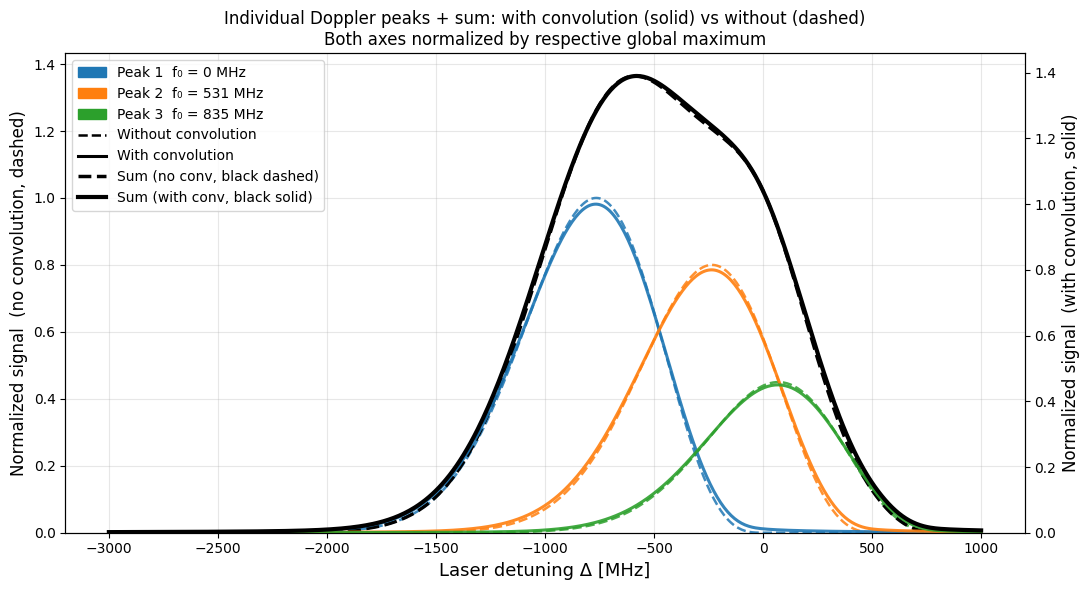

In [ ]:

# Compare all 4 individual peaks + sum: with vs without convolution
# Normalize each group by its global maximum (different units → normalize by max for fair shape comparison)

# Build non-convolved peaks on the same frequency axis as the convolution result
raw_each_peak = []
for f0_i, A_i in zip(f0_list, A_list):
    raw_each_peak.append(model_func_all(f_model, f0_i, A_i, B_399, offset=0))
raw_sum = np.sum(np.array(raw_each_peak), axis=0)

# Global normalization factors (one per axis / quantity)
raw_max  = max(np.max(p) for p in raw_each_peak)
conv_max = max(np.max(c) for c in conv_each_peak)

# Peak labels: f0 in MHz (f0_list units are MHz·2π, divide by 2π to get MHz)
f0_MHz_vals = [f'{f0_i / (2 * np.pi):.0f}' for f0_i in f0_list]

colors = ['C0', 'C1', 'C2', 'C3', 'C4']

fig, ax1 = plt.subplots(figsize=(11, 6))
ax2 = ax1.twinx()

# Individual peaks
for i, (raw, conv, color, lbl) in enumerate(zip(raw_each_peak, conv_each_peak, colors, f0_MHz_vals)):
    raw_norm  = raw  / raw_max
    conv_norm = conv / conv_max
    ax1.plot(delta_scan_MHz, raw_norm,  '--', color=color, linewidth=1.8, alpha=0.85)
    ax2.plot(delta_scan_MHz, conv_norm, '-',  color=color, linewidth=2.2, alpha=0.90)

# Summed curves in black
ax1.plot(delta_scan_MHz, raw_sum / raw_max,         '--', color='k', linewidth=2.5, label='Sum (no conv)')
ax2.plot(delta_scan_MHz, sum_conv / conv_max,       '-',  color='k', linewidth=3.0, label='Sum (with conv)')

ax1.set_xlabel('Laser detuning Δ [MHz]', fontsize=13)
ax1.set_ylabel('Normalized signal  (no convolution, dashed)', fontsize=12)
ax2.set_ylabel('Normalized signal  (with convolution, solid)',  fontsize=12)
ax1.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)

# Combined legend: 5 color patches for peaks + sum + 2 line-style entries
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
peak_handles = [Patch(color=colors[i], label=f'Peak {i+1}  f₀ = {f0_MHz_vals[i]} MHz')
                for i in range(len(f0_list))]
style_handles = [
    Line2D([0], [0], color='k', lw=1.8, ls='--', label='Without convolution'),
    Line2D([0], [0], color='k', lw=2.2, ls='-',  label='With convolution'),
    Line2D([0], [0], color='k', lw=2.5, ls='--', label='Sum (no conv, black dashed)'),
    Line2D([0], [0], color='k', lw=3.0, ls='-',  label='Sum (with conv, black solid)'),
]
ax1.legend(handles=peak_handles + style_handles, loc='upper left', fontsize=10, ncol=1)

ax1.set_title('Individual Doppler peaks + sum: with convolution (solid) vs without (dashed)\n'
              'Both axes normalized by respective global maximum', fontsize=12)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


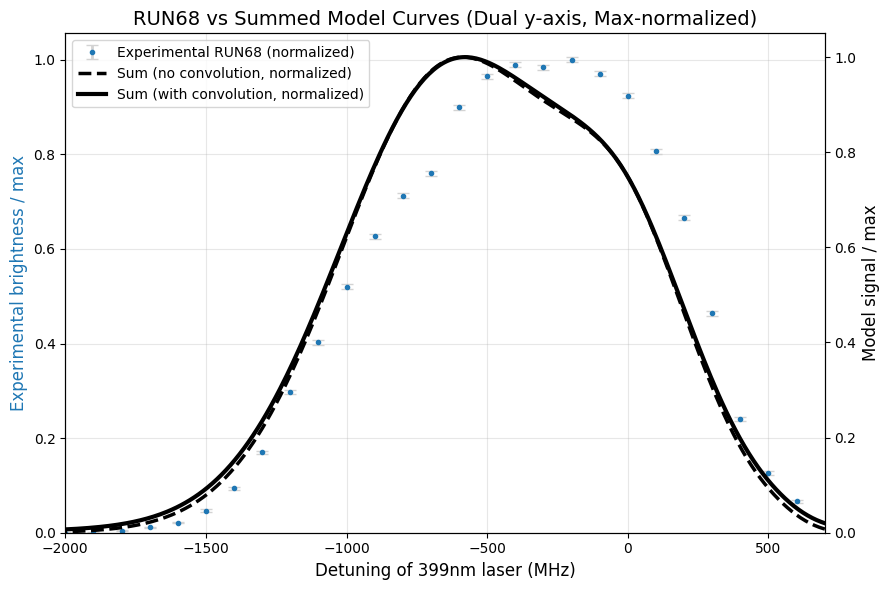

In [ ]:
df_run68 = pd.read_csv("RUN68_freq_brightness_error.csv")

# Experimental data arrays
# col0: detuning for 798nm scan; convert to equivalent 399nm detuning by x2
# col1: brightness; col2: error bar
detun_f_798 = df_run68.iloc[:, 0].to_numpy()
detun_f_399 = detun_f_798 * 2
brightness_f = df_run68.iloc[:, 1].to_numpy()
error_f = df_run68.iloc[:, 2].to_numpy()

# Normalize by each curve's own maximum
exp_max = np.max(brightness_f) if np.max(brightness_f) != 0 else 1.0
raw_sum_max = np.max(raw_sum) if np.max(raw_sum) != 0 else 1.0
conv_sum_max = np.max(sum_conv) if np.max(sum_conv) != 0 else 1.0

brightness_norm = brightness_f / exp_max
error_norm = error_f / exp_max
raw_sum_norm = raw_sum / raw_sum_max
sum_conv_norm = sum_conv / conv_sum_max

# Dual-y plot: experiment (left), model sums (right)
fig, ax1 = plt.subplots(figsize=(9, 6))
ax2 = ax1.twinx()

# Left axis: experimental normalized data with error bars
ax1.errorbar(
    detun_f_399,
    brightness_norm,
    yerr=error_norm,
    fmt='o',
    color='tab:blue',
    ecolor='lightgray',
    elinewidth=2,
    capsize=4,
    markersize=3,
    label='Experimental RUN68 (normalized)'
)

# Right axis: theoretical summed curves (both black)
ax2.plot(delta_scan_MHz, raw_sum_norm, '--', color='k', linewidth=2.5, label='Sum (no convolution, normalized)')
ax2.plot(delta_scan_MHz, sum_conv_norm, '-', color='k', linewidth=3.0, label='Sum (with convolution, normalized)')

ax1.set_xlabel('Detuning of 399nm laser (MHz)', fontsize=12)
ax1.set_ylabel('Experimental brightness / max', fontsize=12, color='tab:blue')
ax2.set_ylabel('Model signal / max', fontsize=12, color='k')

ax1.set_xlim(-2000, 700)
ax1.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)
ax1.grid(True, alpha=0.3)
ax1.set_title('RUN68 vs Summed Model Curves (Dual y-axis, Max-normalized)', fontsize=14)

# Combined legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left')

plt.tight_layout()
plt.show()

## 3. calculate the magnetic field
Yb171， 650K (from experiment fit)

decelerate from 320 m/s to 35 m/s in 0.21 m
Maximum achievable deceleration: a_max = -5.3e+05 m/s²
a/a_max: 0.45
s_design=0.8300084613267259
laser detuning -809.9999999999999 MHz
Testing B-field function:
B at z=0: 0.6 mT
B at end: 51.6 mT


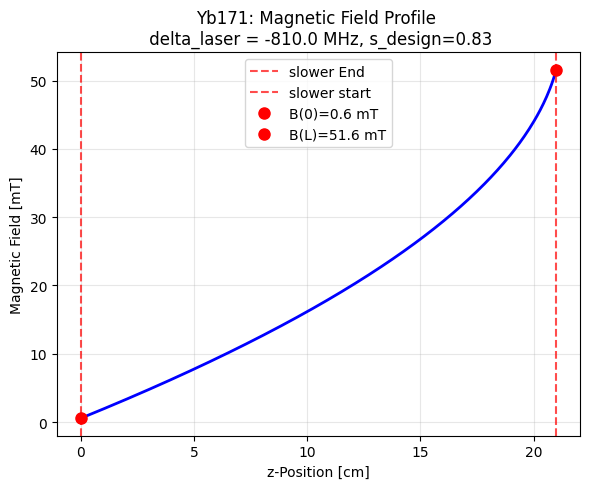

CSV saved: Yb171_single_atom_B_vs_z.csv


In [6]:
# single atom example

# Yb171 parameters
au = 1.66053906660e-27 # kg
m_171 = 171 * au
Gamma_399 = 2* np.pi *28.9e6  # [rad/s]
lmd_399 = 398.9e-9
k_399 = 2 * np.pi / lmd_399

g_e, g_g = 2/3, 0.0     # correct for 171Yb (1P1 -> 1S0)
M_e, M_g = -3/2, 1/2         # sigma - cycling transition
mu_B = e * hbar / (2 * m_e)
mu_eff_Yb = (g_e * M_e - g_g * M_g) * mu_B  # [J/T]

# create slower instance
slower = ZeemanSlower(Gamma_399, k_399, m_171, mu_eff_Yb, lmd_399)

z0 = 0.0
rho0 = 0    # 1mm radial offset
v0 = 320      # initial velocity m/s
delta_laser = 2 * np.pi * (-810) * 1e6 # rad/s
slower_length = 0.21  # m
v_final = 35  # m/s

a = (v_final**2 - v0**2) / (2 * slower_length)
a_max = -hbar * k_399 * Gamma_399 / (2 * m_171)
eta = a/a_max
s_design = eta/(1-eta)
print(f"decelerate from {v0} m/s to {v_final} m/s in {slower_length} m")
print(f"Maximum achievable deceleration: a_max = {a_max:.1e} m/s²")
print(f"a/a_max: {eta:.2f}")
print(f"s_design={s_design}")
print(f"laser detuning {delta_laser/2/np.pi/1e6} MHz")




# create B-field function using the new method
B_func = slower.create_B_field_function(slower_length, v0, v_final, delta_laser)

print("Testing B-field function:")
print(f"B at z=0: {B_func(0)*1000:.1f} mT")
print(f"B at end: {B_func(slower_length)*1000:.1f} mT")


# Yb171 (single atom) plots

# 1. magnetic field along ZS (changed units)
plt.figure(figsize=(6, 5))
z_plot = np.linspace(0, slower_length, 300)
B_plot = B_func(z_plot)
plt.plot(z_plot * 100, B_plot * 1e3, 'b-', linewidth=2)
plt.axvline(x=slower_length * 100, color='r', linestyle='--', alpha=0.7, label='slower End')
plt.axvline(x=0, color='r', linestyle='--', alpha=0.7, label='slower start')
plt.plot(0, B_func(0)*1000, 'ro', markersize=8, label=f'B(0)={B_func(0)*1000:.1f} mT')
plt.plot(slower_length * 100, B_func(slower_length)*1000, 'ro', markersize=8, label=f'B(L)={B_func(slower_length)*1000:.1f} mT')
plt.xlabel('z-Position [cm]')
plt.ylabel('Magnetic Field [mT]')
plt.title(f'Yb171: Magnetic Field Profile \n delta_laser = {delta_laser/(2*np.pi*1e6):.1f} MHz, s_design={s_design:.2f}')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Export B-field vs distance data to CSV
csv_data = np.column_stack((z_plot, z_plot * 100, B_plot, B_plot * 1e3))
csv_filename = 'Yb171_single_atom_B_vs_z.csv'
np.savetxt(csv_filename, csv_data, delimiter=',', header='z_m,z_cm,B_T,B_mT', comments='')
print(f'CSV saved: {csv_filename}')


Running simulation...

Simulation results:
Initial velocity: 300.0 m/s
Final velocity: 266.7 m/s
Velocity reduction: 33.3 m/s (11.1%)
Exit status: Exited
Saturation range: 0.535 - 0.535
Maximun scattering rate: 31.6 MHz
Maximum saturation: 0.535
Travel distance: 21.0 cm
Travel time: 0.8 ms


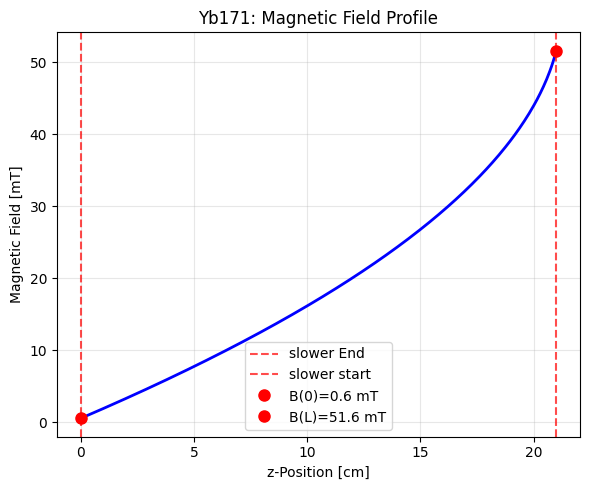

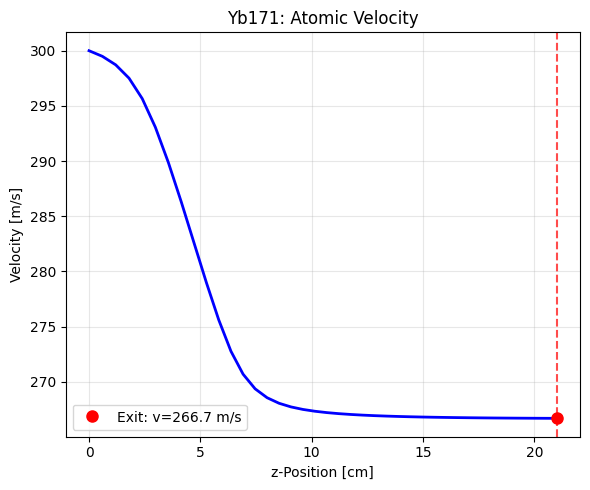

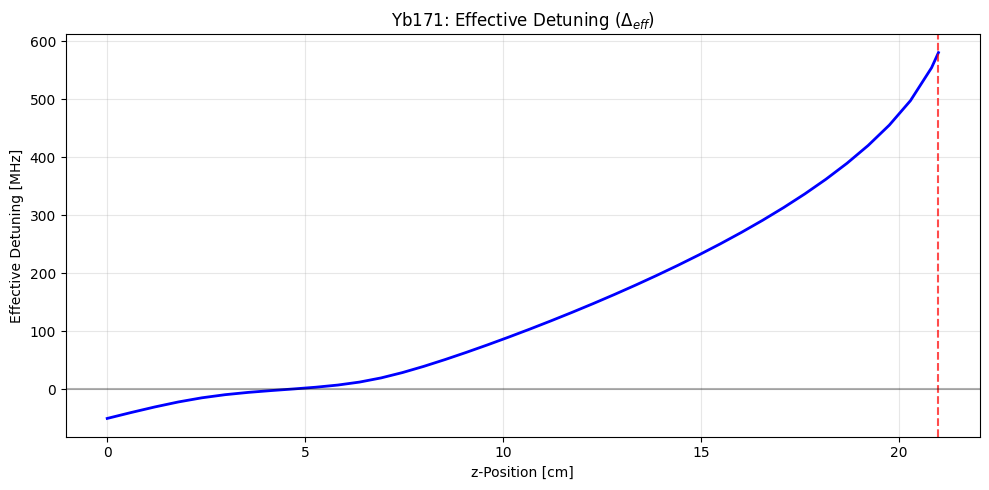

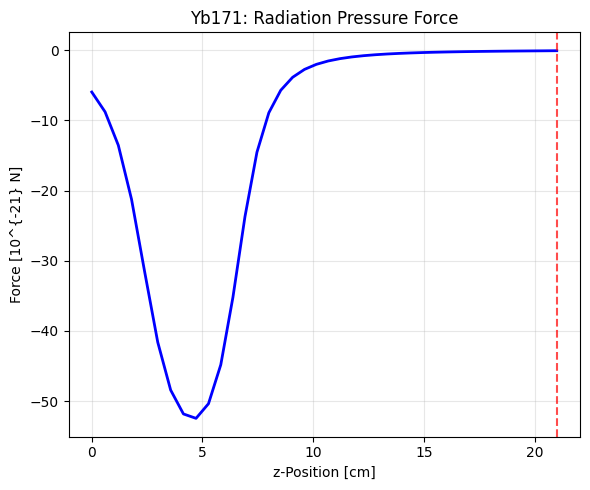

In [6]:
P_L = 25e-3     # laser power [W]
wL = 5e-3     # laser waist [m]

v0 = 300      # initial velocity m/s
delta_laser = 2 * np.pi * (-810) * 1e6 # rad/s

print(f"\nRunning simulation...")
t, z, v, rho = slower.simulate_slower(z0, rho0, v0, delta_laser, B_func, P_L, wL, slower_length, t_max=0.02)
print(f"\nSimulation results:")
print(f"Initial velocity: {v0:.1f} m/s")
print(f"Final velocity: {v[-1]:.1f} m/s")
print(f"Velocity reduction: {v0 - v[-1]:.1f} m/s ({((v0 - v[-1])/v0*100):.1f}%)")
print(f"Exit status: {'Exited' if slower.has_exited else 'Time limit'}")
print(f"Saturation range: {slower.s_history.min():.3f} - {slower.s_history.max():.3f}")
print(f"Maximun scattering rate: {slower.scattering_rate_history.max()/1e6:.1f} MHz")
print(f"Maximum saturation: {slower.s_history.max():.3f}")
print(f"Travel distance: {z[-1]*100:.1f} cm")
print(f"Travel time: {t[-1]*1000:.1f} ms")


# Yb171 (single atom) plots

# 1. magnetic field along ZS (changed units)
plt.figure(figsize=(6, 5))
z_plot = np.linspace(0, slower_length, 300)
B_plot = B_func(z_plot)
plt.plot(z_plot * 100, B_plot * 1e3, 'b-', linewidth=2)
plt.axvline(x=slower_length * 100, color='r', linestyle='--', alpha=0.7, label='slower End')
plt.axvline(x=0, color='r', linestyle='--', alpha=0.7, label='slower start')
plt.plot(0, B_func(0)*1000, 'ro', markersize=8, label=f'B(0)={B_func(0)*1000:.1f} mT')
plt.plot(slower_length * 100, B_func(slower_length)*1000, 'ro', markersize=8, label=f'B(L)={B_func(slower_length)*1000:.1f} mT')
plt.xlabel('z-Position [cm]')
plt.ylabel('Magnetic Field [mT]')
plt.title('Yb171: Magnetic Field Profile')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 2. velocity trajectory
plt.figure(figsize=(6, 5))
plt.plot(z * 100, v, 'b-', linewidth=2)
plt.axvline(x=slower_length * 100, color='r', linestyle='--', alpha=0.7)
if slower.has_exited:
  exit_z = slower.exit_position * 100
  exit_v = slower.exit_velocity
  plt.plot(exit_z, exit_v, 'ro', markersize=8, label=f'Exit: v={exit_v:.1f} m/s')
plt.xlabel('z-Position [cm]')
plt.ylabel('Velocity [m/s]')
plt.title('Yb171: Atomic Velocity')
plt.grid(True, alpha=0.3)
if slower.has_exited:
  plt.legend()
plt.tight_layout()
plt.show()


# 5. effective detuning (use simulated z, v directly)
plt.figure(figsize=(10, 5))
B_simulated = B_func(z)
delta_effective = delta_laser + slower.k * v - (slower.mu_eff * B_simulated / slower.hbar)
plt.plot(z * 100, delta_effective / (2 * np.pi * 1e6), 'b-', linewidth=2)
plt.xlabel('z-Position [cm]')
plt.ylabel('Effective Detuning [MHz]')
plt.title('Yb171: Effective Detuning ($\\Delta_{eff}$)')
plt.axvline(x=slower_length * 100, color='r', linestyle='--', alpha=0.7, label='slower End')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 6. Force/acceleration (use scattering-force formula with simulated v, z)
plt.figure(figsize=(6, 5))
s_traj = slower.saturation_param(z, rho, P_L, wL)
force_from_formula, _, _ = slower.scattering_force(v, z, delta_laser, B_func, s_traj)
finite_mask = np.isfinite(z) & np.isfinite(force_from_formula)
plt.plot(z[finite_mask] * 100, force_from_formula[finite_mask] * 1e21, 'b-', linewidth=2)
plt.axvline(x=slower_length * 100, color='r', linestyle='--', alpha=0.7)
plt.xlabel('z-Position [cm]')
plt.ylabel('Force [10^{-21} N]')
plt.title('Yb171: Radiation Pressure Force')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
z_plot = np.array([0, 20, 40,  60,  80, 100, 120, 140, 160, 180, 200, 210]) * 1e-3
B_plot = B_func(z_plot)
print(z_plot)
print(B_plot)

[0.   0.02 0.04 0.06 0.08 0.1  0.12 0.14 0.16 0.18 0.2  0.21]
[0.00055686 0.00332014 0.00623108 0.00931621 0.01261114 0.01616557
 0.0200526  0.02438784 0.02937513 0.03544533 0.04394926 0.05160375]


### transversal B field

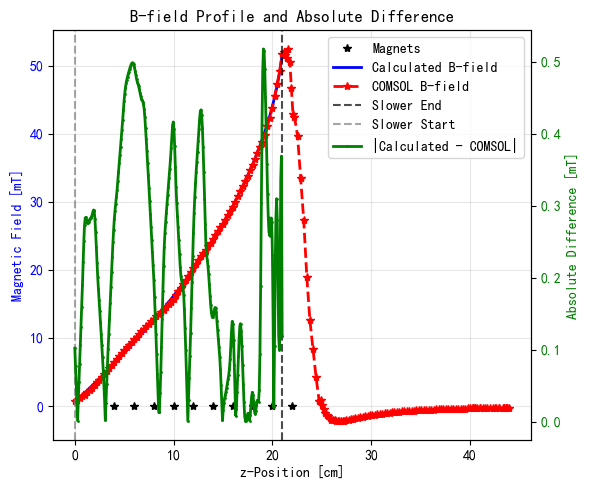

In [7]:
comsol_B_field = pd.read_csv(
    "optimized_Bfield_0408.csv",
    comment="%",
    header=None,
    names=["s_mm", "Bx"],
)

# 原始数据列：z [mm], Bx [mT]
z_comsol_mm = comsol_B_field["s_mm"].to_numpy()
Bx_comsol_mT = comsol_B_field["Bx"].to_numpy()

# 转成与 new_B_func 一致的单位：z [m], B [T]
z_comsol_m = z_comsol_mm * 1e-3
Bx_comsol_T = Bx_comsol_mT * 1e-3

# 排序并去重，保证插值函数输入 x 严格单调
sort_idx = np.argsort(z_comsol_m)
z_sorted = z_comsol_m[sort_idx]
Bx_sorted = Bx_comsol_T[sort_idx]
z_unique, unique_idx = np.unique(z_sorted, return_index=True)
Bx_unique = Bx_sorted[unique_idx]

# COMSOL Bx 插值函数：输入 z [m]，输出 Bx [T]
Bx_comsol_func = interp1d(
    z_unique,
    Bx_unique,
    kind="cubic",
    bounds_error=False,
    fill_value="extrapolate",
)

z = np.linspace(0, slower_length, 300)
B_calculated = B_func(z)

z_mag = (np.array([0, 20, 40, 60, 80, 100, 120, 140, 160, 180]) + 40) * 1e-3
Bx_comsol_on_plot = Bx_comsol_func(z)
abs_diff_mT = np.abs(B_calculated - Bx_comsol_on_plot) * 1e3

fig, ax1 = plt.subplots(figsize=(6, 5))

ax1.plot(z_mag * 100, np.zeros_like(z_mag), 'k*', linewidth=2, label='Magnets')
ax1.plot(z * 100, B_calculated * 1e3, 'b-', linewidth=2, label='Calculated B-field')
ax1.plot(z_comsol_m * 100, Bx_comsol_T * 1e3, 'r--*', linewidth=2, label='COMSOL B-field')
ax1.axvline(x=slower_length * 100, color='k', linestyle='--', alpha=0.7, label='Slower End')
ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.7, label='Slower Start')
ax1.set_xlabel('z-Position [cm]')
ax1.set_ylabel('Magnetic Field [mT]', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(z * 100, abs_diff_mT, 'g-o', linewidth=2, markersize=1, label='|Calculated - COMSOL|')
ax2.set_ylabel('Absolute Difference [mT]', color='g')
ax2.tick_params(axis='y', labelcolor='g')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
ax1.set_title('B-field Profile and Absolute Difference')
plt.tight_layout()
plt.show()

### longitudinal B field

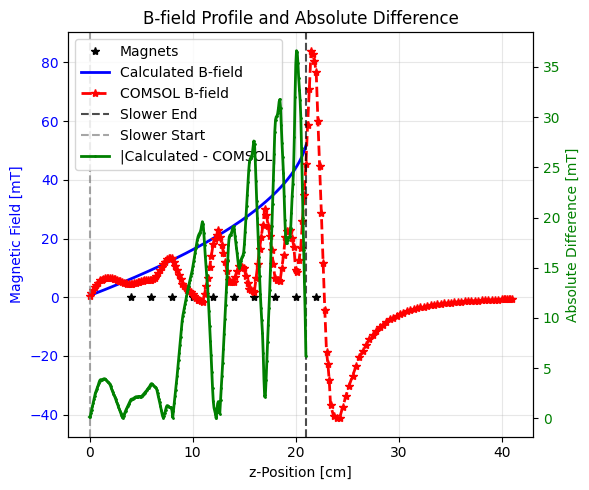

In [8]:
comsol_B_field = pd.read_csv(
    "optimized_Bfield(longitudinal)_0415.csv",
    comment="%",
    header=None,
    names=["s_mm", "Bx"],
)

# 原始数据列：z [mm], Bx [mT]
z_comsol_mm = comsol_B_field["s_mm"].to_numpy()
Bx_comsol_mT = comsol_B_field["Bx"].to_numpy()

# 转成与 new_B_func 一致的单位：z [m], B [T]
z_comsol_m = z_comsol_mm * 1e-3
Bx_comsol_T = Bx_comsol_mT * 1e-3

# 排序并去重，保证插值函数输入 x 严格单调
sort_idx = np.argsort(z_comsol_m)
z_sorted = z_comsol_m[sort_idx]
Bx_sorted = Bx_comsol_T[sort_idx]
z_unique, unique_idx = np.unique(z_sorted, return_index=True)
Bx_unique = Bx_sorted[unique_idx]

# COMSOL Bx 插值函数：输入 z [m]，输出 Bx [T]
Bx_comsol_func = interp1d(
    z_unique,
    Bx_unique,
    kind="cubic",
    bounds_error=False,
    fill_value="extrapolate",
)

z = np.linspace(0, slower_length, 300)
B_calculated = B_func(z)

z_mag = (np.array([0, 20, 40, 60, 80, 100, 120, 140, 160, 180]) + 40) * 1e-3
Bx_comsol_on_plot = Bx_comsol_func(z)
abs_diff_mT = np.abs(B_calculated - Bx_comsol_on_plot) * 1e3

fig, ax1 = plt.subplots(figsize=(6, 5))

ax1.plot(z_mag * 100, np.zeros_like(z_mag), 'k*', linewidth=2, label='Magnets')
ax1.plot(z * 100, B_calculated * 1e3, 'b-', linewidth=2, label='Calculated B-field')
ax1.plot(z_comsol_m * 100, Bx_comsol_T * 1e3, 'r--*', linewidth=2, label='COMSOL B-field')
ax1.axvline(x=slower_length * 100, color='k', linestyle='--', alpha=0.7, label='Slower End')
ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.7, label='Slower Start')
ax1.set_xlabel('z-Position [cm]')
ax1.set_ylabel('Magnetic Field [mT]', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(z * 100, abs_diff_mT, 'g-o', linewidth=2, markersize=1, label='|Calculated - COMSOL|')
ax2.set_ylabel('Absolute Difference [mT]', color='g')
ax2.tick_params(axis='y', labelcolor='g')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
ax1.set_title('B-field Profile and Absolute Difference')
plt.tight_layout()
plt.show()

### set atoms

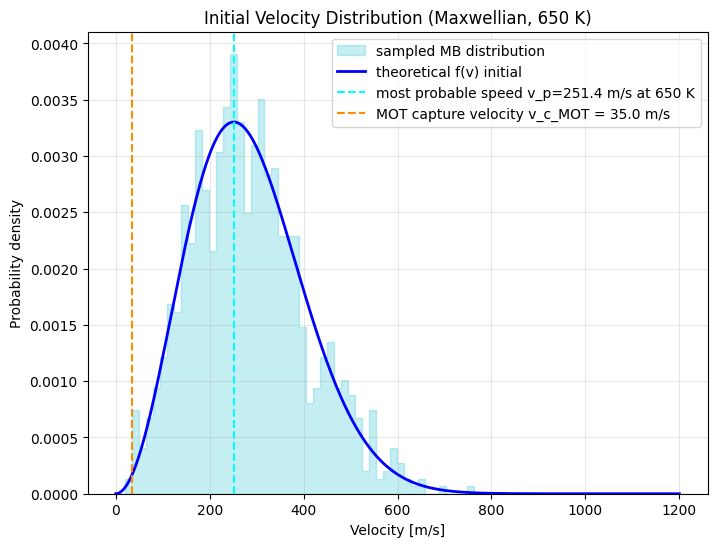

In [9]:
# 覆盖参数 parameters for 5000
n_samples = 1000
celcius = 400
T = 650
k_B = 1.380649e-23
v_p = np.sqrt(2*k_B*T/m_171)
v_c_MOT = 35

# for initial f(v) distribution
def maxwell_pdf(v, T, m):
    v_p = np.sqrt(2 * k_B * T / m)
    return (4/np.sqrt(np.pi)) * (v**2 / v_p**3) * np.exp(-(v**2)/(v_p**2))

# random sampling for initial velocity
def sample_maxwell(T, m, n_samples):
    sigma = np.sqrt(k_B*T/m)
    vx = np.random.normal(0, sigma, n_samples)
    vy = np.random.normal(0, sigma, n_samples)
    vz = np.random.normal(0, sigma, n_samples)
    return np.sqrt(vx**2 + vy**2 + vz**2)

# generate initial velocities and theoretical PDF
initial_velocities = sample_maxwell(T, m_171, n_samples)
v_range = np.linspace(0, 1200, 1000)
f_v_initial = maxwell_pdf(v_range, T, m_171)

# plot initial velocity distribution and theoretical f(v) PDF
plt.figure(figsize=(8, 6))
plt.hist(initial_velocities, bins=50,density=True,histtype="stepfilled",color="tab:cyan", alpha=0.25,edgecolor="tab:cyan", linewidth=1, label="sampled MB distribution")
plt.plot(v_range, f_v_initial, 'b-', linewidth=2, label="theoretical f(v) initial")
plt.axvline(v_p, color='cyan', linestyle='--', label=f"most probable speed v_p={v_p:.1f} m/s at {T} K")
plt.axvline(v_c_MOT, color='darkorange', linestyle='--', label=f"MOT capture velocity v_c_MOT = {v_c_MOT:.1f} m/s")
plt.xlabel("Velocity [m/s]")
plt.ylabel("Probability density")
plt.title(f"Initial Velocity Distribution (Maxwellian, {T} K)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [11]:
# number density: generate radial positions for Gaussian atomic beam

w_a = 2e-3   # atomic beam waist 2mm / diameter 4mm

def gaussian_atomic_beam(n_samples, w_a, beam_length):
    """
    w_a : float, waist length of atomic beam[m]
    beam_length : float, length of beam in z-direction [m]
    """
    u = np.random.uniform(0, 1, n_samples) # generate radial positions using inverse transform sampling
    rho = w_a * np.sqrt(-0.5 * np.log(1 - u))
    z = np.random.uniform(0, beam_length, n_samples) # generate z uniformly along beam length

    return np.column_stack([z, rho])

print(f"for the Yb atomic beam - ")
print(f"  Most probable speed: v_p = {v_p:.2f} m/s")
print(f"  RMS velocity: v_rms = {np.sqrt(np.mean(initial_velocities**2)):.2f} m/s")
print(f"  Mean velocity: {np.mean(initial_velocities):.2f} m/s")
print(f"  Standard deviation: {np.std(initial_velocities):.2f} m/s")
print(f"  Atom Beam waist: w_a = {w_a*1000:.1f} mm \n")

# random sampling of initial radial positions
positions = gaussian_atomic_beam(n_samples, w_a, slower_length) # [z, rho]
rho_0_array = positions[:, -1] # initial radial position

for the Yb atomic beam - 
  Most probable speed: v_p = 251.41 m/s
  RMS velocity: v_rms = 308.53 m/s
  Mean velocity: 283.03 m/s
  Standard deviation: 122.81 m/s
  Atom Beam waist: w_a = 2.0 mm 



### ideal B field slowing performance

810MHz theory

In [28]:
# scan multiple laser powers and store each result set
P_L_list = [0, 10e-3, 20e-3, 30e-3]  # [W], edit this list as needed

# containers for all powers
all_final_velocities = []
all_exit_positions = []
all_exit_times = []
all_successful_slowing = []
results_by_power = []

# create ZS instance
slower = ZeemanSlower(Gamma_399, k_399, m_171, mu_eff_Yb, lmd_399)
t_max = 0.02    # maximum simulation time in seconds
n_points = 1000 # number of time points for ODE integration

# use most probable speed and MOT capture velocity to generate a fixed, ideal B-field


delta_laser = -770 * 1e6 * 2 * np.pi
wL = 2.5e-3
slower_length = 0.21


I_sat_399 = 60 # mW/cm^2
I_list = np.array(P_L_list)* 1e3 / (pi * (wL * 1e2)**2)  # convert to mW/cm^2
s_list = I_list / I_sat_399
print("Laser power (mW) and corresponding saturation parameter s (average):")
for P_L, s in zip(P_L_list, s_list):
    print(f"  P_L = {P_L*1e3:.2f} mW -> s = {s:.2f}")

for P_L in P_L_list:
    # initialize storage for this power
    final_velocities = np.zeros(n_samples)
    exit_positions = np.zeros(n_samples)
    exit_times = np.zeros(n_samples)
    successful_slowing = np.zeros(n_samples, dtype=bool)

    for i in range(n_samples):
        # get initial conditions for this atom
        z0 = 0.0
        rho0 = rho_0_array[i]      # initial radial position
        v0 = initial_velocities[i] # initial velocity

        try:
            # run simulation for this atom
            t, z, v, rho = slower.simulate_slower(
                z0=z0, rho0=rho0, v0=v0,
                delta_laser=delta_laser,
                B_func=B_func,
                P_L=P_L, wL=wL,
                slower_length=slower_length,
                t_max=t_max, n_points=n_points)

            # store results if simulation successful
            final_velocities[i] = v[-1]  # final velocity
            exit_positions[i] = z[-1]    # final position
            exit_times[i] = t[-1]        # final time
            # boolean array to count successfully slowed instances
            successful_slowing[i] = (v[-1] <= v_c_MOT) and (v[-1] > 0)

        except Exception:
            final_velocities[i] = v0  # keep initial velocity if simulation fails
            exit_positions[i] = 0.0
            exit_times[i] = 0.0
            successful_slowing[i] = False

    # store arrays for this power
    all_final_velocities.append(final_velocities.copy())
    all_exit_positions.append(exit_positions.copy())
    all_exit_times.append(exit_times.copy())
    all_successful_slowing.append(successful_slowing.copy())

    # store summary for this power
    summary = {
        "P_L": P_L,
        "n_success": int(np.sum(successful_slowing)),
        "success_ratio": float(np.mean(successful_slowing)),
        "mean_final_v": float(np.mean(final_velocities)),
        "std_final_v": float(np.std(final_velocities)),
        "min_final_v": float(np.min(final_velocities)),
        "max_final_v": float(np.max(final_velocities)),
    }
    results_by_power.append(summary)

    print(f"=== Simulation Results (P_L = {P_L*1e3:.2f} mW) ===")
    print(f"Total atoms simulated: {n_samples}")
    print(f"Successfully slowed (can be captured by MOT): {summary['n_success']} ({summary['success_ratio']*100:.1f}%)")
    print("Final velocity statistics:")
    print(f"  Mean: {summary['mean_final_v']:.2f} m/s")
    print(f"  Std: {summary['std_final_v']:.2f} m/s")
    print(f"  Min: {summary['min_final_v']:.2f} m/s")
    print(f"  Max: {summary['max_final_v']:.2f} m/s")
    print("")

# keep compatibility with downstream cells: default to the last P_L result
final_velocities = all_final_velocities[-1]
exit_positions = all_exit_positions[-1]
exit_times = all_exit_times[-1]
successful_slowing = all_successful_slowing[-1]

Laser power (mW) and corresponding saturation parameter s (average):
  P_L = 0.00 mW -> s = 0.00
  P_L = 10.00 mW -> s = 0.85
  P_L = 20.00 mW -> s = 1.70
  P_L = 30.00 mW -> s = 2.55
=== Simulation Results (P_L = 0.00 mW) ===
Total atoms simulated: 1000
Successfully slowed (can be captured by MOT): 3 (0.3%)
Final velocity statistics:
  Mean: 283.03 m/s
  Std: 122.81 m/s
  Min: 19.97 m/s
  Max: 761.92 m/s

=== Simulation Results (P_L = 10.00 mW) ===
Total atoms simulated: 1000
Successfully slowed (can be captured by MOT): 596 (59.6%)
Final velocity statistics:
  Mean: 166.78 m/s
  Std: 199.46 m/s
  Min: 0.00 m/s
  Max: 761.91 m/s

=== Simulation Results (P_L = 20.00 mW) ===
Total atoms simulated: 1000
Successfully slowed (can be captured by MOT): 0 (0.0%)
Final velocity statistics:
  Mean: 155.28 m/s
  Std: 203.83 m/s
  Min: 0.00 m/s
  Max: 761.89 m/s

=== Simulation Results (P_L = 30.00 mW) ===
Total atoms simulated: 1000
Successfully slowed (can be captured by MOT): 0 (0.0%)
Final ve

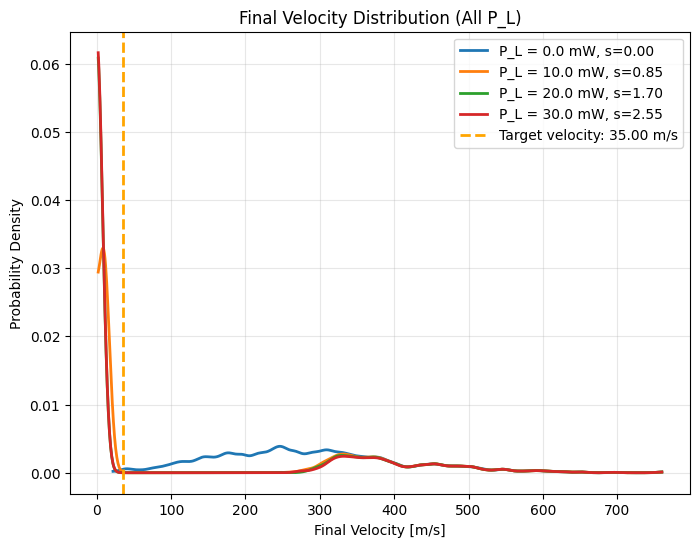

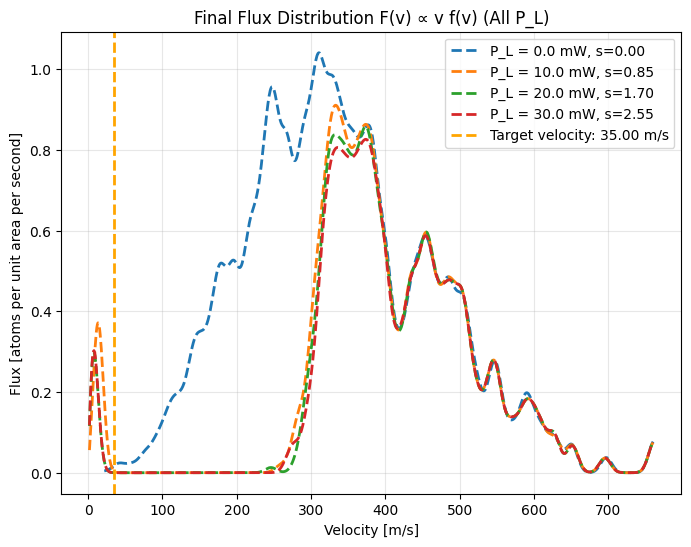

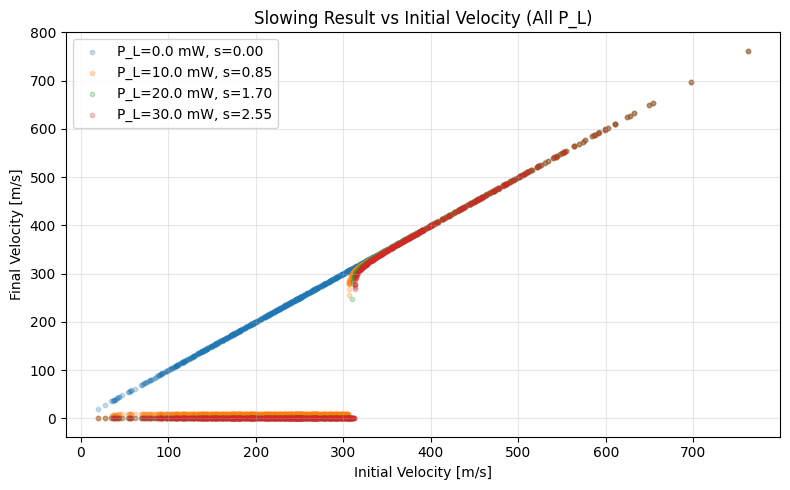

In [29]:
# plot all P_L results together with labels

# build smooth interpolations for each P_L
f_v_final_list = []
v_range_final_list = []
flux_final_list = []

for final_v in all_final_velocities:
    counts, edges = np.histogram(final_v, bins=200, density=True)
    centers = (edges[:-1] + edges[1:]) / 2
    counts_smooth = gaussian_filter1d(counts, sigma=2)
    f_v_final_i = interp1d(centers, counts_smooth, kind='cubic', bounds_error=False, fill_value=0)
    v_range_final_i = np.linspace(centers.min(), centers.max(), 1000)
    flux_final_i = np.where(v_range_final_i > 0, f_v_final_i(v_range_final_i) * v_range_final_i, 0.0)

    f_v_final_list.append(f_v_final_i)
    v_range_final_list.append(v_range_final_i)
    flux_final_list.append(flux_final_i)

# INITIAL velocity distribution (shared reference)
counts, edges = np.histogram(initial_velocities, bins=200, density=True)
centers = (edges[:-1] + edges[1:]) / 2
counts_smooth = gaussian_filter1d(counts, sigma=2)
f_v_initial = interp1d(centers, counts_smooth, kind='cubic', bounds_error=False, fill_value=0)
v_range_initial = np.linspace(centers.min(), centers.max(), 1000)
flux_initial = np.where(v_range_initial > 0, f_v_initial(v_range_initial) * v_range_initial, 0.0)

# keep compatibility with downstream cells
f_v_final = f_v_final_list[-1]
v_range_final = v_range_final_list[-1]

# 1) FINAL velocity distribution for all P_L
plt.figure(figsize=(8, 6))
for i, P_L in enumerate(P_L_list):
    label = f'P_L = {P_L*1e3:.1f} mW, s={s_list[i]:.2f}'
    plt.plot(v_range_final_list[i], f_v_final_list[i](v_range_final_list[i]), linewidth=2, label=label)
plt.axvline(v_c_MOT, color='orange', linestyle='--', linewidth=2, label=f'Target velocity: {v_c_MOT:.2f} m/s')
plt.xlabel('Final Velocity [m/s]')
plt.ylabel('Probability Density')
plt.title('Final Velocity Distribution (All P_L)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2) final flux distribution for all P_L
plt.figure(figsize=(8, 6))
for i, P_L in enumerate(P_L_list):
    label = f'P_L = {P_L*1e3:.1f} mW, s={s_list[i]:.2f}'
    mask = v_range_final_list[i] > 0
    plt.plot(v_range_final_list[i][mask], flux_final_list[i][mask], '--', linewidth=2, label=label)
plt.axvline(v_c_MOT, color='orange', linestyle='--', linewidth=2, label=f'Target velocity: {v_c_MOT:.2f} m/s')
plt.xlabel('Velocity [m/s]')
plt.ylabel('Flux [atoms per unit area per second]')
plt.title('Final Flux Distribution F(v) ∝ v f(v) (All P_L)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


plt.figure(figsize=(8, 5))
for i, P_L in enumerate(P_L_list):
    label = f'P_L={P_L*1e3:.1f} mW, s={s_list[i]:.2f}'
    plt.scatter(initial_velocities, all_final_velocities[i], alpha=0.25, s=10, label=label)
plt.xlabel('Initial Velocity [m/s]')
plt.ylabel('Final Velocity [m/s]')
plt.title('Slowing Result vs Initial Velocity (All P_L)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

710MHz exp


In [33]:
# scan multiple laser powers and store each result set
P_L_list = [0, 10e-3, 20e-3, 30e-3]  # [W], edit this list as needed

# containers for all powers
all_final_velocities = []
all_exit_positions = []
all_exit_times = []
all_successful_slowing = []
results_by_power = []

# create ZS instance
slower = ZeemanSlower(Gamma_399, k_399, m_171, mu_eff_Yb, lmd_399)
t_max = 0.02    # maximum simulation time in seconds
n_points = 1000 # number of time points for ODE integration

# use most probable speed and MOT capture velocity to generate a fixed, ideal B-field


delta_laser = -710 * 1e6 * 2 * np.pi
wL = 3e-3
slower_length = 0.21


I_sat_399 = 60 # mW/cm^2
I_list = np.array(P_L_list)* 1e3 / (pi * (wL * 1e2)**2)  # convert to mW/cm^2
s_list = I_list / I_sat_399
print("Laser power (mW) and corresponding saturation parameter s (average):")
for P_L, s in zip(P_L_list, s_list):
    print(f"  P_L = {P_L*1e3:.2f} mW -> s = {s:.2f}")

for P_L in P_L_list:
    # initialize storage for this power
    final_velocities = np.zeros(n_samples)
    exit_positions = np.zeros(n_samples)
    exit_times = np.zeros(n_samples)
    successful_slowing = np.zeros(n_samples, dtype=bool)

    for i in range(n_samples):
        # get initial conditions for this atom
        z0 = 0.0
        rho0 = rho_0_array[i]      # initial radial position
        v0 = initial_velocities[i] # initial velocity

        try:
            # run simulation for this atom
            t, z, v, rho = slower.simulate_slower(
                z0=z0, rho0=rho0, v0=v0,
                delta_laser=delta_laser,
                B_func=B_func,
                P_L=P_L, wL=wL,
                slower_length=slower_length,
                t_max=t_max, n_points=n_points)

            # store results if simulation successful
            final_velocities[i] = v[-1]  # final velocity
            exit_positions[i] = z[-1]    # final position
            exit_times[i] = t[-1]        # final time
            # boolean array to count successfully slowed instances
            successful_slowing[i] = (v[-1] <= v_c_MOT) and (v[-1] > 0)

        except Exception:
            final_velocities[i] = v0  # keep initial velocity if simulation fails
            exit_positions[i] = 0.0
            exit_times[i] = 0.0
            successful_slowing[i] = False

    # store arrays for this power
    all_final_velocities.append(final_velocities.copy())
    all_exit_positions.append(exit_positions.copy())
    all_exit_times.append(exit_times.copy())
    all_successful_slowing.append(successful_slowing.copy())

    # store summary for this power
    summary = {
        "P_L": P_L,
        "n_success": int(np.sum(successful_slowing)),
        "success_ratio": float(np.mean(successful_slowing)),
        "mean_final_v": float(np.mean(final_velocities)),
        "std_final_v": float(np.std(final_velocities)),
        "min_final_v": float(np.min(final_velocities)),
        "max_final_v": float(np.max(final_velocities)),
    }
    results_by_power.append(summary)

    print(f"=== Simulation Results (P_L = {P_L*1e3:.2f} mW) ===")
    print(f"Total atoms simulated: {n_samples}")
    print(f"Successfully slowed (can be captured by MOT): {summary['n_success']} ({summary['success_ratio']*100:.1f}%)")
    print("Final velocity statistics:")
    print(f"  Mean: {summary['mean_final_v']:.2f} m/s")
    print(f"  Std: {summary['std_final_v']:.2f} m/s")
    print(f"  Min: {summary['min_final_v']:.2f} m/s")
    print(f"  Max: {summary['max_final_v']:.2f} m/s")
    print("")

# keep compatibility with downstream cells: default to the last P_L result
final_velocities = all_final_velocities[-1]
exit_positions = all_exit_positions[-1]
exit_times = all_exit_times[-1]
successful_slowing = all_successful_slowing[-1]

Laser power (mW) and corresponding saturation parameter s (average):
  P_L = 0.00 mW -> s = 0.00
  P_L = 10.00 mW -> s = 0.59
  P_L = 20.00 mW -> s = 1.18
  P_L = 30.00 mW -> s = 1.77


=== Simulation Results (P_L = 0.00 mW) ===
Total atoms simulated: 1000
Successfully slowed (can be captured by MOT): 4 (0.4%)
Final velocity statistics:
  Mean: 284.03 m/s
  Std: 120.54 m/s
  Min: 12.57 m/s
  Max: 753.54 m/s

=== Simulation Results (P_L = 10.00 mW) ===
Total atoms simulated: 1000
Successfully slowed (can be captured by MOT): 1 (0.1%)
Final velocity statistics:
  Mean: 183.58 m/s
  Std: 200.29 m/s
  Min: 0.00 m/s
  Max: 753.53 m/s

=== Simulation Results (P_L = 20.00 mW) ===
Total atoms simulated: 1000
Successfully slowed (can be captured by MOT): 0 (0.0%)
Final velocity statistics:
  Mean: 174.27 m/s
  Std: 202.74 m/s
  Min: 0.00 m/s
  Max: 753.52 m/s

=== Simulation Results (P_L = 30.00 mW) ===
Total atoms simulated: 1000
Successfully slowed (can be captured by MOT): 0 (0.0%)
Final velocity statistics:
  Mean: 170.29 m/s
  Std: 203.29 m/s
  Min: 0.00 m/s
  Max: 753.51 m/s



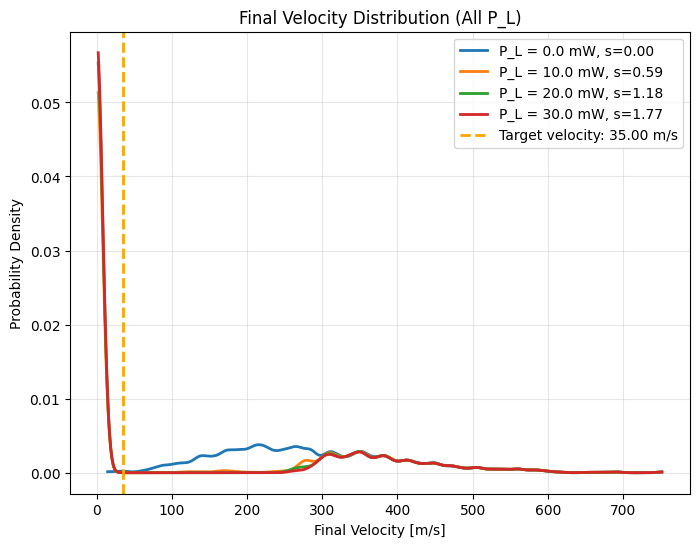

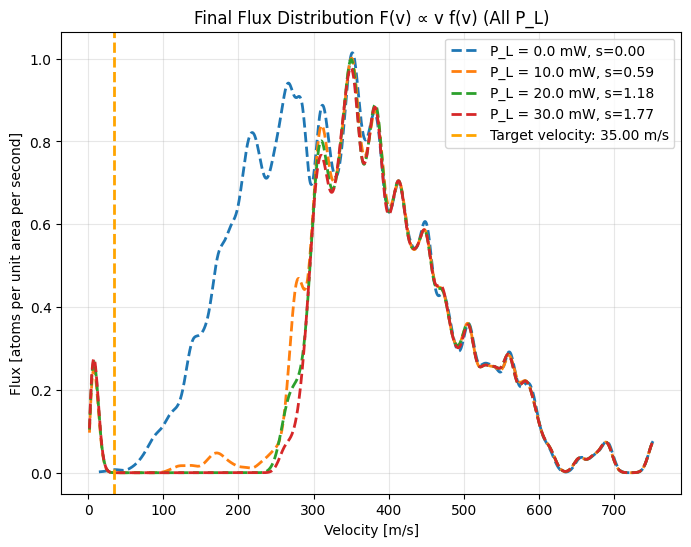

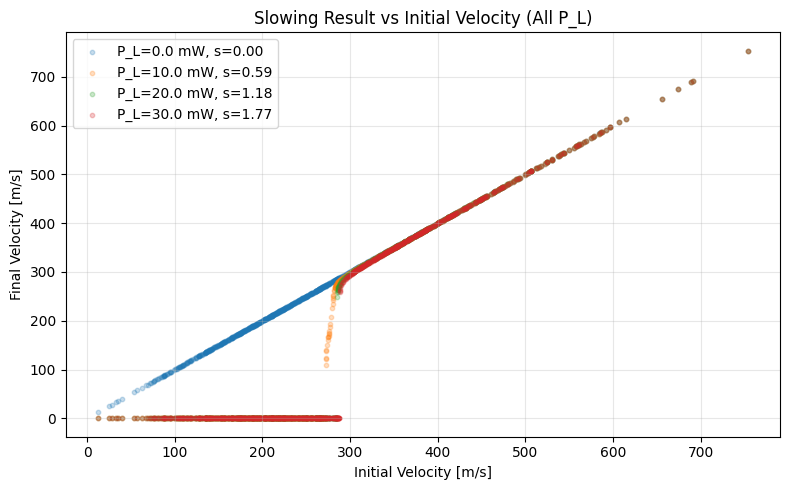

In [34]:
# plot all P_L results together with labels

# build smooth interpolations for each P_L
f_v_final_list = []
v_range_final_list = []
flux_final_list = []

for final_v in all_final_velocities:
    counts, edges = np.histogram(final_v, bins=200, density=True)
    centers = (edges[:-1] + edges[1:]) / 2
    counts_smooth = gaussian_filter1d(counts, sigma=2)
    f_v_final_i = interp1d(centers, counts_smooth, kind='cubic', bounds_error=False, fill_value=0)
    v_range_final_i = np.linspace(centers.min(), centers.max(), 1000)
    flux_final_i = np.where(v_range_final_i > 0, f_v_final_i(v_range_final_i) * v_range_final_i, 0.0)

    f_v_final_list.append(f_v_final_i)
    v_range_final_list.append(v_range_final_i)
    flux_final_list.append(flux_final_i)

# INITIAL velocity distribution (shared reference)
counts, edges = np.histogram(initial_velocities, bins=200, density=True)
centers = (edges[:-1] + edges[1:]) / 2
counts_smooth = gaussian_filter1d(counts, sigma=2)
f_v_initial = interp1d(centers, counts_smooth, kind='cubic', bounds_error=False, fill_value=0)
v_range_initial = np.linspace(centers.min(), centers.max(), 1000)
flux_initial = np.where(v_range_initial > 0, f_v_initial(v_range_initial) * v_range_initial, 0.0)

# keep compatibility with downstream cells
f_v_final = f_v_final_list[-1]
v_range_final = v_range_final_list[-1]

# 1) FINAL velocity distribution for all P_L
plt.figure(figsize=(8, 6))
for i, P_L in enumerate(P_L_list):
    label = f'P_L = {P_L*1e3:.1f} mW, s={s_list[i]:.2f}'
    plt.plot(v_range_final_list[i], f_v_final_list[i](v_range_final_list[i]), linewidth=2, label=label)
plt.axvline(v_c_MOT, color='orange', linestyle='--', linewidth=2, label=f'Target velocity: {v_c_MOT:.2f} m/s')
plt.xlabel('Final Velocity [m/s]')
plt.ylabel('Probability Density')
plt.title('Final Velocity Distribution (All P_L)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2) final flux distribution for all P_L
plt.figure(figsize=(8, 6))
for i, P_L in enumerate(P_L_list):
    label = f'P_L = {P_L*1e3:.1f} mW, s={s_list[i]:.2f}'
    mask = v_range_final_list[i] > 0
    plt.plot(v_range_final_list[i][mask], flux_final_list[i][mask], '--', linewidth=2, label=label)
plt.axvline(v_c_MOT, color='orange', linestyle='--', linewidth=2, label=f'Target velocity: {v_c_MOT:.2f} m/s')
plt.xlabel('Velocity [m/s]')
plt.ylabel('Flux [atoms per unit area per second]')
plt.title('Final Flux Distribution F(v) ∝ v f(v) (All P_L)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


plt.figure(figsize=(8, 5))
for i, P_L in enumerate(P_L_list):
    label = f'P_L={P_L*1e3:.1f} mW, s={s_list[i]:.2f}'
    plt.scatter(initial_velocities, all_final_velocities[i], alpha=0.25, s=10, label=label)
plt.xlabel('Initial Velocity [m/s]')
plt.ylabel('Final Velocity [m/s]')
plt.title('Slowing Result vs Initial Velocity (All P_L)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### COMSOL B field slowing performance

In [24]:
# COMSOL Bx 函数：输入 z [m]，输出 Bx [T]（与 new_B_func 接口一致）
z_min, z_max = float(z_unique.min()), float(z_unique.max())
B_min, B_max = float(Bx_unique[0]), float(Bx_unique[-1])

def Bx_comsol_func(z):
    z_arr = np.asarray(z, dtype=float)
    z_clip = np.clip(z_arr, z_min, z_max)
    # 线性插值比 cubic 更稳定且更快，适合被 ODE 频繁调用
    B = np.interp(z_clip, z_unique, Bx_unique, left=B_min, right=B_max)
    return float(B) if np.isscalar(z) else B

NameError: name 'z_unique' is not defined

#### single atom check

Testing B-field function:
B at z=0: 0.7 mT
B at end: 51.7 mT

Running simulation...

Simulation results:
Initial velocity: 300.0 m/s
Final velocity: 31.7 m/s
Velocity reduction: 268.3 m/s (89.4%)
Exit status: Exited
Saturation range: 0.963 - 0.963
Maximun scattering rate: 44.5 MHz
Maximum saturation: 0.963
Travel distance: 21.0 cm
Travel time: 1.2 ms


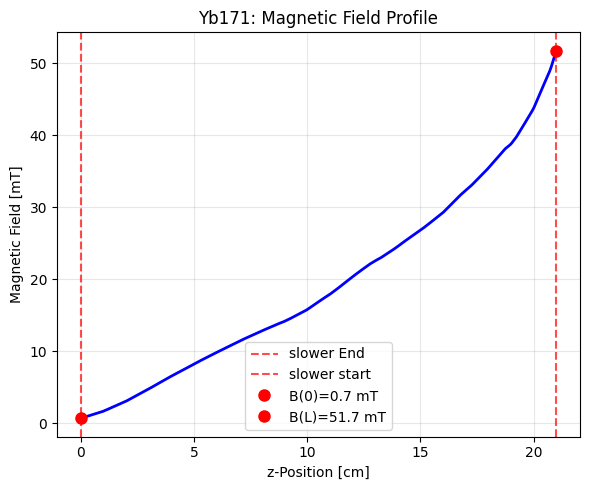

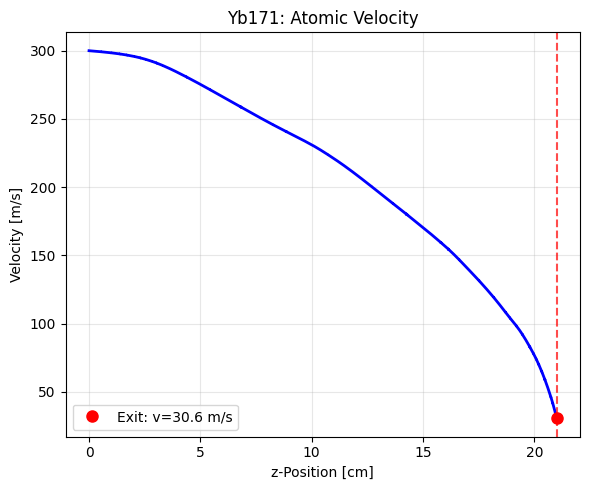

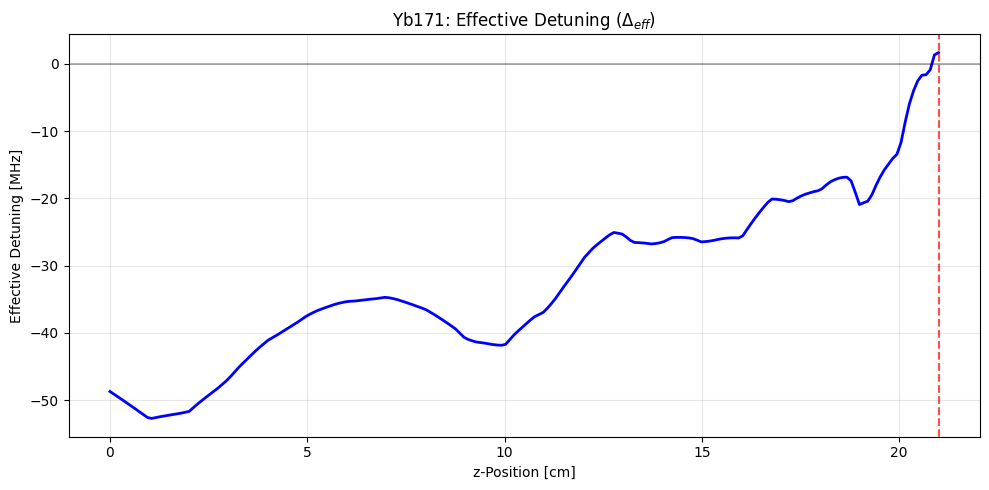

In [179]:
# single atom example

# Yb171 parameters
au = 1.66053906660e-27 # kg
m_171 = 171 * au
Gamma_399 = 2* np.pi *28.9e6  # [rad/s]
lmd_399 = 398.9e-9
k_399 = 2 * np.pi / lmd_399

g_e, g_g = 2/3, 0.0     # correct for 171Yb (1P1 -> 1S0)
M_e, M_g = -3/2, 1/2         # sigma - cycling transition
mu_B = e * hbar / (2 * m_e)
mu_eff_Yb = (g_e * M_e - g_g * M_g) * mu_B  # [J/T]

# create slower instance
slower = ZeemanSlower(Gamma_399, k_399, m_171, mu_eff_Yb, lmd_399)

z0 = 0.0
rho0 = 0.000    # 1mm radial offset
v0 = 300      # initial velocity m/s
delta_laser = 2 * np.pi * (-810) * 1e6 # rad/s
P_L = 45e-3     # laser power [W]
wL = 5e-3     # laser waist [m]
slower_length = 0.21  # m
v_final = 35.0  # m/s

B_func = Bx_comsol_func

print("Testing B-field function:")
print(f"B at z=0: {B_func(0)*1000:.1f} mT")
print(f"B at end: {B_func(slower_length)*1000:.1f} mT")

print(f"\nRunning simulation...")
t, z, v, rho = slower.simulate_slower(z0, rho0, v0, delta_laser, B_func, P_L, wL, slower_length, t_max=0.02)
print(f"\nSimulation results:")
print(f"Initial velocity: {v0:.1f} m/s")
print(f"Final velocity: {v[-1]:.1f} m/s")
print(f"Velocity reduction: {v0 - v[-1]:.1f} m/s ({((v0 - v[-1])/v0*100):.1f}%)")
print(f"Exit status: {'Exited' if slower.has_exited else 'Time limit'}")
print(f"Saturation range: {slower.s_history.min():.3f} - {slower.s_history.max():.3f}")
print(f"Maximun scattering rate: {slower.scattering_rate_history.max()/1e6:.1f} MHz")
print(f"Maximum saturation: {slower.s_history.max():.3f}")
print(f"Travel distance: {z[-1]*100:.1f} cm")
print(f"Travel time: {t[-1]*1000:.1f} ms")


# Yb171 (single atom) plots

# 1. magnetic field along ZS (changed units)
plt.figure(figsize=(6, 5))
z_plot = np.linspace(0, slower_length, 300)
B_plot = B_func(z_plot)
plt.plot(z_plot * 100, B_plot * 1e3, 'b-', linewidth=2)
plt.axvline(x=slower_length * 100, color='r', linestyle='--', alpha=0.7, label='slower End')
plt.axvline(x=0, color='r', linestyle='--', alpha=0.7, label='slower start')
plt.plot(0, B_func(0)*1000, 'ro', markersize=8, label=f'B(0)={B_func(0)*1000:.1f} mT')
plt.plot(slower_length * 100, B_func(slower_length)*1000, 'ro', markersize=8, label=f'B(L)={B_func(slower_length)*1000:.1f} mT')
plt.xlabel('z-Position [cm]')
plt.ylabel('Magnetic Field [mT]')
plt.title('Yb171: Magnetic Field Profile')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 2. velocity trajectory
plt.figure(figsize=(6, 5))
plt.plot(z * 100, v, 'b-', linewidth=2)
plt.axvline(x=slower_length * 100, color='r', linestyle='--', alpha=0.7)
if slower.has_exited:
  exit_z = slower.exit_position * 100
  exit_v = slower.exit_velocity
  plt.plot(exit_z, exit_v, 'ro', markersize=8, label=f'Exit: v={exit_v:.1f} m/s')
plt.xlabel('z-Position [cm]')
plt.ylabel('Velocity [m/s]')
plt.title('Yb171: Atomic Velocity')
plt.grid(True, alpha=0.3)
if slower.has_exited:
  plt.legend()
plt.tight_layout()
plt.show()




# 5. effective detuning
plt.figure(figsize=(10, 5))
z_detailed = np.linspace(0, slower_length, 200)
B_detailed = B_func(z_detailed)
# calculate required B-field for resonance (const deceleration)
v_resonance = np.sqrt(v0**2 + (v_final**2 - v0**2) * z_detailed / slower_length)
delta_effective = delta_laser + slower.k * v_resonance - (slower.mu_eff * B_detailed / slower.hbar)
plt.plot(z_detailed * 100, delta_effective / (2 * np.pi * 1e6), 'b-', linewidth=2)
plt.xlabel('z-Position [cm]')
plt.ylabel('Effective Detuning [MHz]')
plt.title('Yb171: Effective Detuning ($\Delta_{eff}$)')
plt.axvline(x=slower_length * 100, color='r', linestyle='--', alpha=0.7, label='slower End')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



#### atoms

In [180]:
# scan multiple laser powers and store each result set
P_L_list = [30e-3, 40e-3, 45e-3, 50e-3, 60e-3]  # [W], edit this list as needed

# containers for all powers
all_final_velocities = []
all_exit_positions = []
all_exit_times = []
all_successful_slowing = []
results_by_power = []

# create ZS instance
slower = ZeemanSlower(Gamma_399, k_399, m_171, mu_eff_Yb, lmd_399)
t_max = 0.02    # maximum simulation time in seconds
n_points = 1000 # number of time points for ODE integration

# use most probable speed and MOT capture velocity to generate a fixed, ideal B-field

delta_laser = -810 * 1e6 * 2 * np.pi
wL = 5e-3
slower_length = 0.21

new_B_func = Bx_comsol_func

I_sat_399 = 60 # mW/cm^2
I_list = np.array(P_L_list)* 1e3 / (pi * (wL * 1e2)**2)  # convert to mW/cm^2
s_list = I_list / I_sat_399
print(f"Laser power (mW) with waist {wL*1e3:.2f} mm and corresponding saturation parameter s (average):")
for P_L, s in zip(P_L_list, s_list):
    print(f"  P_L = {P_L*1e3:.2f} mW -> s = {s:.2f}")

# 先用较小样本验证，确认稳定后再改回 n_samples
n_samples_run = n_samples
print(f"Using n_samples_run = {n_samples_run}")

for P_L in P_L_list:
    # initialize storage for this power
    final_velocities = np.zeros(n_samples_run)
    exit_positions = np.zeros(n_samples_run)
    exit_times = np.zeros(n_samples_run)
    successful_slowing = np.zeros(n_samples_run, dtype=bool)

    for i in range(n_samples_run):
        # get initial conditions for this atom
        z0 = 0.0
        rho0 = rho_0_array[i]      # initial radial position
        v0 = initial_velocities[i] # initial velocity

        try:
            # run simulation for this atom
            t, z, v, rho = slower.simulate_slower(
                z0=z0, rho0=rho0, v0=v0,
                delta_laser=delta_laser,
                B_func=new_B_func,
                P_L=P_L, wL=wL,
                slower_length=slower_length,
                t_max=t_max, n_points=n_points)

            # store results if simulation successful
            final_velocities[i] = v[-1]  # final velocity
            exit_positions[i] = z[-1]    # final position
            exit_times[i] = t[-1]        # final time
            # boolean array to count successfully slowed instances
            successful_slowing[i] = (v[-1] <= v_c_MOT) and (v[-1] > 0)

        except Exception:
            final_velocities[i] = v0  # keep initial velocity if simulation fails
            exit_positions[i] = 0.0
            exit_times[i] = 0.0
            successful_slowing[i] = False

    # store arrays for this power
    all_final_velocities.append(final_velocities.copy())
    all_exit_positions.append(exit_positions.copy())
    all_exit_times.append(exit_times.copy())
    all_successful_slowing.append(successful_slowing.copy())

    # store summary for this power
    summary = {
        "P_L": P_L,
        "n_success": int(np.sum(successful_slowing)),
        "success_ratio": float(np.mean(successful_slowing)),
        "mean_final_v": float(np.mean(final_velocities)),
        "std_final_v": float(np.std(final_velocities)),
        "min_final_v": float(np.min(final_velocities)),
        "max_final_v": float(np.max(final_velocities)),
    }
    results_by_power.append(summary)

    print(f"=== Simulation Results (P_L = {P_L*1e3:.2f} mW) ===")
    print(f"Total atoms simulated: {n_samples_run}")
    print(f"Successfully slowed (can be captured by MOT): {summary['n_success']} ({summary['success_ratio']*100:.1f}%)")
    print("Final velocity statistics:")
    print(f"  Mean: {summary['mean_final_v']:.2f} m/s")
    print(f"  Std: {summary['std_final_v']:.2f} m/s")
    print(f"  Min: {summary['min_final_v']:.2f} m/s")
    print(f"  Max: {summary['max_final_v']:.2f} m/s")
    print("")

# keep compatibility with downstream cells: default to the last P_L result
final_velocities = all_final_velocities[-1]
exit_positions = all_exit_positions[-1]
exit_times = all_exit_times[-1]
successful_slowing = all_successful_slowing[-1]

Laser power (mW) with waist 5.00 mm and corresponding saturation parameter s (average):
  P_L = 30.00 mW -> s = 0.64
  P_L = 40.00 mW -> s = 0.85
  P_L = 45.00 mW -> s = 0.95
  P_L = 50.00 mW -> s = 1.06
  P_L = 60.00 mW -> s = 1.27
Using n_samples_run = 500
=== Simulation Results (P_L = 30.00 mW) ===
Total atoms simulated: 500
Successfully slowed (can be captured by MOT): 10 (2.0%)
Final velocity statistics:
  Mean: 250.52 m/s
  Std: 143.78 m/s
  Min: 9.27 m/s
  Max: 706.04 m/s

=== Simulation Results (P_L = 40.00 mW) ===
Total atoms simulated: 500
Successfully slowed (can be captured by MOT): 41 (8.2%)
Final velocity statistics:
  Mean: 172.38 m/s
  Std: 186.61 m/s
  Min: 3.94 m/s
  Max: 706.04 m/s

=== Simulation Results (P_L = 45.00 mW) ===
Total atoms simulated: 500
Successfully slowed (can be captured by MOT): 330 (66.0%)
Final velocity statistics:
  Mean: 162.57 m/s
  Std: 190.91 m/s
  Min: -13.78 m/s
  Max: 706.03 m/s

=== Simulation Results (P_L = 50.00 mW) ===
Total atoms sim

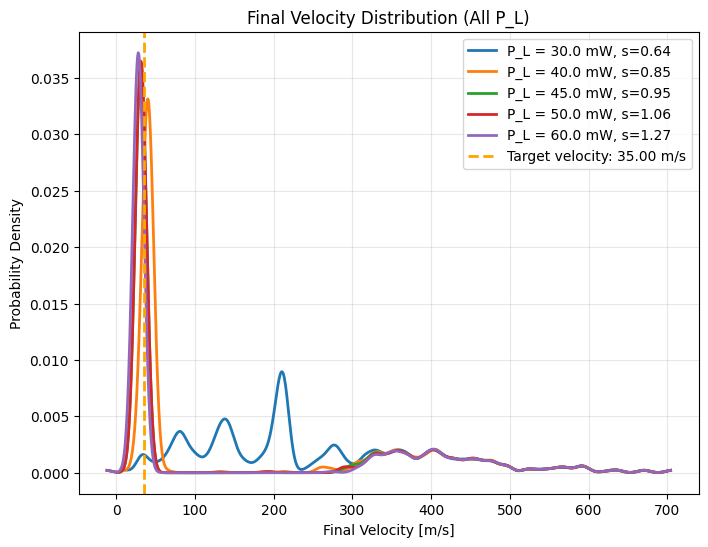

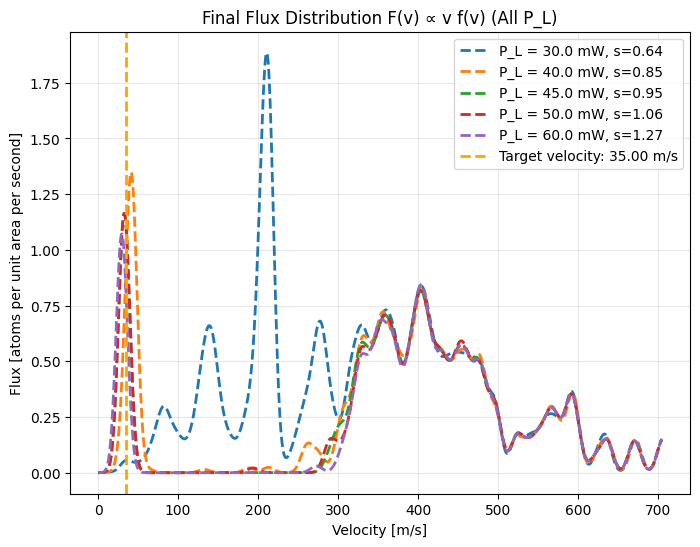

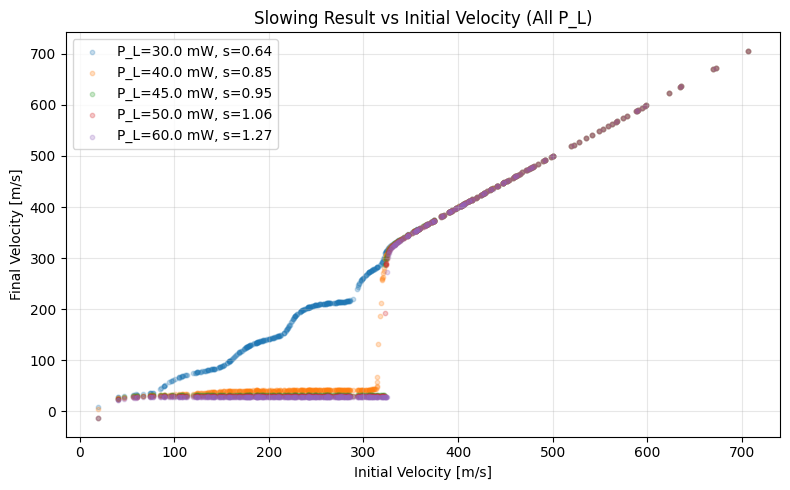

In [181]:
# plot all P_L results together with labels

# build smooth interpolations for each P_L
f_v_final_list = []
v_range_final_list = []
flux_final_list = []

for final_v in all_final_velocities:
    counts, edges = np.histogram(final_v, bins=200, density=True)
    centers = (edges[:-1] + edges[1:]) / 2
    counts_smooth = gaussian_filter1d(counts, sigma=2)
    f_v_final_i = interp1d(centers, counts_smooth, kind='cubic', bounds_error=False, fill_value=0)
    v_range_final_i = np.linspace(centers.min(), centers.max(), 1000)
    flux_final_i = np.where(v_range_final_i > 0, f_v_final_i(v_range_final_i) * v_range_final_i, 0.0)

    f_v_final_list.append(f_v_final_i)
    v_range_final_list.append(v_range_final_i)
    flux_final_list.append(flux_final_i)

# INITIAL velocity distribution (shared reference)
counts, edges = np.histogram(initial_velocities, bins=200, density=True)
centers = (edges[:-1] + edges[1:]) / 2
counts_smooth = gaussian_filter1d(counts, sigma=2)
f_v_initial = interp1d(centers, counts_smooth, kind='cubic', bounds_error=False, fill_value=0)
v_range_initial = np.linspace(centers.min(), centers.max(), 1000)
flux_initial = np.where(v_range_initial > 0, f_v_initial(v_range_initial) * v_range_initial, 0.0)

# keep compatibility with downstream cells
f_v_final = f_v_final_list[-1]
v_range_final = v_range_final_list[-1]

# 1) FINAL velocity distribution for all P_L
plt.figure(figsize=(8, 6))
for i, P_L in enumerate(P_L_list):
    label = f'P_L = {P_L*1e3:.1f} mW, s={s_list[i]:.2f}'
    plt.plot(v_range_final_list[i], f_v_final_list[i](v_range_final_list[i]), linewidth=2, label=label)
plt.axvline(v_c_MOT, color='orange', linestyle='--', linewidth=2, label=f'Target velocity: {v_c_MOT:.2f} m/s')
plt.xlabel('Final Velocity [m/s]')
plt.ylabel('Probability Density')
plt.title('Final Velocity Distribution (All P_L)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2) final flux distribution for all P_L
plt.figure(figsize=(8, 6))
for i, P_L in enumerate(P_L_list):
    label = f'P_L = {P_L*1e3:.1f} mW, s={s_list[i]:.2f}'
    mask = v_range_final_list[i] > 0
    plt.plot(v_range_final_list[i][mask], flux_final_list[i][mask], '--', linewidth=2, label=label)
plt.axvline(v_c_MOT, color='orange', linestyle='--', linewidth=2, label=f'Target velocity: {v_c_MOT:.2f} m/s')
plt.xlabel('Velocity [m/s]')
plt.ylabel('Flux [atoms per unit area per second]')
plt.title('Final Flux Distribution F(v) ∝ v f(v) (All P_L)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


plt.figure(figsize=(8, 5))
for i, P_L in enumerate(P_L_list):
    label = f'P_L={P_L*1e3:.1f} mW, s={s_list[i]:.2f}'
    plt.scatter(initial_velocities, all_final_velocities[i], alpha=0.25, s=10, label=label)
plt.xlabel('Initial Velocity [m/s]')
plt.ylabel('Final Velocity [m/s]')
plt.title('Slowing Result vs Initial Velocity (All P_L)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### measured B-field performance

#### GUI

In [11]:
import tkinter as tk
from tkinter import ttk
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import csv
from tkinter import filedialog
import itertools
import numpy as np

# 设置matplotlib支持中文
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 在这里直接指定背景函数
def background_func(x):
    return B_func(x)/2


class PointPlotter:
    def __init__(self, root):
        self.root = root
        self.root.title("点生成器（含误差棒和目标函数）")

        # 输入区
        self.frame = ttk.Frame(root)
        self.frame.pack(side=tk.TOP, fill=tk.X, padx=10, pady=10)

        ttk.Label(self.frame, text="x:").grid(row=0, column=0)
        self.x_entry = ttk.Entry(self.frame, width=10)
        self.x_entry.grid(row=0, column=1)

        ttk.Label(self.frame, text="y:").grid(row=0, column=2)
        self.y_entry = ttk.Entry(self.frame, width=10)
        self.y_entry.grid(row=0, column=3)

        ttk.Label(self.frame, text="y误差:").grid(row=0, column=4)
        self.yerr_entry = ttk.Entry(self.frame, width=10)
        self.yerr_entry.grid(row=0, column=5)

        ttk.Label(self.frame, text="note:").grid(row=0, column=6)
        self.note_entry = ttk.Entry(self.frame, width=15)
        self.note_entry.grid(row=0, column=7)

        self.add_btn = ttk.Button(self.frame, text="生成点", command=self.add_point)
        self.add_btn.grid(row=0, column=8, padx=5)

        # 导出按钮
        self.export_btn = ttk.Button(self.frame, text="导出为CSV", command=self.export_csv)
        self.export_btn.grid(row=0, column=9, padx=5)

        # 创建matplotlib图形，使用tight_layout
        self.fig, self.ax = plt.subplots(figsize=(8, 6))
        self.points = []  # (x, y, yerr, note)
        self.selected_index = None  # 当前选中的点索引

        # 坐标轴范围模式：False 为自动，True 为手动
        self.manual_axis_enabled = False
        self.manual_xlim = None
        self.manual_ylim = None

        # 设置自动调整布局
        self.fig.tight_layout()

        self.canvas = FigureCanvasTkAgg(self.fig, master=root)
        self.canvas_widget = self.canvas.get_tk_widget()
        self.canvas_widget.pack(side=tk.TOP, fill=tk.BOTH, expand=True)

        # 坐标轴范围设置区（放在坐标系下方）
        self.axis_frame = ttk.Frame(root)
        self.axis_frame.pack(side=tk.TOP, fill=tk.X, padx=10, pady=(0, 10))

        ttk.Label(self.axis_frame, text="xmin:").grid(row=0, column=0)
        self.xmin_entry = ttk.Entry(self.axis_frame, width=8)
        self.xmin_entry.grid(row=0, column=1, padx=(0, 8))

        ttk.Label(self.axis_frame, text="xmax:").grid(row=0, column=2)
        self.xmax_entry = ttk.Entry(self.axis_frame, width=8)
        self.xmax_entry.grid(row=0, column=3, padx=(0, 8))

        ttk.Label(self.axis_frame, text="ymin:").grid(row=0, column=4)
        self.ymin_entry = ttk.Entry(self.axis_frame, width=8)
        self.ymin_entry.grid(row=0, column=5, padx=(0, 8))

        ttk.Label(self.axis_frame, text="ymax:").grid(row=0, column=6)
        self.ymax_entry = ttk.Entry(self.axis_frame, width=8)
        self.ymax_entry.grid(row=0, column=7, padx=(0, 8))

        self.toggle_axis_btn = ttk.Button(self.axis_frame, text="设置坐标轴范围", command=self.toggle_axis_mode)
        self.toggle_axis_btn.grid(row=0, column=8, padx=5)

        # 初始绘制
        self.redraw()

        # 绑定画布大小变化事件
        self.canvas_widget.bind('<Configure>', self.on_resize)

        # 绑定鼠标点击事件
        self.canvas.mpl_connect('button_press_event', self.on_click)
        # 绑定键盘删除事件
        self.canvas_widget.bind('<Delete>', self.on_delete)
        self.canvas_widget.bind('<BackSpace>', self.on_delete)
        self.canvas_widget.focus_set()

    def add_point(self):
        try:
            x = float(self.x_entry.get())
            y = float(self.y_entry.get())
            yerr = float(self.yerr_entry.get()) if self.yerr_entry.get() else 0
            note = self.note_entry.get()
            self.points.append((x, y, yerr, note))
            self.selected_index = None
            self.redraw()
        except ValueError:
            pass  # 可以加弹窗提示输入错误

    def export_csv(self):
        if not self.points:
            return
        file_path = filedialog.asksaveasfilename(defaultextension='.csv', filetypes=[('CSV files', '*.csv')], title='保存为CSV文件')
        if not file_path:
            return
        with open(file_path, 'w', newline='', encoding='utf-8-sig') as f:
            writer = csv.writer(f)
            writer.writerow(['x', 'y', 'yerr', 'note'])
            for pt in self.points:
                writer.writerow(pt)

    def toggle_axis_mode(self):
        if not self.manual_axis_enabled:
            try:
                xmin = float(self.xmin_entry.get())
                xmax = float(self.xmax_entry.get())
                ymin = float(self.ymin_entry.get())
                ymax = float(self.ymax_entry.get())
            except ValueError:
                return

            if xmin >= xmax or ymin >= ymax:
                return

            self.manual_xlim = (xmin, xmax)
            self.manual_ylim = (ymin, ymax)
            self.manual_axis_enabled = True
            self.toggle_axis_btn.config(text="恢复自动坐标轴")
        else:
            self.manual_axis_enabled = False
            self.manual_xlim = None
            self.manual_ylim = None
            self.toggle_axis_btn.config(text="设置坐标轴范围")

        self.redraw()

    def redraw(self):
        self.ax.clear()

        # 计算自动范围
        if self.points:
            xs = [p[0] for p in self.points]
            min_x, max_x = min(xs), max(xs)
            margin_x = (max_x - min_x) * 0.2 if max_x != min_x else 1
        else:
            min_x, max_x = -10, 10
            margin_x = 1

        auto_xlim = (min_x - margin_x, max_x + margin_x)

        # 目标函数x范围：手动模式下按手动范围绘制
        plot_xlim = self.manual_xlim if self.manual_axis_enabled and self.manual_xlim else auto_xlim
        x_vals = np.linspace(plot_xlim[0], plot_xlim[1], 300)
        y_vals = background_func(x_vals)

        # 计算自动y范围（点和目标函数都要考虑）
        y_min_func, y_max_func = np.min(y_vals), np.max(y_vals)
        if self.points:
            ys = [p[1] for p in self.points]
            yerrs = [p[2] for p in self.points]
            y_min_pts = min(y - err for y, err in zip(ys, yerrs))
            y_max_pts = max(y + err for y, err in zip(ys, yerrs))
            min_y = min(y_min_func, y_min_pts)
            max_y = max(y_max_func, y_max_pts)
        else:
            min_y, max_y = y_min_func, y_max_func

        margin_y = (max_y - min_y) * 0.2 if max_y != min_y else 1
        auto_ylim = (min_y - margin_y, max_y + margin_y)

        # 画目标函数曲线
        self.ax.plot(x_vals, y_vals, label='目标函数', color='blue', alpha=0.6)

        # 画点和误差棒，按note分组分配颜色
        if self.points:
            xs, ys, yerrs, notes = zip(*self.points)
            # 生成颜色映射
            unique_notes = list(dict.fromkeys(notes))
            color_cycle = itertools.cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])
            note_color_map = {note: next(color_cycle) for note in unique_notes}

            for note in unique_notes:
                idxs = [i for i, n in enumerate(notes) if n == note]
                xs_group = [xs[i] for i in idxs]
                ys_group = [ys[i] for i in idxs]
                yerrs_group = [yerrs[i] for i in idxs]
                color = note_color_map[note]
                self.ax.errorbar(xs_group, ys_group, yerr=yerrs_group, fmt='o', color=color, capsize=4, label=f'{note if note else "无note"}')
            # 高亮选中点
            if self.selected_index is not None:
                color = note_color_map[notes[self.selected_index]]
                self.ax.errorbar([xs[self.selected_index]], [ys[self.selected_index]],
                                 yerr=[yerrs[self.selected_index]], fmt='o', color=color,
                                 markerfacecolor='none', markeredgewidth=2, capsize=6, markersize=12, label='选中点')
                # 显示选中点信息
                note = notes[self.selected_index]
                info = f"x={xs[self.selected_index]}, y={ys[self.selected_index]}, yerr={yerrs[self.selected_index]}, note={note}"
                self.ax.annotate(info, (xs[self.selected_index], ys[self.selected_index]), xytext=(10, 10), textcoords='offset points', fontsize=10, color='black', bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.3))

        final_xlim = self.manual_xlim if self.manual_axis_enabled and self.manual_xlim else auto_xlim
        final_ylim = self.manual_ylim if self.manual_axis_enabled and self.manual_ylim else auto_ylim

        self.ax.set_xlim(*final_xlim)
        self.ax.set_ylim(*final_ylim)
        self.ax.set_xlabel('x')
        self.ax.set_ylabel('y')
        self.ax.grid(True)
        self.ax.legend()

        # 重新调整布局以适应画布大小
        self.fig.tight_layout()
        self.canvas.draw()

        # 如果有选中点，显示到输入框
        if self.selected_index is not None:
            x, y, yerr, note = self.points[self.selected_index]
            self.x_entry.delete(0, tk.END)
            self.x_entry.insert(0, str(x))
            self.y_entry.delete(0, tk.END)
            self.y_entry.insert(0, str(y))
            self.yerr_entry.delete(0, tk.END)
            self.yerr_entry.insert(0, str(yerr))
            self.note_entry.delete(0, tk.END)
            self.note_entry.insert(0, note)

    def on_resize(self, event):
        # 窗口大小改变时，只触发重绘，不改变figure大小
        self.redraw()

    def on_click(self, event):
        if not self.points or event.inaxes != self.ax:
            return
        xs, ys, _, _ = zip(*self.points)
        click_x, click_y = event.xdata, event.ydata
        min_dist = float('inf')
        min_idx = None
        for i, (px, py) in enumerate(zip(xs, ys)):
            dist = (px - click_x) ** 2 + (py - click_y) ** 2
            if dist < min_dist:
                min_dist = dist
                min_idx = i
        if min_dist < 0.5:
            self.selected_index = min_idx
        else:
            self.selected_index = None
        self.redraw()

    def on_delete(self, event):
        if self.selected_index is not None:
            del self.points[self.selected_index]
            self.selected_index = None
            self.redraw()

    # 新增：修改选中点的note
    def update_note_of_selected(self):
        if self.selected_index is not None:
            note = self.note_entry.get()
            x, y, yerr, _ = self.points[self.selected_index]
            self.points[self.selected_index] = (x, y, yerr, note)
            self.redraw()




#### upside one (raw data is negative, South)

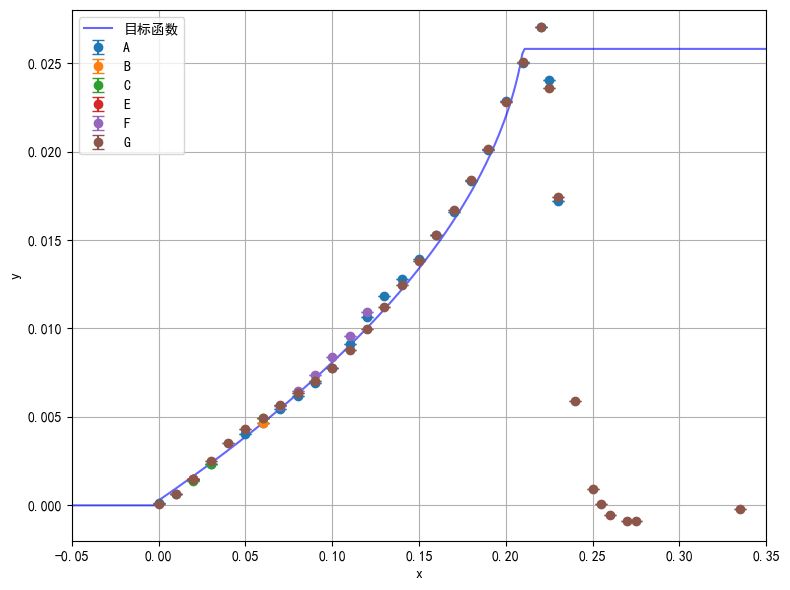

In [12]:
root1 = tk.Tk()
# 设置窗口初始大小
root1.geometry("800x600")
app = PointPlotter(root1)
# 监听note输入框回车或失去焦点时更新note
app.note_entry.bind('<Return>', lambda e: app.update_note_of_selected())
app.note_entry.bind('<FocusOut>', lambda e: app.update_note_of_selected())
root1.mainloop()

raw data save as Sourth_opt_measured_B_field_0502.csv, see G group data.

#### downside one (raw data is positive, North)

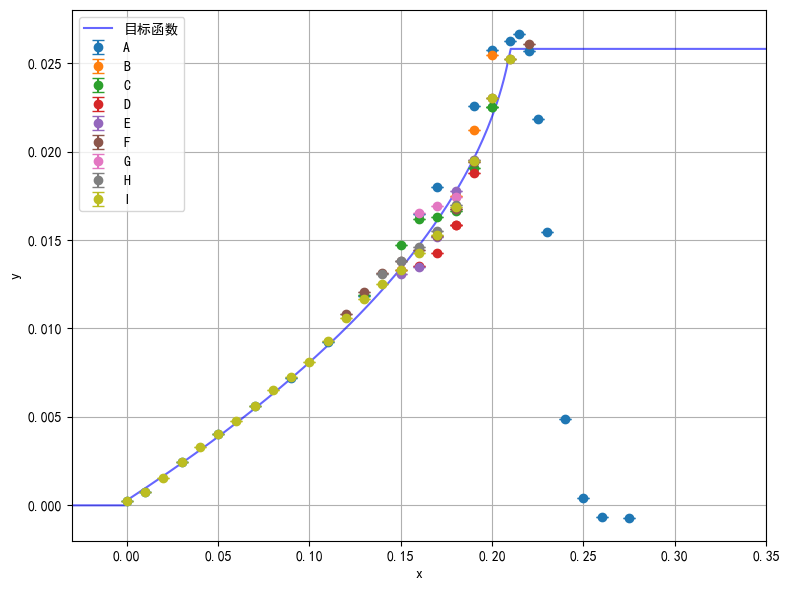

In [13]:
root2 = tk.Tk()
# 设置窗口初始大小
root2.geometry("800x600")
app = PointPlotter(root2)
# 监听note输入框回车或失去焦点时更新note
app.note_entry.bind('<Return>', lambda e: app.update_note_of_selected())
app.note_entry.bind('<FocusOut>', lambda e: app.update_note_of_selected())
root2.mainloop()

## 4. check stabilility: plot v-x , different initial velocity

### ideal B field

decelerate from 320 m/s to 35 m/s in 0.21 m
Maximum achievable deceleration: a_max = -5.3e+05 m/s²
a/a_max: 0.45
s_design=0.8300084613267259
laser detuning -809.9999999999999 MHz
Testing B-field function:
B at z=0: 0.6 mT
B at end: 51.6 mT


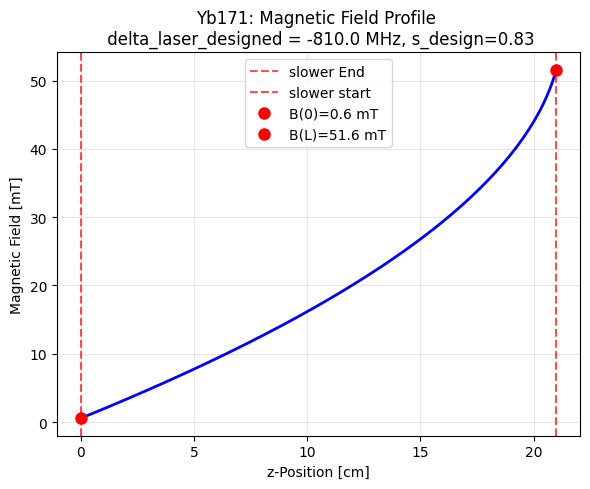

In [13]:
# single atom example

# Yb171 parameters
au = 1.66053906660e-27 # kg
m_171 = 171 * au
Gamma_399 = 2* np.pi *28.9e6  # [rad/s]
lmd_399 = 398.9e-9
k_399 = 2 * np.pi / lmd_399

g_e, g_g = 2/3, 0.0     # correct for 171Yb (1P1 -> 1S0)
M_e, M_g = -3/2, 1/2         # sigma - cycling transition
mu_B = e * hbar / (2 * m_e)
mu_eff_Yb = (g_e * M_e - g_g * M_g) * mu_B  # [J/T]

# create slower instance
slower = ZeemanSlower(Gamma_399, k_399, m_171, mu_eff_Yb, lmd_399)

z0 = 0.0
rho0 = 0    # 1mm radial offset
v0 = 320      # initial velocity m/s
delta_laser_designed = 2 * np.pi * (-810) * 1e6 # rad/s
slower_length = 0.21  # m
v_final = 35  # m/s

a = (v_final**2 - v0**2) / (2 * slower_length)
a_max = -hbar * k_399 * Gamma_399 / (2 * m_171)
eta = a/a_max
s_design = eta/(1-eta)
print(f"decelerate from {v0} m/s to {v_final} m/s in {slower_length} m")
print(f"Maximum achievable deceleration: a_max = {a_max:.1e} m/s²")
print(f"a/a_max: {eta:.2f}")
print(f"s_design={s_design}")
print(f"laser detuning {delta_laser_designed/2/np.pi/1e6} MHz")




# create B-field function using the new method
B_func = slower.create_B_field_function(slower_length, v0, v_final, delta_laser_designed)

print("Testing B-field function:")
print(f"B at z=0: {B_func(0)*1000:.1f} mT")
print(f"B at end: {B_func(slower_length)*1000:.1f} mT")


# Yb171 (single atom) plots

# 1. magnetic field along ZS (changed units)
plt.figure(figsize=(6, 5))
z_plot = np.linspace(0, slower_length, 300)
B_plot = B_func(z_plot)
plt.plot(z_plot * 100, B_plot * 1e3, 'b-', linewidth=2)
plt.axvline(x=slower_length * 100, color='r', linestyle='--', alpha=0.7, label='slower End')
plt.axvline(x=0, color='r', linestyle='--', alpha=0.7, label='slower start')
plt.plot(0, B_func(0)*1000, 'ro', markersize=8, label=f'B(0)={B_func(0)*1000:.1f} mT')
plt.plot(slower_length * 100, B_func(slower_length)*1000, 'ro', markersize=8, label=f'B(L)={B_func(slower_length)*1000:.1f} mT')
plt.xlabel('z-Position [cm]')
plt.ylabel('Magnetic Field [mT]')
plt.title(f'Yb171: Magnetic Field Profile \n delta_laser_designed = {delta_laser_designed/(2*np.pi*1e6):.1f} MHz, s_design={s_design:.2f}')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


2.5464790894703255

Running simulations...

Simulation results for v0 = 320.0 m/s:
Final velocity: 23.5 m/s
Velocity reduction: 296.5 m/s (92.7%)
Exit status: Reached slower end (z >= L)
Saturation range: 2.567 - 2.567
Maximum scattering rate: 65.3 MHz
Maximum saturation: 2.567
Travel distance: 21.0 cm
Travel time: 1.3 ms

Simulation results for v0 = 300.0 m/s:
Final velocity: 23.5 m/s
Velocity reduction: 276.5 m/s (92.2%)
Exit status: Reached slower end (z >= L)
Saturation range: 2.567 - 2.567
Maximum scattering rate: 39.7 MHz
Maximum saturation: 2.567
Travel distance: 21.0 cm
Travel time: 1.3 ms

Simulation results for v0 = 200.0 m/s:
Final velocity: 23.5 m/s
Velocity reduction: 176.5 m/s (88.3%)
Exit status: Reached slower end (z >= L)
Saturation range: 2.567 - 2.567
Maximum scattering rate: 38.5 MHz
Maximum saturation: 2.567
Travel distance: 21.0 cm
Travel time: 1.4 ms

Simulation results for v0 = 100.0 m/s:
Final velocity: 23.4 m/s
Velocity reduction: 76.6 m/s (76.6%)
Exit status:

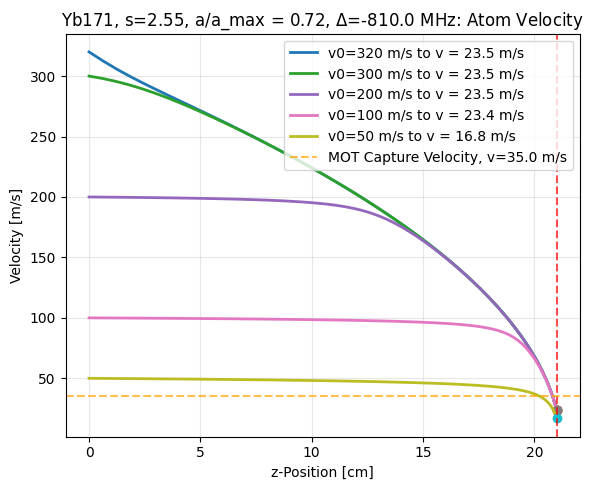

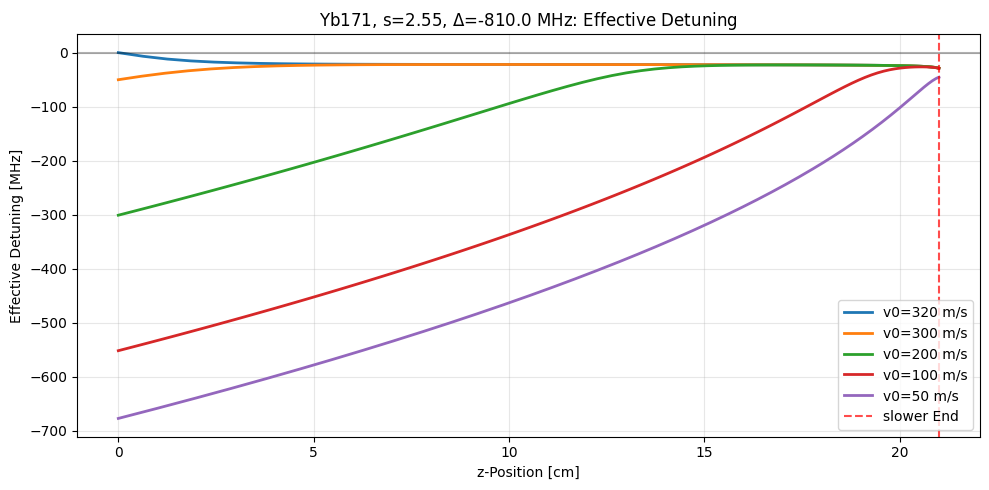

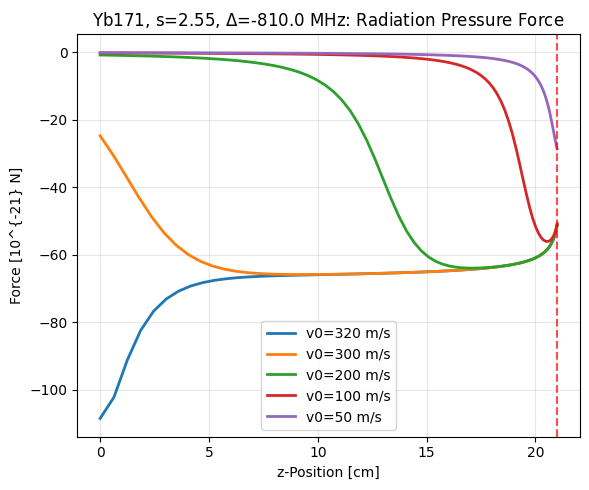

In [15]:
delta_laser = 2*np.pi*(-810)*1e6  # laser detuning [rad/s], intentionally set to a non-ideal value for testing
I_sat_399 = 60 # mW/cm^2
slower_length = 0.21  # m
s_act = np.array(P_L)* 1e3 / (pi * (wL * 1e2)**2) / I_sat_399
print(s_act)

v_array = [320, 300, 200, 100, 50]

simulation_results = []

print("\nRunning simulations...")
for v0_i in v_array:
    t_i, z_i, v_i, rho_i = slower.simulate_slower(
        z0, rho0, v0_i, delta_laser, B_func, P_L, wL, slower_length, s_is_const=True, t_max=0.02
    )

    # Stop at the first event in sampled trajectory: v <= 0 OR z >= slower_length
    stop_idx = np.where((v_i <= 0) | (z_i >= slower_length))[0]
    if len(stop_idx) > 0:
        cut_idx = stop_idx[0] + 1
    else:
        cut_idx = len(v_i)

    t_i = t_i[:cut_idx]
    z_i = z_i[:cut_idx]
    v_i = v_i[:cut_idx]
    rho_i = rho_i[:cut_idx]
    s_history_i = slower.s_history[:cut_idx].copy()
    force_history_i = slower.force_history[:cut_idx].copy()

    turned_back = bool(slower.stopped_due_to_negative_velocity)
    reached_length = bool(slower.has_exited or (z_i[-1] >= slower_length))

    reduction = v0_i - v_i[-1]
    reduction_pct = (reduction / v0_i * 100) if v0_i != 0 else 0.0
    B_i = B_func(z_i)
    delta_effective_i = delta_laser + slower.k * v_i - (slower.mu_eff * B_i / slower.hbar)

    result = {
        "v0": v0_i,
        "t": t_i,
        "z": z_i,
        "v": v_i,
        "rho": rho_i,
        "B": B_i,
        "delta_effective": delta_effective_i,
        "has_exited": reached_length,
        "turned_back": turned_back,
        "reached_length": reached_length,
        "exit_z": slower.exit_position if reached_length else None,
        "exit_v": slower.exit_velocity if reached_length else None,
        "s_history": s_history_i,
        "force_history": force_history_i,
    }
    simulation_results.append(result)

    print(f"\nSimulation results for v0 = {v0_i:.1f} m/s:")
    print(f"Final velocity: {v_i[-1]:.1f} m/s")
    print(f"Velocity reduction: {reduction:.1f} m/s ({reduction_pct:.1f}%)")
    if result["turned_back"]:
        status = "Turned back / lost atom (v <= 0)"
    elif result["reached_length"]:
        status = "Reached slower end (z >= L)"
    else:
        status = "Time limit"
    print(f"Exit status: {status}")
    print(f"Saturation range: {result['s_history'].min():.3f} - {result['s_history'].max():.3f}")
    print(f"Maximum scattering rate: {slower.scattering_rate_history.max()/1e6:.1f} MHz")
    print(f"Maximum saturation: {result['s_history'].max():.3f}")
    print(f"Travel distance: {z_i[-1]*100:.1f} cm")
    print(f"Travel time: {t_i[-1]*1000:.1f} ms")

# keep downstream compatibility with the last run
t = simulation_results[-1]["t"]
z = simulation_results[-1]["z"]
v = simulation_results[-1]["v"]
rho = simulation_results[-1]["rho"]

# 2. velocity trajectory
plt.figure(figsize=(6, 5))
for result in simulation_results:
    label = f"v0={result['v0']:.0f} m/s to v = {result['v'][-1]:.1f} m/s"
    plt.plot(result["z"] * 100, result["v"], linewidth=2, label=label)
    if result["reached_length"] and (result["exit_z"] is not None):
        plt.plot(result["exit_z"] * 100, result["exit_v"], 'o', markersize=6)
plt.axvline(x=slower_length * 100, color='r', linestyle='--', alpha=0.7)
plt.axhline(y=v_final, color='orange', linestyle='--', alpha=0.7, label=f'MOT Capture Velocity, v={v_final:.1f} m/s')
plt.xlabel('z-Position [cm]')
plt.ylabel('Velocity [m/s]')
plt.title(f'Yb171, s={s_act:.2f}, a/a_max = {s_act/(1+s_act):.2f}, $\Delta$={delta_laser/(2*np.pi*1e6):.1f} MHz: Atom Velocity')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 5. effective detuning along the actual atomic trajectory
plt.figure(figsize=(10, 5))
for result in simulation_results:
    plt.plot(
        result["z"] * 100,
        result["delta_effective"] / (2 * np.pi * 1e6),
        linewidth=2,
        label=f"v0={result['v0']:.0f} m/s"
    )
plt.axvline(x=slower_length * 100, color='r', linestyle='--', alpha=0.7, label='slower End')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.xlabel('z-Position [cm]')
plt.ylabel('Effective Detuning [MHz]')
plt.title(f'Yb171, s={s_act:.2f}, $\Delta$={delta_laser/(2*np.pi*1e6):.1f} MHz: Effective Detuning ')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 6. Force/acceleration
plt.figure(figsize=(6, 5))
for result in simulation_results:
    plt.plot(
        result["z"] * 100,
        result["force_history"] * 1e21,
        linewidth=2,
        label=f"v0={result['v0']:.0f} m/s"
    )
plt.axvline(x=slower_length * 100, color='r', linestyle='--', alpha=0.7)
plt.xlabel('z-Position [cm]')
plt.ylabel('Force [10^{-21} N]')
plt.title(f'Yb171, s={s_act:.2f}, $\Delta$={delta_laser/(2*np.pi*1e6):.1f} MHz: Radiation Pressure Force')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### ideal B field with artificial noise

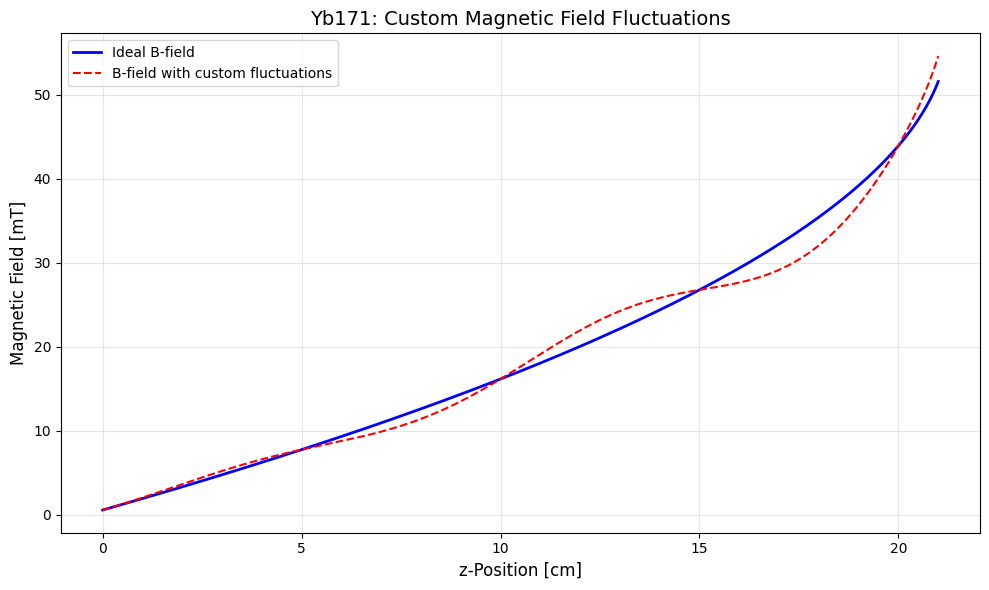

In [139]:
# 完全自定义的波动函数
def custom_fluctuation(z, B_original):
    """
    在这里定义你自己的波动形式
    """
    # 例子1: 指数衰减的振荡
    # oscillation = 0.02 * B_original * np.sin(2 * np.pi * z / 0.02) * np.exp(-z/0.1)
    
    # 例子2: 阶梯状波动
    # oscillation = 0.01 * B_original * (np.sin(2 * np.pi * z / 0.01) > 0)
    
    # 例子3: 高斯脉冲
    # gaussian_pulse = 0.03 * B_original * np.exp(-((z - 0.1)/0.01)**2)
    # oscillation = 0.01 * B_original * np.sin(2 * np.pi * z / 0.015) + gaussian_pulse
    
    # 你的自定义波动在这里
    # 例如：多个频率的复杂波动
    
    
    oscillation = B_original * (
        0.1 * np.sin(2 * np.pi * z / 0.1)
    )
    
    return B_original + oscillation

# 使用自定义波动并构造插值函数
B_with_fluctuations_values = custom_fluctuation(z_plot, B_func(z_plot))
B_func_with_fluctuations = interp1d(
    z_plot,
    B_with_fluctuations_values,
    kind='cubic',
    bounds_error=False,
    fill_value='extrapolate'
 )

# 绘制自定义波动
plt.figure(figsize=(10, 6))
plt.plot(z_plot * 100, B_func(z_plot) * 1e3, 'b-', linewidth=2, label='Ideal B-field')
plt.plot(z_plot * 100, B_func_with_fluctuations(z_plot) * 1e3, 'r--', linewidth=1.5, label='B-field with custom fluctuations')
plt.xlabel('z-Position [cm]', fontsize=12)
plt.ylabel('Magnetic Field [mT]', fontsize=12)
plt.title('Yb171: Custom Magnetic Field Fluctuations', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

1.909859317102744

Running simulations...

Simulation results for v0 = 10.0 m/s:
Final velocity: -0.2 m/s
Velocity reduction: 10.2 m/s (101.8%)
Exit status: Turned back (v < 0)
Saturation range: 1.926 - 1.926
Maximum scattering rate: 0.1 MHz
Maximum saturation: 1.926
Travel distance: 10.5 cm
Travel time: 19.3 ms

Simulation results for v0 = 50.0 m/s:
Final velocity: -0.0 m/s
Velocity reduction: 50.0 m/s (100.0%)
Exit status: Turned back (v < 0)
Saturation range: 1.926 - 1.926
Maximum scattering rate: 25.9 MHz
Maximum saturation: 1.926
Travel distance: 21.0 cm
Travel time: 4.6 ms

Simulation results for v0 = 100.0 m/s:
Final velocity: -0.4 m/s
Velocity reduction: 100.4 m/s (100.4%)
Exit status: Turned back (v < 0)
Saturation range: 1.926 - 1.926
Maximum scattering rate: 53.0 MHz
Maximum saturation: 1.926
Travel distance: 21.0 cm
Travel time: 2.4 ms

Simulation results for v0 = 200.0 m/s:
Final velocity: 1.2 m/s
Velocity reduction: 198.8 m/s (99.4%)
Exit status: Reached slower end (z >= 

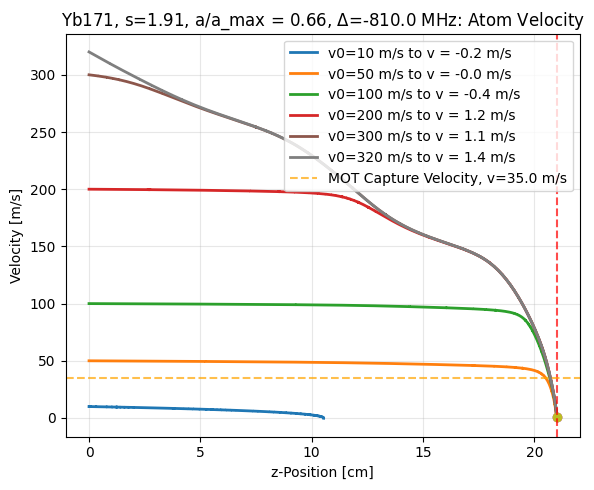

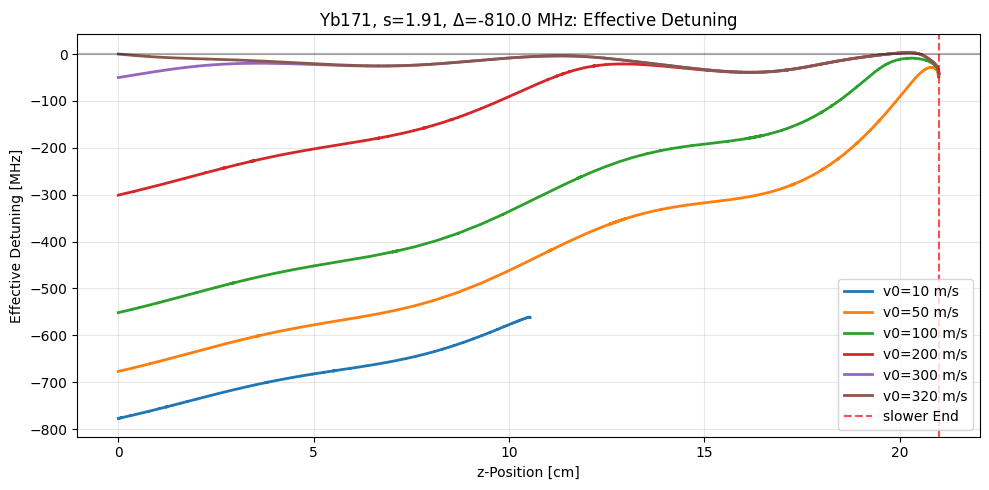

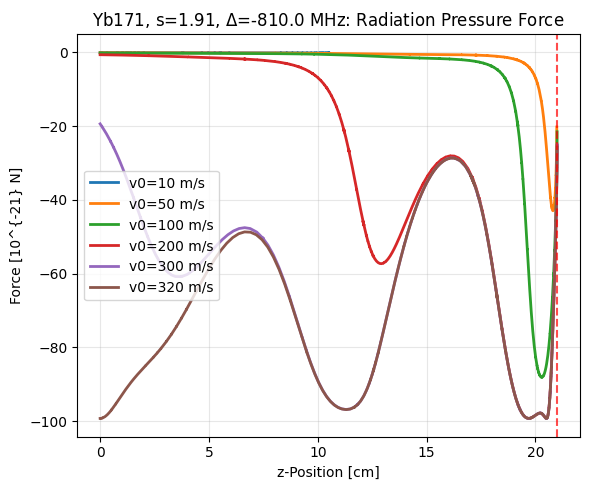

In [154]:
P_L = 90e-3     # laser power [W]
wL = 5e-3     # laser waist [m]
delta_laser_actual = 2 * np.pi * (-810) * 1e6 # rad/s
I_sat_399 = 60 # mW/cm^2

s_act = np.array(P_L)* 1e3 / (pi * (wL * 1e2)**2) / I_sat_399
print(s_act)

v_array = [10, 50, 100, 200, 300, 320]

simulation_results = []

print("\nRunning simulations...")
for v0_i in v_array:
    t_i, z_i, v_i, rho_i = slower.simulate_slower(
        z0, rho0, v0_i, delta_laser_actual, B_func_with_fluctuations, P_L, wL, slower_length, t_max=0.02
    )

    # Stop at the first event in sampled trajectory: v < 0 OR z >= slower_length
    stop_idx = np.where((v_i < 0) | (z_i >= slower_length))[0]
    if len(stop_idx) > 0:
        cut_idx = stop_idx[0] + 1
    else:
        cut_idx = len(v_i)

    t_i = t_i[:cut_idx]
    z_i = z_i[:cut_idx]
    v_i = v_i[:cut_idx]
    rho_i = rho_i[:cut_idx]
    s_history_i = slower.s_history[:cut_idx].copy()
    force_history_i = slower.force_history[:cut_idx].copy()

    turned_back = bool(v_i[-1] < 0)
    # odeint exits via StopIteration when crossing slower_length; use that flag too
    reached_length = bool(slower.has_exited or (z_i[-1] >= slower_length))

    reduction = v0_i - v_i[-1]
    reduction_pct = (reduction / v0_i * 100) if v0_i != 0 else 0.0
    B_i = B_func_with_fluctuations(z_i)
    delta_effective_i = delta_laser_actual + slower.k * v_i - (slower.mu_eff * B_i / slower.hbar)

    result = {
        "v0": v0_i,
        "t": t_i,
        "z": z_i,
        "v": v_i,
        "rho": rho_i,
        "B": B_i,
        "delta_effective": delta_effective_i,
        "has_exited": reached_length,
        "turned_back": turned_back,
        "reached_length": reached_length,
        "exit_z": slower.exit_position if reached_length else None,
        "exit_v": slower.exit_velocity if reached_length else None,
        "s_history": s_history_i,
        "force_history": force_history_i,
    }
    simulation_results.append(result)

    print(f"\nSimulation results for v0 = {v0_i:.1f} m/s:")
    print(f"Final velocity: {v_i[-1]:.1f} m/s")
    print(f"Velocity reduction: {reduction:.1f} m/s ({reduction_pct:.1f}%)")
    if result["turned_back"]:
        status = "Turned back (v < 0)"
    elif result["reached_length"]:
        status = "Reached slower end (z >= L)"
    else:
        status = "Time limit"
    print(f"Exit status: {status}")
    print(f"Saturation range: {result['s_history'].min():.3f} - {result['s_history'].max():.3f}")
    print(f"Maximum scattering rate: {slower.scattering_rate_history.max()/1e6:.1f} MHz")
    print(f"Maximum saturation: {result['s_history'].max():.3f}")
    print(f"Travel distance: {z_i[-1]*100:.1f} cm")
    print(f"Travel time: {t_i[-1]*1000:.1f} ms")

# keep downstream compatibility with the last run
t = simulation_results[-1]["t"]
z = simulation_results[-1]["z"]
v = simulation_results[-1]["v"]
rho = simulation_results[-1]["rho"]

# 2. velocity trajectory
plt.figure(figsize=(6, 5))
for result in simulation_results:
    label = f"v0={result['v0']:.0f} m/s to v = {result['v'][-1]:.1f} m/s"
    plt.plot(result["z"] * 100, result["v"], linewidth=2, label=label)
    if result["reached_length"] and (result["exit_z"] is not None):
        plt.plot(result["exit_z"] * 100, result["exit_v"], 'o', markersize=6)
plt.axvline(x=slower_length * 100, color='r', linestyle='--', alpha=0.7)
plt.axhline(y=v_final, color='orange', linestyle='--', alpha=0.7, label=f'MOT Capture Velocity, v={v_final:.1f} m/s')
plt.xlabel('z-Position [cm]')
plt.ylabel('Velocity [m/s]')
plt.title(f'Yb171, s={s_act:.2f}, a/a_max = {s_act/(1+s_act):.2f}, $\Delta$={delta_laser_actual/(2*np.pi*1e6):.1f} MHz: Atom Velocity')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 5. effective detuning along the actual atomic trajectory
plt.figure(figsize=(10, 5))
for result in simulation_results:
    plt.plot(
        result["z"] * 100,
        result["delta_effective"] / (2 * np.pi * 1e6),
        linewidth=2,
        label=f"v0={result['v0']:.0f} m/s"
    )
plt.axvline(x=slower_length * 100, color='r', linestyle='--', alpha=0.7, label='slower End')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.xlabel('z-Position [cm]')
plt.ylabel('Effective Detuning [MHz]')
plt.title(f'Yb171, s={s_act:.2f}, $\Delta$={delta_laser/(2*np.pi*1e6):.1f} MHz: Effective Detuning ')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 6. Force/acceleration
plt.figure(figsize=(6, 5))
for result in simulation_results:
    plt.plot(
        result["z"] * 100,
        result["force_history"] * 1e21,
        linewidth=2,
        label=f"v0={result['v0']:.0f} m/s"
    )
plt.axvline(x=slower_length * 100, color='r', linestyle='--', alpha=0.7)
plt.xlabel('z-Position [cm]')
plt.ylabel('Force [10^{-21} N]')
plt.title(f'Yb171, s={s_act:.2f}, $\Delta$={delta_laser/(2*np.pi*1e6):.1f} MHz: Radiation Pressure Force')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### comsol B field

0.954929658551372

Running simulations...

Simulation results for v0 = 320.0 m/s:
Final velocity: 31.7 m/s
Velocity reduction: 288.3 m/s (90.1%)
Exit status: Reached slower end (z >= L)
Saturation range: 0.963 - 0.963
Maximum scattering rate: 44.5 MHz
Maximum saturation: 0.963
Travel distance: 21.0 cm
Travel time: 1.2 ms

Simulation results for v0 = 300.0 m/s:
Final velocity: 31.7 m/s
Velocity reduction: 268.3 m/s (89.4%)
Exit status: Reached slower end (z >= L)
Saturation range: 0.963 - 0.963
Maximum scattering rate: 44.5 MHz
Maximum saturation: 0.963
Travel distance: 21.0 cm
Travel time: 1.2 ms

Simulation results for v0 = 200.0 m/s:
Final velocity: 31.7 m/s
Velocity reduction: 168.3 m/s (84.2%)
Exit status: Reached slower end (z >= L)
Saturation range: 0.963 - 0.963
Maximum scattering rate: 44.3 MHz
Maximum saturation: 0.963
Travel distance: 21.0 cm
Travel time: 1.4 ms

Simulation results for v0 = 100.0 m/s:
Final velocity: 30.5 m/s
Velocity reduction: 69.5 m/s (69.5%)
Exit status: 

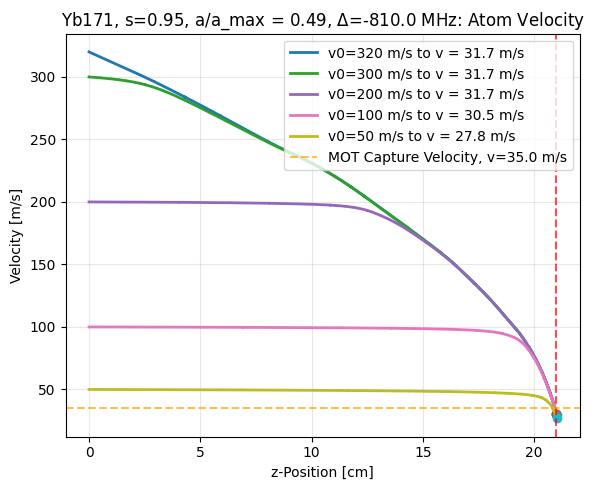

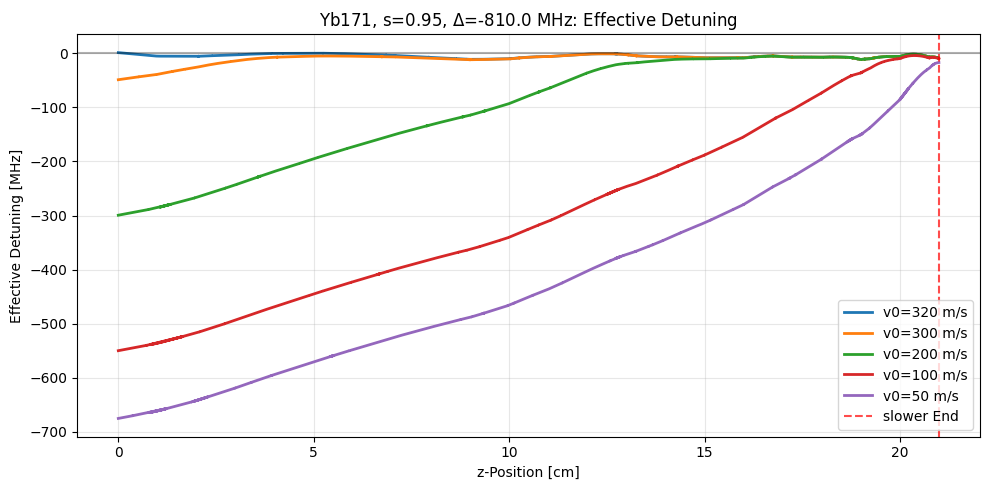

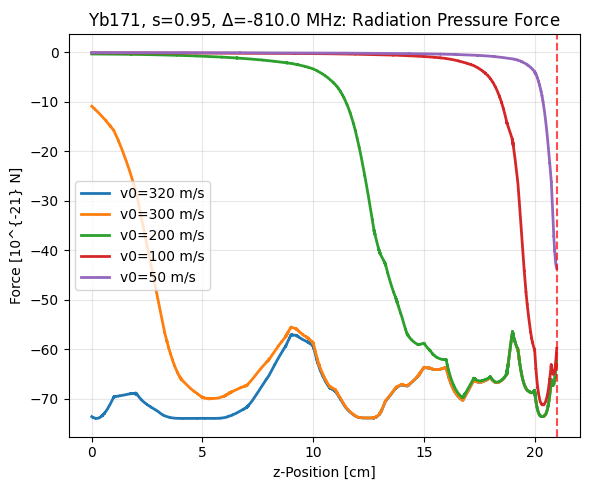

In [159]:
P_L = 45e-3     # laser power [W]
wL = 5e-3     # laser waist [m]
delta_laser = 2 * np.pi * (-810) * 1e6 # rad/s

I_sat_399 = 60 # mW/cm^2

s_act = np.array(P_L)* 1e3 / (pi * (wL * 1e2)**2) / I_sat_399
print(s_act)

v_array = [320, 300, 200, 100, 50]

simulation_results = []



print("\nRunning simulations...")
for v0_i in v_array:
    t_i, z_i, v_i, rho_i = slower.simulate_slower(
        z0, rho0, v0_i, delta_laser, Bx_comsol_func, P_L, wL, slower_length, s_is_const=True, t_max=0.02
    )

    # Stop at the first event in sampled trajectory: v < 0 OR z >= slower_length
    stop_idx = np.where((v_i < 0) | (z_i >= slower_length))[0]
    if len(stop_idx) > 0:
        cut_idx = stop_idx[0] + 1
    else:
        cut_idx = len(v_i)

    t_i = t_i[:cut_idx]
    z_i = z_i[:cut_idx]
    v_i = v_i[:cut_idx]
    rho_i = rho_i[:cut_idx]
    s_history_i = slower.s_history[:cut_idx].copy()
    force_history_i = slower.force_history[:cut_idx].copy()

    turned_back = bool(v_i[-1] < 0)
    # odeint exits via StopIteration when crossing slower_length; use that flag too
    reached_length = bool(slower.has_exited or (z_i[-1] >= slower_length))

    reduction = v0_i - v_i[-1]
    reduction_pct = (reduction / v0_i * 100) if v0_i != 0 else 0.0
    B_i = Bx_comsol_func(z_i)
    delta_effective_i = delta_laser + slower.k * v_i - (slower.mu_eff * B_i / slower.hbar)

    result = {
        "v0": v0_i,
        "t": t_i,
        "z": z_i,
        "v": v_i,
        "rho": rho_i,
        "B": B_i,
        "delta_effective": delta_effective_i,
        "has_exited": reached_length,
        "turned_back": turned_back,
        "reached_length": reached_length,
        "exit_z": slower.exit_position if reached_length else None,
        "exit_v": slower.exit_velocity if reached_length else None,
        "s_history": s_history_i,
        "force_history": force_history_i,
    }
    simulation_results.append(result)

    print(f"\nSimulation results for v0 = {v0_i:.1f} m/s:")
    print(f"Final velocity: {v_i[-1]:.1f} m/s")
    print(f"Velocity reduction: {reduction:.1f} m/s ({reduction_pct:.1f}%)")
    if result["turned_back"]:
        status = "Turned back (v < 0)"
    elif result["reached_length"]:
        status = "Reached slower end (z >= L)"
    else:
        status = "Time limit"
    print(f"Exit status: {status}")
    print(f"Saturation range: {result['s_history'].min():.3f} - {result['s_history'].max():.3f}")
    print(f"Maximum scattering rate: {slower.scattering_rate_history.max()/1e6:.1f} MHz")
    print(f"Maximum saturation: {result['s_history'].max():.3f}")
    print(f"Travel distance: {z_i[-1]*100:.1f} cm")
    print(f"Travel time: {t_i[-1]*1000:.1f} ms")

# keep downstream compatibility with the last run
t = simulation_results[-1]["t"]
z = simulation_results[-1]["z"]
v = simulation_results[-1]["v"]
rho = simulation_results[-1]["rho"]

# 2. velocity trajectory
plt.figure(figsize=(6, 5))
for result in simulation_results:
    label = f"v0={result['v0']:.0f} m/s to v = {result['v'][-1]:.1f} m/s"
    plt.plot(result["z"] * 100, result["v"], linewidth=2, label=label)
    if result["reached_length"] and (result["exit_z"] is not None):
        plt.plot(result["exit_z"] * 100, result["exit_v"], 'o', markersize=6)
plt.axvline(x=slower_length * 100, color='r', linestyle='--', alpha=0.7)
plt.axhline(y=v_final, color='orange', linestyle='--', alpha=0.7, label=f'MOT Capture Velocity, v={v_final:.1f} m/s')
plt.xlabel('z-Position [cm]')
plt.ylabel('Velocity [m/s]')
plt.title(f'Yb171, s={s_act:.2f}, a/a_max = {s_act/(1+s_act):.2f}, $\Delta$={delta_laser/(2*np.pi*1e6):.1f} MHz: Atom Velocity')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 5. effective detuning along the actual atomic trajectory
plt.figure(figsize=(10, 5))
for result in simulation_results:
    plt.plot(
        result["z"] * 100,
        result["delta_effective"] / (2 * np.pi * 1e6),
        linewidth=2,
        label=f"v0={result['v0']:.0f} m/s"
    )
plt.axvline(x=slower_length * 100, color='r', linestyle='--', alpha=0.7, label='slower End')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.xlabel('z-Position [cm]')
plt.ylabel('Effective Detuning [MHz]')
plt.title(f'Yb171, s={s_act:.2f}, $\Delta$={delta_laser/(2*np.pi*1e6):.1f} MHz: Effective Detuning ')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 6. Force/acceleration
plt.figure(figsize=(6, 5))
for result in simulation_results:
    plt.plot(
        result["z"] * 100,
        result["force_history"] * 1e21,
        linewidth=2,
        label=f"v0={result['v0']:.0f} m/s"
    )
plt.axvline(x=slower_length * 100, color='r', linestyle='--', alpha=0.7)
plt.xlabel('z-Position [cm]')
plt.ylabel('Force [10^{-21} N]')
plt.title(f'Yb171, s={s_act:.2f}, $\Delta$={delta_laser/(2*np.pi*1e6):.1f} MHz: Radiation Pressure Force')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Others design

In Travis设计

In [5]:
au = 1.66053906660e-27 # kg
m_In115 = 115 * au
lmd_326 = 325.7e-9
k_326 = 2 * np.pi / lmd_326
Gamma_326 = 2*np.pi*20.7*1e6
a_max = hbar * k_326 * Gamma_326 / (2*m_In115)
v0 = 450
vf = 70
L = 356e-3
a = (vf**2 - v0**2) / (2*L)
eta = a/a_max
print(f"Deceleration a: {a:.1e} m/s²")
print(f"Maximum achievable deceleration a_max: {a_max:.1e} m/s²")
print(f"a/a_max: {eta:.2f}")

Deceleration a: -2.8e+05 m/s²
Maximum achievable deceleration a_max: 6.9e+05 m/s²
a/a_max: -0.40


DHN设计

In [17]:
au = 1.66053906660e-27 # kg
m_Sr = 87 * au
lmd_461 = 461e-9
k_461 = 2 * np.pi / lmd_461
Gamma_461 = 2*np.pi*32*1e6
a_max = hbar * k_461 * Gamma_461 / (2*m_Sr)
v0 = 260
vf = 40
L = 60e-3
a = (vf**2 - v0**2) / (2*L)
eta = a/a_max
print(f"Deceleration a: {a:.1e} m/s²")
print(f"Maximum achievable deceleration a_max: {a_max:.1e} m/s²")
print(f"a/a_max: {eta:.2f}")

Deceleration a: -5.5e+05 m/s²
Maximum achievable deceleration a_max: 1.0e+06 m/s²
a/a_max: -0.55


宋博设计

In [18]:
au = 1.66053906660e-27 # kg
m_Yb174 = 174 * au
lmd_399 = 399e-9
k_399 = 2 * np.pi / lmd_399
Gamma_399 = 2*np.pi*29*1e6
a_max = hbar * k_399 * Gamma_399 / (2*m_Yb174)
v0 = 240
vf = 0
L = 600e-3
a = (vf**2 - v0**2) / (2*L)
eta = a/a_max
print(f"Deceleration a: {a:.1e} m/s²")
print(f"Maximum achievable deceleration a_max: {a_max:.1e} m/s²")
print(f"a/a_max: {eta:.2f}")

Deceleration a: -4.8e+04 m/s²
Maximum achievable deceleration a_max: 5.2e+05 m/s²
a/a_max: -0.09


MPQ设计

In [31]:
au = 1.66053906660e-27 # kg
m_Yb174 = 174 * au
lmd_399 = 399e-9
k_399 = 2 * np.pi / lmd_399
Gamma_399 = 2*np.pi*29*1e6
a_max = hbar * k_399 * Gamma_399 / (2*m_Yb174)
v0 = 360
vf = 0
L = 250e-3
a = -(vf**2 - v0**2) / (2*L)
eta = a/a_max
s_design = eta/(1-eta)
print(f"Deceleration a: {a:.1e} m/s²")
print(f"Maximum achievable deceleration a_max: {a_max:.1e} m/s²")
print(f"a/a_max: {eta:.2f}")
print(f"Design saturation parameter s: {s_design:.2f}")

Deceleration a: 2.6e+05 m/s²
Maximum achievable deceleration a_max: 5.2e+05 m/s²
a/a_max: 0.49
Design saturation parameter s: 0.98


In [27]:
P = 60e-3     # laser power [W]
wL = 5e-3     # laser waist [m]
I_sat_399 = 60 # mW/cm^2
s = np.array(P)* 1e3 / (pi * (wL * 1e2)**2) / I_sat_399
print(f"saturation parameter s: {s:.2f}")
print(f"a/a_max: {s/(1+s):.2f}")

saturation parameter s: 1.27
a/a_max: 0.56
